# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [302]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#0adfc6ff"
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    genotype_color['short_1'] = "#ff6600ff"
    genotype_color['short_2'] = "#ffdd00ff"
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'


    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
'#1F2A63'
'#C276A5'
"#f468f1ff"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [303]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260511.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260511.csv


## Main

### Visualize the cheeseboard maze task variables

In [304]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [290]:
dl.id, dl.ses_dir

('AL', 'ses-02_date-20250709')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

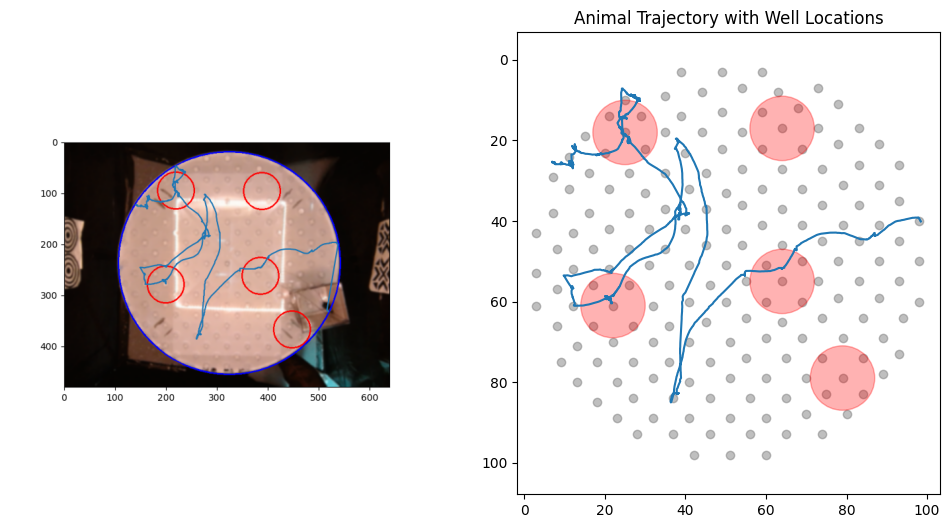

In [305]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [306]:
triggerLoc

,well_row,well_col,x,y
0,D,2,25,18
1,D,6,64,17
2,M,7,64,55
3,N,3,22,61
4,R,8,79,79


In [307]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,93406,166092,72686,1
1,213010,221155,8145,1
2,222870,223096,226,1
3,6961,13736,6775,3
4,46011,70075,24064,4


### Compute the time animal took to reach the trigger zone

In [308]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


In [309]:
# initialize both columns
metadata['t_to_trigger'] = np.nan
metadata['t_to_trigger_long'] = np.nan

R_TRIGGER = 10 / 1.2

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        continue

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    # full trial time, used as fallback
    full_trial_time = position_.iloc[-1]['t']

    dfs = []

    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trigger_interaction is not None and len(df_trigger_interaction) > 0:
            df_trigger_interaction["trigger_id"] = i + 1
            dfs.append(df_trigger_interaction)

    # --------------------------------------------------------
    # If no visits at all:
    # use full trial time for BOTH columns
    # --------------------------------------------------------
    if len(dfs) == 0:
        metadata.at[trial_id, 't_to_trigger'] = full_trial_time
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time
        continue

    # --------------------------------------------------------
    # ALL visits
    # --------------------------------------------------------
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    first_entry_time = df_all_triggers.iloc[0]['t_enter']
    metadata.at[trial_id, 't_to_trigger'] = first_entry_time

    # --------------------------------------------------------
    # LONG visits only (> 2000 ms = 2 s)
    # If no long visit, use full trial time
    # --------------------------------------------------------
    df_long = df_all_triggers[df_all_triggers['duration'] > 2000]

    if len(df_long) > 0:
        first_long_entry = df_long.iloc[0]['t_enter']
        metadata.at[trial_id, 't_to_trigger_long'] = first_long_entry
    else:
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time

 11%|█▏        | 834/7256 [00:09<01:04, 100.08it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1312/7256 [00:14<00:54, 109.84it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 43%|████▎     | 3122/7256 [00:31<00:27, 148.43it/s]

...

 82%|████████▏ | 5978/7256 [00:56<00:12, 100.98it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 7115/7256 [01:06<00:01, 132.23it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 7256/7256 [01:07<00:00, 106.92it/s]


([<matplotlib.axis.XTick at 0x12224e210>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

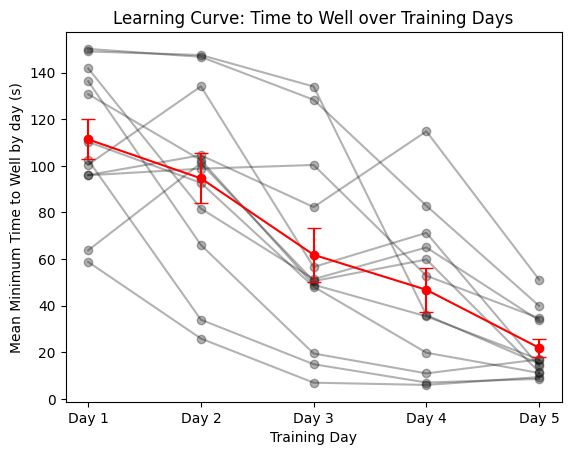

In [ ]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
    ].reset_index(drop=True)

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])


Using: t_to_trigger_long (≥2 s stay)
Day value mode: first_trial
Trial column used: inferred from sub/ses order
Groups used for plotting/stats: ['ArchT', 'eYFP_ArchT']
Original genotypes loaded: ['ArchT', 'eYFP_ArchT']
Custom IDs loaded: []

Custom groups requested:

Rows after filtering:
    sub id genotype_original    genotype trial_type  trial_type_day  ses  \
0    28  H             ArchT       ArchT          L               1    4   
1    28  H             ArchT       ArchT          L               2    5   
2    28  H             ArchT       ArchT          L               3    6   
3    28  H             ArchT       ArchT          L               4    7   
4    28  H             ArchT       ArchT          L               5    8   
..  ... ..               ...         ...        ...             ...  ...   
67   39  P        eYFP_ArchT  eYFP_ArchT          L               2    5   
68   39  P        eYFP_ArchT  eYFP_ArchT          L               3    6   
69   39  P        eYFP_Ar

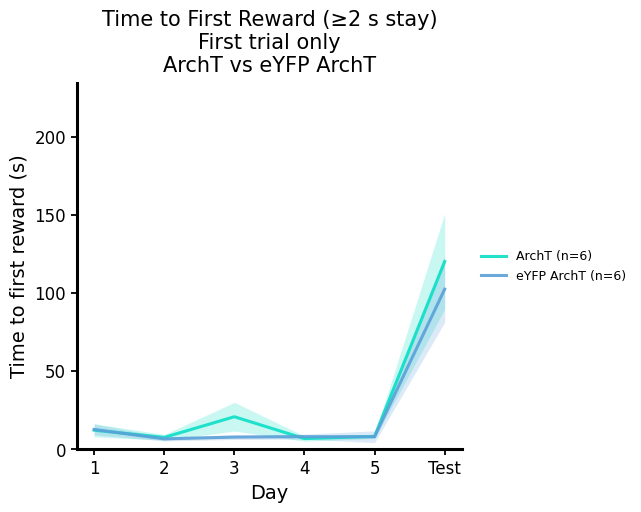


Boxplot: learning days 1-5 average
Using: t_to_trigger_long (≥2 s stay)
Day value mode: first_trial
Animals plotted:
  ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  eYFP ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id  value_s
0        ArchT   28   H  10.4754
1        ArchT   29  HA   7.6240
2        ArchT   30  HB  23.9344
3        ArchT   31   I   6.5866
4        ArchT   32   J   8.8992
5        ArchT   33   L   8.4704
6   eYFP_ArchT   34   M   6.4678
7   eYFP_ArchT   35  MA   5.8082
8   eYFP_ArchT   36  MB   9.8564
9   eYFP_ArchT   37   N  12.4848
10  eYFP_ArchT   38   O  12.1042
11  eYFP_ArchT   39   P   4.2072

Mann–Whitney U tests:
  ArchT vs eYFP ArchT: n=6 vs 6, U=22.0, p=0.58874


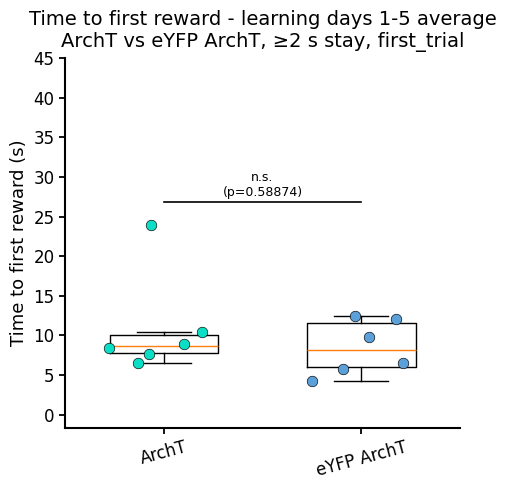


Boxplot: test day
Using: t_to_trigger_long (≥2 s stay)
Day value mode: first_trial
Animals plotted:
  ArchT (ArchT): n = 6, ids = ['H', 'HA', 'HB', 'I', 'J', 'L']
  eYFP ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id  value_s
0        ArchT   28   H   62.530
1        ArchT   29  HA  203.817
2        ArchT   30  HB    8.680
3        ArchT   31   I  191.198
4        ArchT   32   J  136.349
5        ArchT   33   L  117.913
6   eYFP_ArchT   34   M   25.748
7   eYFP_ArchT   35  MA   87.103
8   eYFP_ArchT   36  MB   83.140
9   eYFP_ArchT   37   N  151.453
10  eYFP_ArchT   38   O  169.323
11  eYFP_ArchT   39   P   97.318

Mann–Whitney U tests:
  ArchT vs eYFP ArchT: n=6 vs 6, U=21.0, p=0.69913


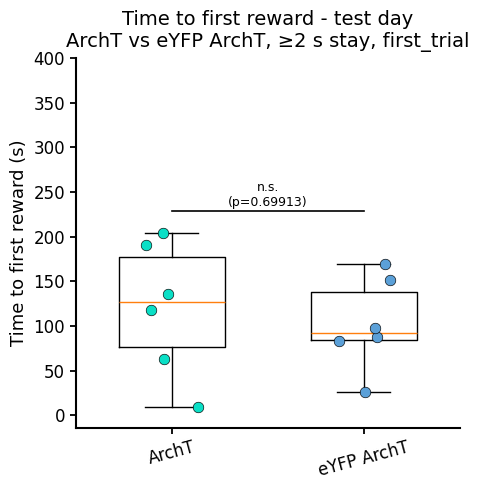

In [ ]:
# ============================================================
# Time to first reward across L1-L5 + Test
#
# Adds pooled control group:
#   'Control' = eYFP_ChR2 + CA1_control + NAc_control
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# Important behaviour:
#   GROUPS = ['ChR2_short']
#       -> keeps all ChR2_short animals together.
#
#   GROUPS = ['short_1', 'short_2']
#       -> splits AI/AJ/AL and V1-V5 into custom groups.
#
#   GROUPS = ['ChR2_short', 'short_1', 'short_2']
#       -> short_1/short_2 animals are split out,
#          remaining ChR2_short animals stay in ChR2_short.
#
# Produces:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each learning day
#       test day      = first test trial only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

USE_LONG_VISITS = True         # False -> t_to_trigger; True -> t_to_trigger_long
PLOT_INDIVIDUAL = False        # True -> faded individual animal lines
REQUIRE_COMPLETE = False       # True -> only animals with all L1-L5 + Test

SHOW_ANIMAL_IDS = False        # True -> label each dot with animal ID

# How to compute one value per animal per day
DAY_VALUE_MODE = 'first_trial'
# DAY_VALUE_MODE = 'first_trial' or 'daily_mean'

# Example group choices:
# GROUPS = ['Control']
# GROUPS = ['ChR2', 'Control']
# GROUPS = ['ChR2_short']
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2_short', 'short_1', 'short_2']
# GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['F231A', 'F231A_wt']
# GROUPS = ['short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'ChR2']
# GROUPS = ['short_1', 'short_2', 'ChR2', 'eYFP_ChR2']
GROUPS = ['ArchT', 'eYFP_ArchT']


# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Usually these animals are ChR2_short.
# If you want to load only by ID regardless of genotype, set values to None.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['CA1_control', 'NAc_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
    'WT': 'WT',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
}

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('short_1', 'ChR2'), ('short_2', 'ChR2')]
# COMPARISONS = [('ChR2_short', 'eYFP_ChR2')]

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all visits'

# Boxplot dot/stat options
JITTER = 0.12
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45
P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.4
P_TEXT_OFFSET_FRAC = 0.015
P_TOP_PAD_FRAC = 0.25

# y-axis options
LINE_YMIN = 0
LINE_YMAX = None        # None = auto; or set manually, e.g. 200

# For boxplots:
# BOX_YMIN = None means auto negative padding below 0, so tiny values are visible.
# Set BOX_YMIN = 0 if you want the x-axis exactly at 0.
BOX_YMIN = None
BOX_YMAX = None         # None = auto; or set manually, e.g. 200
BOX_Y_BOTTOM_PAD_FRAC = 0.04
BOX_Y_TICK_STEP = None  # e.g. 20, 50, 100, or None for auto

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


# ============================================================
# Helper functions: custom groups
# ============================================================

def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_plot_color(g):
    """
    Uses the same colour method as the rest of your plotting code.

    If get_genotype_color('short_1') or get_genotype_color('short_2')
    is not defined, this falls back to ChR2_short colour.
    """
    try:
        return get_genotype_color(g)
    except Exception:
        if g in ['short_1', 'short_2']:
            return get_genotype_color('ChR2_short')
        return get_genotype_color(g)


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      animals with id in CUSTOM_GROUP_ID_MAP are assigned to
      short_1, short_2, etc. ONLY if that custom group is in GROUPS.

    This is the important fix:
      GROUPS = ['ChR2_short'] keeps AI/AJ/AL/V1-V5 inside ChR2_short.
      GROUPS = ['short_1', 'short_2'] splits them.
      GROUPS = ['ChR2_short', 'short_1', 'short_2'] splits them out
      while leaving other ChR2_short animals as ChR2_short.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():

        # Key fix: only create custom groups when requested.
        if group_name not in GROUPS:
            continue

        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


# ============================================================
# General helper functions
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals,
    and custom group visible for short_1 / short_2.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def style_nature(ax, linewidth=2.0):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def apply_box_y_axis(ax, y_top):
    """
    Boxplot y-axis:
      - actual lower limit is slightly below 0
      - tick labels start at 0
      - this makes very low positive values visible above the x-axis
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    if BOX_YMAX is not None:
        y_top = BOX_YMAX

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def assign_learning_and_test_days(meta_df):
    """
    Assign:
      L trial_type_day 1-5 -> plot_day 1-5
      first T session after last L session -> plot_day 6
    """
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin(plot_days)].copy()

    return meta_df


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.
    Uses existing trial column if present; otherwise infers from sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session'
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean':
          mean across available trials within that day
      'first_trial':
          trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for the same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    """
    Build animal x day matrix.
    One row = one animal.
    Columns = L1, L2, L3, L4, L5, Test.

    Uses DAY_VALUE_MODE to decide whether each day is:
      - average of all trials
      - first trial only
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def values_from_matrix(g, mode):
    """
    Uses the exact same matrix as the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value_s'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value_ms = np.nanmean(row[0:5])
        elif mode == 'test':
            value_ms = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value_ms):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value_s': float(value_ms) / 1000.0
        })

    return pd.DataFrame(rows)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})" if np.isfinite(p) else "p = NaN",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 1) Prepare metadata with pooled Control and custom groups
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    TIME_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

groups_to_load = []
custom_ids_to_load = []

for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna()) &
    (np.isfinite(metadata[TIME_COL]))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()

# Store original genotype before pooling/custom reassignment
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool controls into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add custom analysis group.
# This only creates short_1 / short_2 if they are in GROUPS.
meta_LT = add_analysis_group(meta_LT)

# Use analysis_group as active plotting/statistical group
meta_LT['genotype'] = meta_LT['analysis_group']

# Keep only requested displayed groups
meta_LT = meta_LT[meta_LT['genotype'].isin(GROUPS)].copy()

# Do not accidentally exclude custom animals if their IDs are in EXCLUDE_ID
exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_LT = assign_learning_and_test_days(meta_LT)
meta_LT, trial_col_used = add_trial_in_day(meta_LT)

print("\nUsing:", TIME_COL, f"({STAY_TAG})")
print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col_used if trial_col_used is not None else "inferred from sub/ses order")
print("Groups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Custom IDs loaded:", custom_ids_to_load)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups requested:")
for g, ids in CUSTOM_GROUP_ID_MAP.items():
    if g in GROUPS:
        print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nRows after filtering:")
cols_to_print = ['sub']

if 'id' in meta_LT.columns:
    cols_to_print.append('id')

if 'genotype_original' in meta_LT.columns:
    cols_to_print.append('genotype_original')

cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'plot_day']

if len(meta_LT) > 0:
    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")


# ============================================================
# 2) Build group matrices
# ============================================================

group_data = {}

print("\nAnimals:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, TIME_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g})")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")


# ============================================================
# 3) Line plot: L1-L5 + Test
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

def plot_group_shaded(
    ax,
    mat,
    subs,
    genotype_key,
    label,
    alpha_fill=0.22,
    alpha_line=0.9,
    alpha_individual=0.12
):
    if mat is None or len(subs) == 0:
        return

    col = get_plot_color(genotype_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row / 1000.0,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms = sem_by_day(mat)

    mean_s = mean_ms / 1000.0
    sem_s = sem_ms / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )


for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Time to first reward (s)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

title = 'Time to First Reward'
if USE_LONG_VISITS:
    title += ' (≥2 s stay)'

if DAY_VALUE_MODE == 'first_trial':
    title += '\nFirst trial only'
else:
    title += '\nDaily mean'

display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])
ax.set_title(
    f'{title}\n{display_groups}',
    fontsize=15,
    pad=8
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

if LINE_YMAX is not None:
    ax.set_ylim(LINE_YMIN, LINE_YMAX)
else:
    all_mats = [
        group_data[g]['mat']
        for g in GROUPS
        if group_data[g]['mat'] is not None
    ]

    if len(all_mats) > 0:
        all_vals_s = np.concatenate([
            m[np.isfinite(m)].ravel() / 1000.0
            for m in all_mats
            if np.any(np.isfinite(m))
        ])

        if len(all_vals_s) > 0:
            ymax = np.nanmax(all_vals_s)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1.0
            ax.set_ylim(LINE_YMIN, ymax * 1.15)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 4) Boxplot helper
# ============================================================

def plot_boxplot_from_matrix(mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_matrix(g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value_s'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Using: {TIME_COL} ({STAY_TAG})")
    print(f"Day value mode: {DAY_VALUE_MODE}")
    print("Animals plotted:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value_s']])
    else:
        print("No data.")

    fig, ax = plt.subplots(figsize=(max(4.8, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        df_g = group_dfs[g]
        vals = df_g['value_s'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in comparisons_to_run:
        if g1 not in GROUPS or g2 not in GROUPS:
            print(
                f"  Skipping {DISPLAY_NAME.get(g1, g1)} vs "
                f"{DISPLAY_NAME.get(g2, g2)}: group not in GROUPS"
            )
            continue

        vals1 = group_dfs[g1]['value_s'].values.astype(float)
        vals2 = group_dfs[g2]['value_s'].values.astype(float)

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={len(vals1)} vs {len(vals2)}, "
                f"U={stat:.1f}, p={format_p(p)}"
            )
        else:
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"p = NaN"
            )

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            draw_sig_bar(ax, x1, x2, current_y, p, yrng)
            current_y += y_step

        y_top_auto = current_y + P_TOP_PAD_FRAC * yrng
        apply_box_y_axis(ax, y_top_auto)

    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=12,
        rotation=15
    )

    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax, linewidth=1.5)

    display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

    ax.set_title(
        f'Time to first reward - {title_suffix}\n'
        f'{display_groups}, {STAY_TAG}, {DAY_VALUE_MODE}',
        fontsize=14,
        pad=8
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 5) Produce boxplots
# ============================================================

plot_boxplot_from_matrix(
    mode='learning_mean',
    title_suffix='learning days 1-5 average'
)

plot_boxplot_from_matrix(
    mode='test',
    title_suffix='test day'
)

Group plotted: ArchT (ArchT)
Using column: t_to_trigger
Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 6
  Day 2 best -> Day 3 trial 1: n = 6
  Day 3 best -> Day 4 trial 1: n = 6
  Day 4 best -> Day 5 trial 1: n = 6
  Day 5 best -> Test trial 1: n = 6


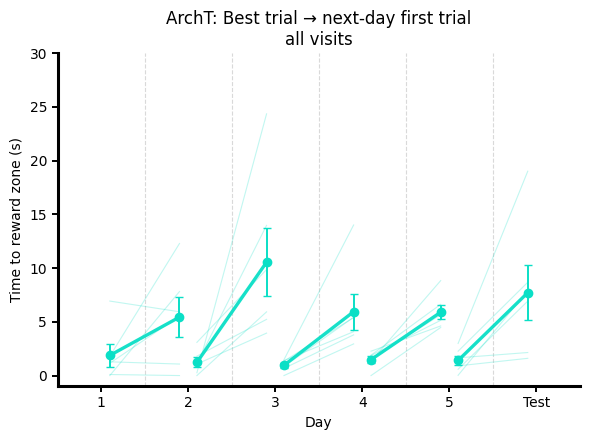

In [ ]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: time to reward zone
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'ArchT'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = False        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AN','BQ','BP']               # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

FILTER_SHORT_DURATION = False # True -> apply short_duration != 1
                              # False -> no short_duration filter

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = MIN time within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, best_val, first_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicates exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        best_val = np.nanmin(by_trial.values)   # smaller time = better
        first_val = by_trial.get(1, np.nan)

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev, TIME_COL)[['sub', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next, TIME_COL)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

print(f"Group plotted: {GROUP_LABEL} ({GENOTYPE_TO_PLOT})")
print(f"Using column: {TIME_COL}")
print("Animals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helper
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_PLOT)

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

all_y_s = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            y_prev_s = row['y_prev'] / 1000.0
            y_next_s = row['y_next'] / 1000.0

            ax.plot(
                [x_prev, x_next],
                [y_prev_s, y_next_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

            all_y_s.extend([y_prev_s, y_next_s])

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values / 1000.0
    y_next = df_tr['y_next'].values / 1000.0

    all_y_s.extend(list(y_prev) + list(y_next))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: Best trial → next-day first trial\n'
    f'{TITLE_SUFFIX}',
    fontsize=12
)

if len(all_y_s) > 0:
    ymax = np.nanmax(all_y_s)

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    # Padding below zero so low values do not sit on the x-axis
    Y_ZERO_PAD_FRAC = 0.04
    ax.set_ylim(-Y_ZERO_PAD_FRAC * ymax, ymax * 1.15)

    # Keep tick labels starting from 0
    yticks = ax.get_yticks()
    yticks = yticks[yticks >= 0]
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)
    ax.set_yticks(yticks)

style_nature(ax)
plt.tight_layout()
plt.show()

Using genotype: eYFP_ArchT (eYFP_ArchT)
Using column: t_to_trigger
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included per within-day comparison:
  Day 1: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 2: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 3: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 4: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 5: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Test: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: two-sided
Test day is plotted as one dot only and is not tested.
  Day 1: n = 6, first mean = 7.764 s, best mean = 0.830 s, median diff best-first = -6.907 s, W = 0.000, p = 0.04311
  Day 2: n = 6, first mean = 6.133 s, best mean = 1.075 s, median diff best-first = -3.917 s, W = 0.000, p = 0.03125
  Day 3: n = 6, first mean = 7.639 s, best mean = 0.998 s, median 

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


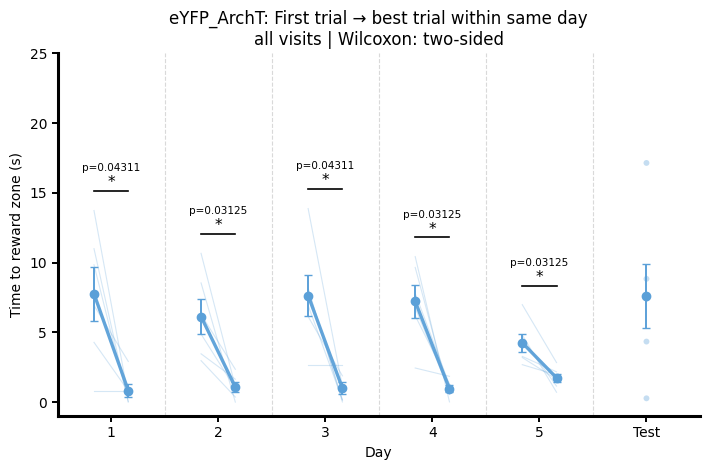

In [ ]:
# ============================================================
# Flexible genotype:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: time to reward zone
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#
# Test day:
#   only one trial, so it is plotted as one dot only
#   no paired line / Wilcoxon test for Test
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
#   alternative='less' tests whether best trial < first trial
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'eYFP_ArchT'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = False        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AN','BQ','BP']               # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

# Wilcoxon:
# 'less' = tests whether best trial time < first trial time
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'two-sided'

SHOW_P_VALUES = True
SHOW_STARS = True
P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value annotation spacing
P_LINE_FRAC_ABOVE = 0.08
P_STAR_FRAC_ABOVE = 0.004   # smaller = star closer to horizontal line
P_TEXT_FRAC_ABOVE = 0.075

# y-axis
YMIN = None          # None -> slightly below 0
YMAX = 25          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = MIN time within that day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, id, first_val, best_val

    For time-to-trigger:
      best_val = minimum time within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmin(by_trial.values.astype(float))  # smaller time = better

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d, TIME_COL)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'
    print(
        f"  {day_label}: n = {len(df_d)}, "
        f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
    )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='less'):
    """
    Paired Wilcoxon signed-rank test.

    For time-to-reward:
      alternative='less' tests whether best_vals < first_vals.
      alternative='two-sided' tests whether best_vals != first_vals.

    If all differences are zero, scipy raises an error;
    in that case return p=1.
    """
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first
#    Test day is skipped because it usually has only one trial.
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day is plotted as one dot only and is not tested.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no test")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals) / 1000.0:.3f} s, "
        f"best mean = {np.nanmean(best_vals) / 1000.0:.3f} s, "
        f"median diff best-first = {np.nanmedian((best_vals - first_vals) / 1000.0):.3f} s, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_PLOT)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day:
    # only plot single trial/best point, no paired line/stat
    # dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals_s = df_d['first_val'].values.astype(float) / 1000.0
        test_vals_s = test_vals_s[np.isfinite(test_vals_s)]

        all_y_for_ylim.extend(test_vals_s)

        if len(test_vals_s) == 0:
            continue

        if PLOT_INDIVIDUAL:
            ax.scatter(
                np.full(len(test_vals_s), x_test),
                test_vals_s,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals_s)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals_s = df_d['first_val'].values.astype(float) / 1000.0
    best_vals_s = df_d['best_val'].values.astype(float) / 1000.0

    all_y_for_ylim.extend(first_vals_s[np.isfinite(first_vals_s)])
    all_y_for_ylim.extend(best_vals_s[np.isfinite(best_vals_s)])

    # --------------------------------------------------------
    # 1) Individual animal paired lines only
    #    No individual dots for learning days 1-5
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            y_first_s = row['first_val'] / 1000.0
            y_best_s = row['best_val'] / 1000.0

            ax.plot(
                [x_first, x_best],
                [y_first_s, y_best_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_first, s_first = mean_sem(first_vals_s)
    m_best, s_best = mean_sem(best_vals_s)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        # Skip test day
        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_vals_s = np.r_[
            df_d['first_val'].values.astype(float) / 1000.0,
            df_d['best_val'].values.astype(float) / 1000.0
        ]

        local_max = np.nanmax(local_vals_s)

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + P_STAR_FRAC_ABOVE * yrng
        y_pval = y_line + P_TEXT_FRAC_ABOVE * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: First trial → best trial within same day\n'
    f'{TITLE_SUFFIX} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: F231A (F231A)
Using column: t_to_trigger_long
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 14
    sub  id  Day 1 trial 1 trials  Day 5 trial 1 trials
0    48  BB                     1                     1
1    51  BE                     1                     1
2    52  BF                     1                     1
3    53  BG                     1                     1
4    54  BH                     1                     1
5    55  BI                     1                     1
6    57  BL                     1                     1
7    58  BM                     1                     1
8    59  BN                     1                     1
9    63  BR                     1                     1
10   92  F3                     1                     1
11   93  F4                     1                     1
12   96  F7                     1                     1
13   97  F8                     1          

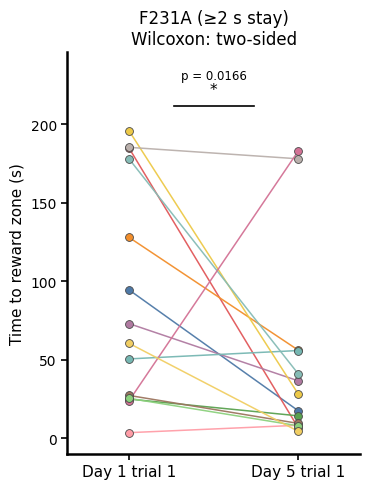

In [ ]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for time to reward zone
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_trial1_vs_day5_trial1'
# COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_day5'

GENOTYPE_TO_USE = 'F231A'  # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'eYFP_ChR2', 'CA1_control'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

# choose latency metric
USE_LONG_VISITS = True
TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_SUFFIX = ' (≥2 s stay)' if USE_LONG_VISITS else ' (all visits)'

# Optional short-duration filter
FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

# y-axis padding
YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    Used for:
      - Day 1 in day1_vs_day5
      - Day 5 in day1_vs_day5
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    Used for:
      - Day 1 in day1_vs_test
      - Test day in day1_vs_test
      - Day 1 and Day 5 in day1_trial1_vs_day5_trial1
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, TIME_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, TIME_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, TIME_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['y1_s'] = paired_print['y1'] / 1000.0
    paired_print['y2_s'] = paired_print['y2'] / 1000.0
    paired_print['diff_y2_minus_y1_s'] = paired_print['y2_s'] - paired_print['y1_s']
    print(paired_print[['sub', 'id', 'y1_s', 'y2_s', 'diff_y2_minus_y1_s', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    """
    Publication-style muted but visible colours.
    """
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

# individual paired lines
if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'] / 1000.0,
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

# optional group mean ± SEM
y1_s = y1 / 1000.0
y2_s = y2 / 1000.0

if PLOT_GROUP_MEAN and len(y1_s) > 0:
    m1 = np.nanmean(y1_s)
    m2 = np.nanmean(y2_s)

    s1 = 0.0 if len(y1_s) <= 1 else np.nanstd(y1_s, ddof=1) / np.sqrt(len(y1_s))
    s2 = 0.0 if len(y2_s) <= 1 else np.nanstd(y2_s, ddof=1) / np.sqrt(len(y2_s))

    ax.plot(
        [x1, x2],
        [m1, m2],
        '-',
        color=base_col,
        linewidth=2.4,
        zorder=3
    )

    ax.errorbar(
        x1,
        m1,
        yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2,
        m2,
        yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
all_y_s = np.r_[y1_s, y2_s]

if len(all_y_s) > 0 and np.isfinite(all_y_s).any():
    ymax_data = np.nanmax(all_y_s)
    ymin_data = np.nanmin(all_y_s)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

# styling
ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel('Time to reward zone (s)', fontsize=11)

ax.set_title(
    f'{title_txt}\nWilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()



############################################################
RUNNING: t_to_trigger (all visits)
############################################################
Using time column: t_to_trigger
Stay mode: all visits
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 (all visits)
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI  ChR2_

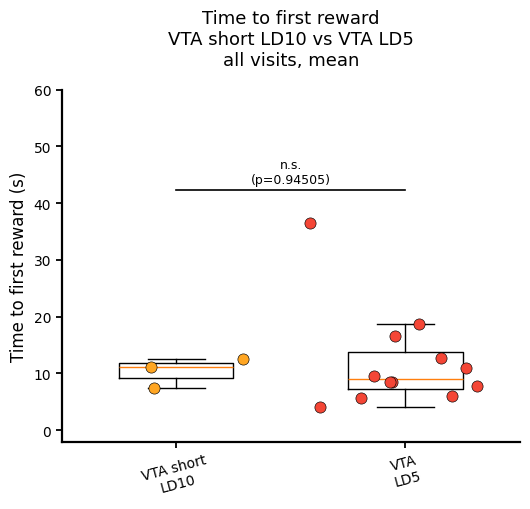


Time to first reward
VTA short next test vs VTA test
Per-animal values used for statistics:
Left group:
   sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0   13  AI   18744.0   18.744         1     [14]                 [1]   
1   14  AJ   20505.0   20.505         1     [14]                 [1]   
2   15  AL     328.0    0.328         1     [14]                 [1]   

  trial_type_list trial_in_day_list  
0             [T]               [1]  
1             [T]               [1]  
2             [T]               [1]  
Right group:
    sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0     1   A    5182.0    5.182         1      [9]                 [1]   
1     3   C    8237.0    8.237         1      [9]                 [1]   
2     4   D     278.0    0.278         1      [9]                 [1]   
3     6  AB    7985.0    7.985         1      [9]                 [1]   
4     7  AC    4357.0    4.357         1      [9]                 [1]   
5  

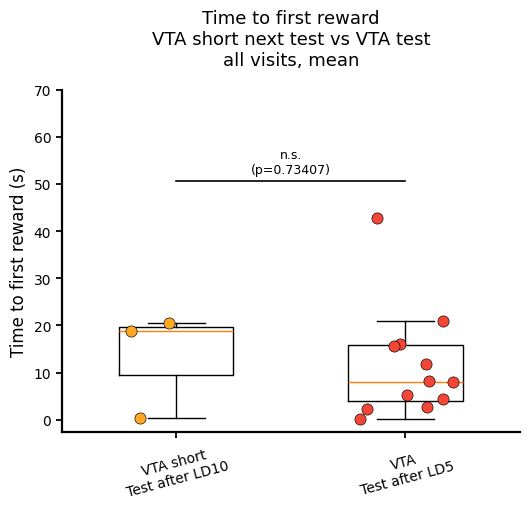



############################################################
RUNNING: t_to_trigger_long (≥2 s stay)
############################################################
Using time column: t_to_trigger_long
Stay mode: ≥2 s stay
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 (≥2 s stay)
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI

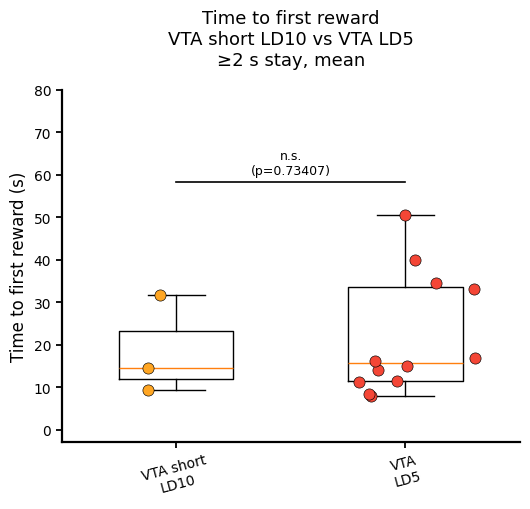


Time to first reward
VTA short next test vs VTA test
Per-animal values used for statistics:
Left group:
   sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0   13  AI   18744.0   18.744         1     [14]                 [1]   
1   14  AJ   37938.0   37.938         1     [14]                 [1]   
2   15  AL   18209.0   18.209         1     [14]                 [1]   

  trial_type_list trial_in_day_list  
0             [T]               [1]  
1             [T]               [1]  
2             [T]               [1]  
Right group:
    sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0     1   A    5182.0    5.182         1      [9]                 [1]   
1     3   C   40861.0   40.861         1      [9]                 [1]   
2     4   D    9569.0    9.569         1      [9]                 [1]   
3     6  AB    7985.0    7.985         1      [9]                 [1]   
4     7  AC   33150.0   33.150         1      [9]                 [1]   
5  

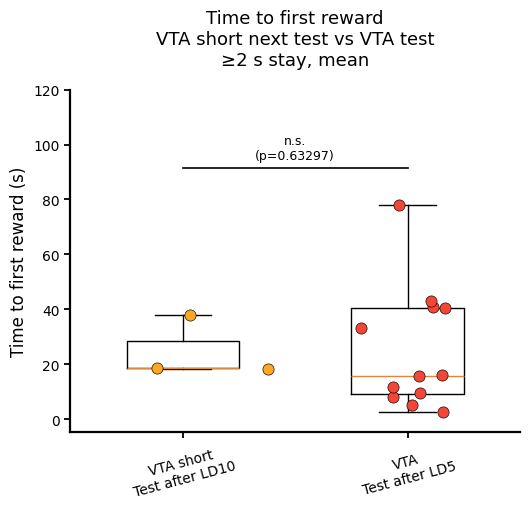

In [ ]:
# ============================================================
# Compare time to first reward:
#
# ChR2_short animals AI/AJ/AL:
#   final learning day = learning day 10
#   trial_type_day == 10, trial_type == 'L'
#
# vs
#
# ChR2 animals:
#   final learning day = learning day 5
#   trial_type_day == 5, trial_type == 'L'
#
# Also compare:
#   ChR2_short next test day after learning day 10
#   vs
#   ChR2 first test day after learning day 5
#
# Produces 4 boxplots:
#   1) Learning comparison, all visits:          t_to_trigger
#   2) Test comparison, all visits:              t_to_trigger
#   3) Learning comparison, ≥2 s stay only:      t_to_trigger_long
#   4) Test comparison, ≥2 s stay only:          t_to_trigger_long
#
# Stats:
#   Mann–Whitney U test between animal-level values.
#
# Prints:
#   - exact trial rows included
#   - animal-level values used for stats
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

CHR2_SHORT_IDS = ['AI', 'AJ', 'AL']

CH_R2_GENOTYPE = 'ChR2'
CH_R2_SHORT_GENOTYPE = 'ChR2_short'

TIME_COLS_TO_RUN = [
    ('t_to_trigger', 'all visits'),
    ('t_to_trigger_long', '≥2 s stay'),
]

EXCLUDE_ID = ['AN']      # optional
EXCLUDE_SUBS = []        # optional

REQUIRE_USABLE = True

# How to summarize multiple trials from the same animal/session/day
# 'mean' = average all included trials per animal
# 'first_trial' = use trial_in_day == 1 only
TRIAL_SUMMARY_MODE = 'mean'
# TRIAL_SUMMARY_MODE = 'first_trial'

# Plot options
SHOW_ANIMAL_IDS = False
JITTER = 0.18
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.18
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.35

# y-axis
YMIN = None
YMAX_BY_TIME_COL = {
    't_to_trigger': None,
    't_to_trigger_long': None,
}
Y_BOTTOM_PAD_FRAC = 0.04
Y_TICK_STEP = None       # e.g. 20, 50, or None

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer an existing trial column if present.
    Otherwise infer from sorted sub/ses/trial_id order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        sort_cols = ['sub', 'ses']
        if 'trial_id' in meta_df.columns:
            sort_cols.append('trial_id')

        meta_df = meta_df.sort_values(sort_cols).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    return meta_df, trial_col


def print_trial_rows(label, meta_df, value_col):
    """
    Print exact trial-level rows used before per-animal averaging.
    Values are printed both in ms and seconds.
    """
    print("\n============================================================")
    print(label)
    print(f"Trial-level rows included: n rows = {len(meta_df)}")
    print(f"Animals included: n = {meta_df['sub'].nunique() if len(meta_df) > 0 else 0}")

    if len(meta_df) == 0:
        print("No rows.")
        return

    cols = [
        'sub',
        'id',
        'genotype',
        'ses',
        'trial_type',
        'trial_type_day',
        'trial_in_day',
    ]

    optional_cols = [
        'trial_id',
        'date',
        'usable',
        'short_duration',
        value_col,
    ]

    cols_to_print = [c for c in cols + optional_cols if c in meta_df.columns]

    out = meta_df[cols_to_print].copy()

    if value_col in out.columns:
        out[f'{value_col}_s'] = out[value_col].astype(float) / 1000.0

    sort_cols = [c for c in ['id', 'sub', 'ses', 'trial_in_day'] if c in out.columns]

    print(
        out
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )


def per_animal_value_from_trials(meta_df, value_col):
    """
    Converts trial-level rows into one value per animal.

    TRIAL_SUMMARY_MODE:
      'mean'        -> average across all included trials per animal
      'first_trial' -> only trial_in_day == 1
    """
    rows = []

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub].copy()

        if TRIAL_SUMMARY_MODE == 'first_trial':
            ms_use = ms[ms['trial_in_day'] == 1].copy()
        elif TRIAL_SUMMARY_MODE == 'mean':
            ms_use = ms.copy()
        else:
            raise ValueError("TRIAL_SUMMARY_MODE must be 'mean' or 'first_trial'")

        vals_ms = ms_use[value_col].values.astype(float)
        vals_ms = vals_ms[np.isfinite(vals_ms)]

        if len(vals_ms) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_label(ms, sub),
            'value_ms': float(np.nanmean(vals_ms)),
            'value_s': float(np.nanmean(vals_ms) / 1000.0),
            'n_trials': len(vals_ms),
            'ses_list': sorted(ms_use['ses'].dropna().unique().tolist()) if 'ses' in ms_use.columns else [],
            'trial_type_day_list': sorted(ms_use['trial_type_day'].dropna().unique().tolist()) if 'trial_type_day' in ms_use.columns else [],
            'trial_type_list': sorted(ms_use['trial_type'].dropna().unique().tolist()) if 'trial_type' in ms_use.columns else [],
            'trial_in_day_list': sorted(ms_use['trial_in_day'].dropna().unique().tolist()) if 'trial_in_day' in ms_use.columns else [],
        })

    return pd.DataFrame(rows)


def apply_box_y_axis(ax, y_top, value_col):
    manual_ymax = YMAX_BY_TIME_COL.get(value_col, None)

    if manual_ymax is not None:
        y_top = manual_ymax
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if YMIN is not None:
        y_bottom = YMIN
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def plot_two_group_boxplot(
    df_left,
    df_right,
    left_label,
    right_label,
    title,
    value_col,
    stay_tag,
):
    """
    Boxplot + individual dots + Mann–Whitney U test.
    df_left / df_right should contain columns:
      sub, id, value_s, value_ms, n_trials
    """
    vals_left = df_left['value_s'].values.astype(float) if len(df_left) > 0 else np.array([])
    vals_right = df_right['value_s'].values.astype(float) if len(df_right) > 0 else np.array([])

    vals_groups = [vals_left, vals_right]
    positions = np.array([0, 1])

    print("\n============================================================")
    print(title)
    print("Per-animal values used for statistics:")
    print("Left group:")
    print(df_left)
    print("Right group:")
    print(df_right)

    if len(vals_left) > 0 and len(vals_right) > 0:
        stat, p = mannwhitneyu(vals_left, vals_right, alternative='two-sided')
        rank_biserial = (2 * stat) / (len(vals_left) * len(vals_right)) - 1

        print("\nMann–Whitney U test:")
        print(
            f"  {left_label} vs {right_label}: "
            f"n={len(vals_left)} vs {len(vals_right)}, "
            f"mean={np.nanmean(vals_left):.3f} vs {np.nanmean(vals_right):.3f} s, "
            f"median={np.nanmedian(vals_left):.3f} vs {np.nanmedian(vals_right):.3f} s, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )
    else:
        stat, p = np.nan, np.nan
        print("\nMann–Whitney U test: skipped because one group has no data.")

    fig, ax = plt.subplots(figsize=(5.4, 5.2))

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    # --------------------------------------------------------
    # Individual dots
    # --------------------------------------------------------
    group_keys = [CH_R2_SHORT_GENOTYPE, CH_R2_GENOTYPE]

    for i, (df_g, vals, gkey) in enumerate(zip([df_left, df_right], vals_groups, group_keys)):
        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(gkey),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(gkey),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Significance line
    # --------------------------------------------------------
    nonempty = [v for v in vals_groups if len(v) > 0]

    if len(nonempty) > 0:
        all_vals = np.concatenate(nonempty)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y_line = ymax + P_LINE_START_FRAC * yrng
        y_text = y_line + P_TEXT_OFFSET_FRAC * yrng

        if np.isfinite(p):
            ax.plot(
                [positions[0], positions[1]],
                [y_line, y_line],
                color='black',
                linewidth=1.2,
                zorder=5,
                clip_on=False
            )

            ax.text(
                np.mean(positions),
                y_text,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9,
                zorder=6,
                clip_on=False
            )

        y_top_for_axis = y_line + P_TOP_PAD_FRAC * yrng
    else:
        y_top_for_axis = 1.0

    # --------------------------------------------------------
    # Axes / labels / style
    # --------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [left_label, right_label],
        fontsize=10,
        rotation=15
    )

    ax.set_ylabel('Time to first reward (s)', fontsize=12)
    ax.set_title(
        f'{title}\n{stay_tag}, {TRIAL_SUMMARY_MODE}',
        fontsize=13,
        pad=18
    )

    apply_box_y_axis(ax, y_top_for_axis, value_col)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main function for one time column
# ============================================================

def run_time_to_reward_comparison(time_col, stay_tag):
    print("\n\n############################################################")
    print(f"RUNNING: {time_col} ({stay_tag})")
    print("############################################################")

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        time_col,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata: {missing_cols}")

    meta = metadata.copy()

    if REQUIRE_USABLE:
        meta = meta[meta['usable'] == 1].copy()

    meta = meta[
        meta['genotype'].isin([CH_R2_GENOTYPE, CH_R2_SHORT_GENOTYPE]) &
        meta['trial_type'].isin(['L', 'T']) &
        meta[time_col].notna() &
        np.isfinite(meta[time_col])
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta, trial_col = add_trial_in_day(meta)

    print("Using time column:", time_col)
    print("Stay mode:", stay_tag)
    print("Trial summary mode:", TRIAL_SUMMARY_MODE)
    print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses/trial_id order")
    print("ChR2_short IDs requested:", CHR2_SHORT_IDS)

    # ========================================================
    # Comparison 1:
    # ChR2_short LD10 vs ChR2 LD5
    # ========================================================

    short_ld10_trials = meta[
        (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
        (meta['id'].astype(str).isin(CHR2_SHORT_IDS)) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 10)
    ].copy()

    chr2_ld5_trials = meta[
        (meta['genotype'] == CH_R2_GENOTYPE) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    print_trial_rows(
        label=f"Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 ({stay_tag})",
        meta_df=short_ld10_trials,
        value_col=time_col
    )

    print_trial_rows(
        label=f"Comparison 1 RIGHT: ChR2 learning day 5 ({stay_tag})",
        meta_df=chr2_ld5_trials,
        value_col=time_col
    )

    short_ld10_animal = per_animal_value_from_trials(short_ld10_trials, time_col)
    chr2_ld5_animal = per_animal_value_from_trials(chr2_ld5_trials, time_col)

    # ========================================================
    # Comparison 2:
    # ChR2_short next test after LD10 vs ChR2 first test after LD5
    # ========================================================

    # --------------------------------------------------------
    # ChR2_short next test:
    # for each animal, find last ses among LD10 rows;
    # next test session = last_ld10_ses + 1
    # --------------------------------------------------------
    short_next_test_list = []

    for animal_id in CHR2_SHORT_IDS:
        m_animal_ld10 = short_ld10_trials[
            short_ld10_trials['id'].astype(str) == str(animal_id)
        ].copy()

        if len(m_animal_ld10) == 0:
            print(f"WARNING: no LD10 rows found for {animal_id}; cannot find next test.")
            continue

        last_ld10_ses = m_animal_ld10['ses'].max()
        next_test_ses = last_ld10_ses + 1

        m_next_test = meta[
            (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
            (meta['id'].astype(str) == str(animal_id)) &
            (meta['trial_type'] == 'T') &
            (meta['ses'] == next_test_ses)
        ].copy()

        if len(m_next_test) == 0:
            print(
                f"WARNING: no next test rows found for {animal_id}: "
                f"expected ses = {next_test_ses}"
            )
            continue

        short_next_test_list.append(m_next_test)

    if len(short_next_test_list) > 0:
        short_next_test_trials = pd.concat(short_next_test_list, ignore_index=False)
    else:
        short_next_test_trials = meta.iloc[0:0].copy()

    # --------------------------------------------------------
    # ChR2 first test after learning day 5:
    # computed separately for each ChR2 animal.
    # --------------------------------------------------------
    chr2_test_list = []

    meta_chr2 = meta[meta['genotype'] == CH_R2_GENOTYPE].copy()

    for sub in meta_chr2['sub'].unique():
        ms = meta_chr2[meta_chr2['sub'] == sub].copy()

        m_ld5 = ms[
            (ms['trial_type'] == 'L') &
            (ms['trial_type_day'] == 5)
        ].copy()

        if len(m_ld5) == 0:
            continue

        last_ld5_ses = m_ld5['ses'].max()

        m_test_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_ld5_ses)
        ].copy()

        if len(m_test_after) == 0:
            continue

        first_test_ses = m_test_after['ses'].min()

        m_first_test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == first_test_ses)
        ].copy()

        if len(m_first_test) > 0:
            chr2_test_list.append(m_first_test)

    if len(chr2_test_list) > 0:
        chr2_test_trials = pd.concat(chr2_test_list, ignore_index=False)
    else:
        chr2_test_trials = meta.iloc[0:0].copy()

    print_trial_rows(
        label=f"Comparison 2 LEFT: ChR2_short AI/AJ/AL next test after learning day 10 ({stay_tag})",
        meta_df=short_next_test_trials,
        value_col=time_col
    )

    print_trial_rows(
        label=f"Comparison 2 RIGHT: ChR2 first test after learning day 5 ({stay_tag})",
        meta_df=chr2_test_trials,
        value_col=time_col
    )

    short_next_test_animal = per_animal_value_from_trials(short_next_test_trials, time_col)
    chr2_test_animal = per_animal_value_from_trials(chr2_test_trials, time_col)

    # ========================================================
    # Plot 1: final learning day comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_ld10_animal,
        df_right=chr2_ld5_animal,
        left_label='VTA short\nLD10',
        right_label='VTA\nLD5',
        title='Time to first reward\nVTA short LD10 vs VTA LD5',
        value_col=time_col,
        stay_tag=stay_tag,
    )

    # ========================================================
    # Plot 2: test comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_next_test_animal,
        df_right=chr2_test_animal,
        left_label='VTA short\nTest after LD10',
        right_label='VTA\nTest after LD5',
        title='Time to first reward\nVTA short next test vs VTA test',
        value_col=time_col,
        stay_tag=stay_tag,
    )


# ============================================================
# Run both all-visits and ≥2 s stay versions
# ============================================================

for time_col, stay_tag in TIME_COLS_TO_RUN:
    run_time_to_reward_comparison(time_col, stay_tag)

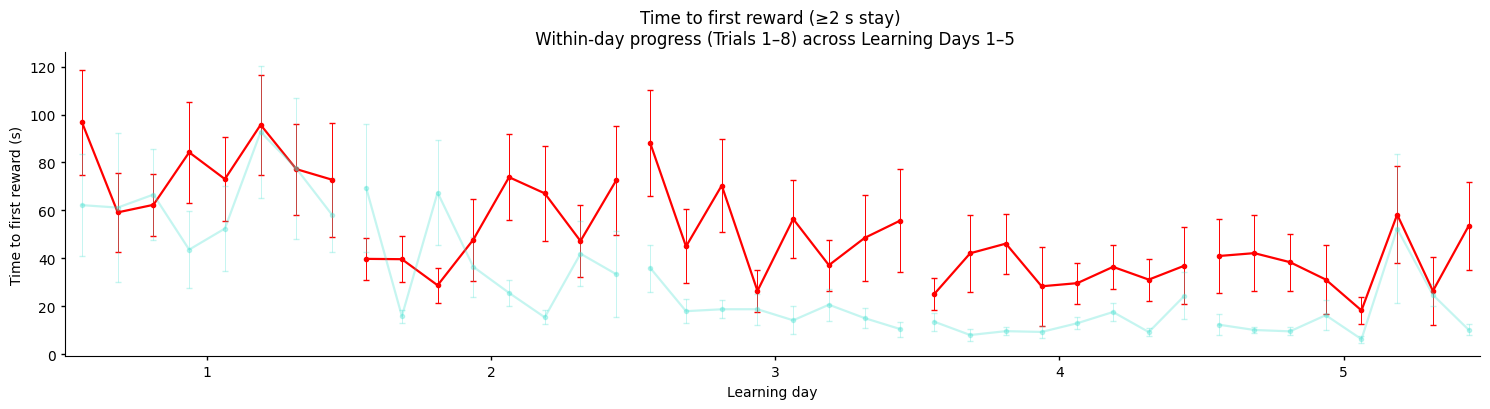

In [ ]:

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    #(metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,        # <-- add this
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# Split by genotype
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()

# Wider figure so Day 5 curve isn't clipped
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=1.0)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # <-- more faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Centered day ticks
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure Day 5 curve fully visible

ax.set_xlim(1.0, 5.98)

ax.set_title('Time to first reward (≥2 s stay) \n Within-day progress (Trials 1–8) across Learning Days 1–5', fontsize=12)
#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Using: t_to_trigger_long (≥2 s stay)
VTA short animals plotted: n = 8
Animal IDs: ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']


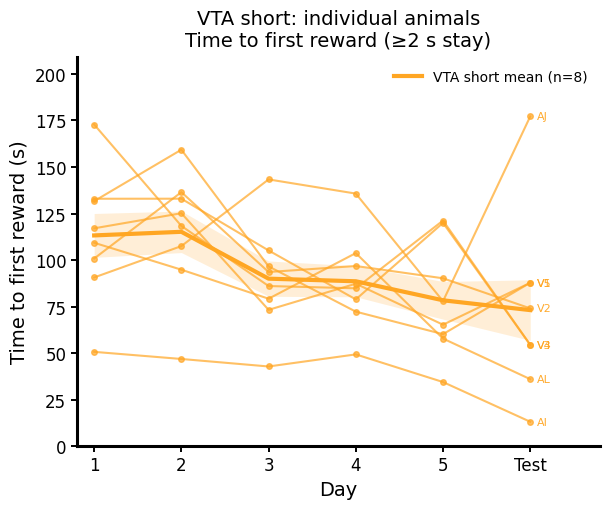

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Individual animal lines: ChR2_short
# Time to first reward across L1-L5 + Test
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
USE_LONG_VISITS = True        # False -> t_to_trigger ; True -> t_to_trigger_long
REQUIRE_COMPLETE = False      # True -> only animals with all L1-L5 + Test
EXCLUDE_ID = ['AS', 'AN']     # manually exclude animals by id; use [] for none
SHOW_ANIMAL_IDS = True        # label each animal line
SHOW_GROUP_MEAN = True        # overlay group mean ± SEM

GROUP_TO_PLOT = 'ChR2_short'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
}

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all entries'

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ------------------------------------------------------------
# 1. Filter metadata
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GROUP_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

# ------------------------------------------------------------
# 2. Assign plot_day: learning = 1–5, first post-learning test = 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep learning days 1–5 only
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3. Build animal × day matrix
# ------------------------------------------------------------
rows = []
subs = []
animal_ids = []

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub].copy()

    mean_by_day = ms.groupby('plot_day')[TIME_COL].mean()

    vals = np.array(
        [mean_by_day.get(d, np.nan) for d in plot_days],
        dtype=float
    )

    if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
        continue

    if np.all(np.isnan(vals)):
        continue

    rows.append(vals)
    subs.append(sub)

    if 'id' in ms.columns and ms['id'].notna().any():
        animal_ids.append(str(ms['id'].dropna().iloc[0]))
    else:
        animal_ids.append(str(sub))

if len(rows) == 0:
    print(f"No animals found for {GROUP_TO_PLOT} using {TIME_COL}.")
else:
    mat = np.vstack(rows)

    print("Using:", TIME_COL, f"({STAY_TAG})")
    print(f"{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} animals plotted: n = {len(subs)}")
    print("Animal IDs:", animal_ids)

    # --------------------------------------------------------
    # 4. Plot individual animal lines clearly
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    col = get_genotype_color(GROUP_TO_PLOT)

    for i, row in enumerate(mat):
        y = row / 1000.0

        ax.plot(
            x_vals,
            y,
            '-o',
            color=col,
            alpha=0.70,
            linewidth=1.5,
            markersize=4,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            finite_idx = np.where(np.isfinite(y))[0]
            if len(finite_idx) > 0:
                last_i = finite_idx[-1]
                ax.text(
                    x_vals[last_i] + 0.08,
                    y[last_i],
                    animal_ids[i],
                    fontsize=8,
                    color=col,
                    alpha=0.95,
                    ha='left',
                    va='center'
                )

    # --------------------------------------------------------
    # Optional group mean ± SEM
    # --------------------------------------------------------
    if SHOW_GROUP_MEAN:
        mean_ms = np.nanmean(mat, axis=0)

        n_per_day = np.sum(~np.isnan(mat), axis=0)
        sem_ms = np.nanstd(mat, axis=0) / np.sqrt(n_per_day)
        sem_ms[n_per_day <= 1] = 0

        mean_s = mean_ms / 1000.0
        sem_s = sem_ms / 1000.0

        ax.fill_between(
            x_vals,
            mean_s - sem_s,
            mean_s + sem_s,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

        ax.plot(
            x_vals,
            mean_s,
            '-',
            color=col,
            linewidth=3.0,
            alpha=1.0,
            label=f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} mean (n={len(subs)})',
            zorder=4
        )

    # --------------------------------------------------------
    # Axes + style
    # --------------------------------------------------------
    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.set_title(
        f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)}: individual animals\n'
        f'Time to first reward ({STAY_TAG})',
        fontsize=14,
        pad=8
    )

    if SHOW_GROUP_MEAN:
        ax.legend(frameon=False)

    # auto y-limit
    all_vals_s = mat[np.isfinite(mat)].ravel() / 1000.0
    if len(all_vals_s) > 0:
        ymax = np.nanmax(all_vals_s)
        ax.set_ylim(0, ymax * 1.18)

    # leave space for labels
    if SHOW_ANIMAL_IDS:
        ax.set_xlim(-0.2, 5.8)
    else:
        ax.set_xlim(-0.2, 5.2)

    plt.tight_layout()
    plt.show()

# forgetting/extinction


Forgetting vs Extinction plot
Using column: t_to_trigger
Visit criterion: all visits
Genotypes: ['ChR2', 'eYFP_ChR2']
SEM style: bar

Rows after filtering:
     sub id   genotype   test_type  short_duration  trial_type_day  \
0      1  A       ChR2  extinction               0               1   
1      1  A       ChR2  extinction               0               2   
2      1  A       ChR2  extinction               0               3   
3      2  B       ChR2  extinction               0               1   
4      2  B       ChR2  extinction               0               2   
..   ... ..        ...         ...             ...             ...   
170   22  F  eYFP_ChR2  extinction               0               4   
171   23  G  eYFP_ChR2  extinction               0               1   
172   23  G  eYFP_ChR2  extinction               0               2   
173   23  G  eYFP_ChR2  extinction               0               3   
174   23  G  eYFP_ChR2  extinction               0               4   

  

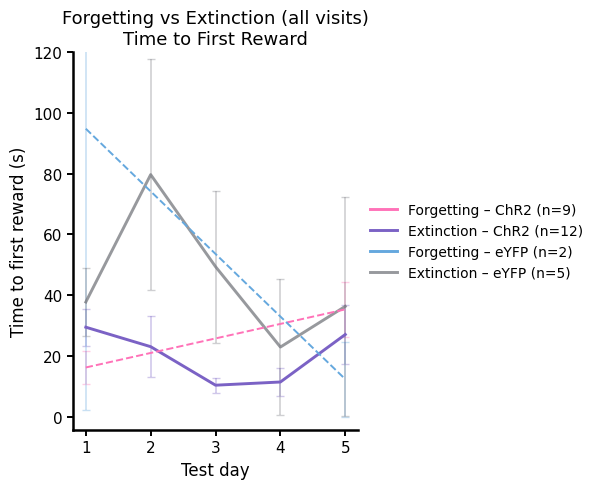


Test day 1 boxplot values
Using: t_to_trigger (all visits)
  Ext ChR2: n = 12, ids = ['A', 'B', 'AA', 'AB', 'AC', 'AD', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 5.182  47.346  47.61    7.985  15.29   68.507  54.409  16.059  18.546
 41.0625 17.5747 14.203 ]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 6.098   4.357  21.8625 42.87    6.259   2.218  42.6272 12.5465  7.2125]
  Ext eYFP: n = 5, ids = ['E', 'EE', 'EF', 'F', 'G'], values_s = [63.505 25.393  3.213 60.846 35.881]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [187.296   2.288]

Raw day 1 rows used for boxplot:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     1   A       ChR2  extinction               1        5182.0
1     2   B       ChR2  extinction               1       47346.0
2     3   C       ChR2         NaN               1        8237.0
3     4   D       ChR2         NaN               1         278.0
4     5  AA       ChR2  extinction  

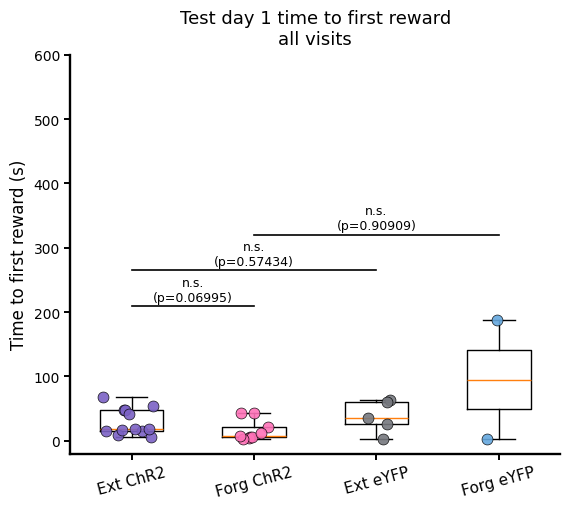


Test day 2 boxplot values
Using: t_to_trigger (all visits)
  Ext ChR2: n = 12, ids = ['A', 'B', 'AA', 'AB', 'AC', 'AD', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 11.546    0.136   15.615    5.069    1.675   11.553  112.389    5.732
   2.056   21.6785  76.113   13.221 ]
  Ext eYFP: n = 5, ids = ['E', 'EE', 'EF', 'F', 'G'], values_s = [ 11.813   1.14  205.353 123.878  56.293]

Raw day 2 rows used for boxplot:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     1   A       ChR2  extinction               2       11546.0
1     2   B       ChR2  extinction               2         136.0
2     5  AA       ChR2  extinction               2       15615.0
3     6  AB       ChR2  extinction               2        5069.0
4     7  AC       ChR2  extinction               2        1675.0
5     8  AD       ChR2  extinction               2        2405.0
6     8  AD       ChR2  extinction               2       20701.0
7    10  AF       ChR2  extinction               2      1123

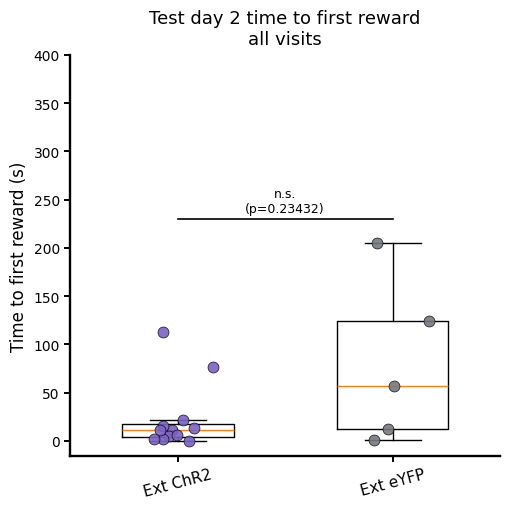


Test day 3 boxplot values
Using: t_to_trigger (all visits)
  Ext ChR2: n = 12, ids = ['A', 'B', 'AA', 'AB', 'AC', 'AD', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [10.349   5.115  25.058   8.909   0.291  20.935   0.205   5.472   4.611
 21.8745 14.2355  7.6627]
  Ext eYFP: n = 5, ids = ['E', 'EE', 'EF', 'F', 'G'], values_s = [  3.115   0.583  81.593  30.753 130.936]

Raw day 3 rows used for boxplot:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     1   A       ChR2  extinction               3       10349.0
1     2   B       ChR2  extinction               3        5115.0
2     5  AA       ChR2  extinction               3       25058.0
3     6  AB       ChR2  extinction               3        8909.0
4     7  AC       ChR2  extinction               3         291.0
5     8  AD       ChR2  extinction               3        2948.0
6     8  AD       ChR2  extinction               3       38922.0
7    10  AF       ChR2  extinction               3         205.0
8    11

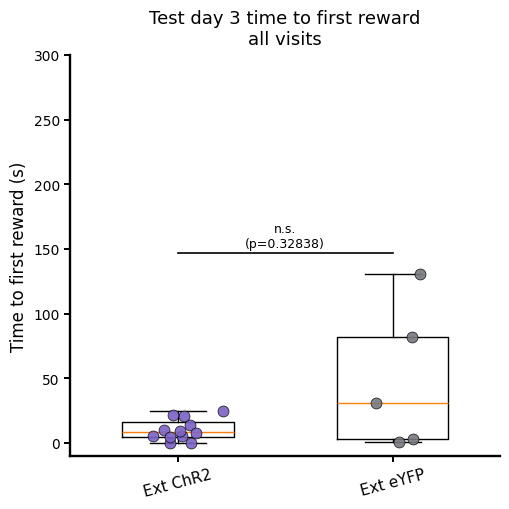


Test day 4 boxplot values
Using: t_to_trigger (all visits)
  Ext ChR2: n = 10, ids = ['AA', 'AB', 'AC', 'AD', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 0.806   8.825   1.69    4.515   2.92    1.873   9.21   47.9677 24.572
 12.0833]
  Ext eYFP: n = 5, ids = ['E', 'EE', 'EF', 'F', 'G'], values_s = [1.12266e+02 1.36600e+00 2.40000e-02 0.00000e+00 1.08200e+00]

Raw day 4 rows used for boxplot:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     5  AA       ChR2  extinction               4         806.0
1     6  AB       ChR2  extinction               4        8825.0
2     7  AC       ChR2  extinction               4        1690.0
3     8  AD       ChR2  extinction               4         239.0
4     8  AD       ChR2  extinction               4        8791.0
5    10  AF       ChR2  extinction               4        2920.0
6    11  AG       ChR2  extinction               4        1873.0
7    12  AH       ChR2  extinction               4        9210.0
8    16  AM  

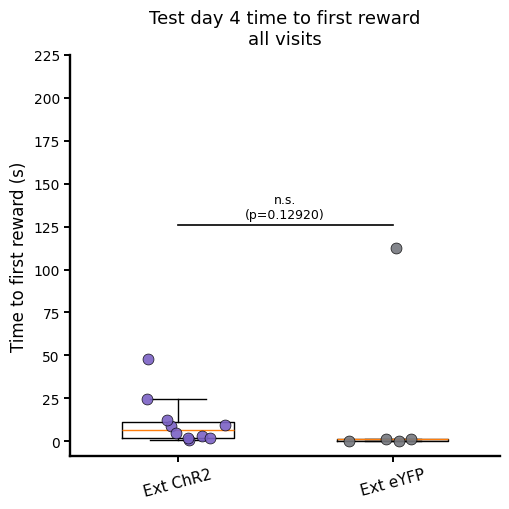


Test day 5 boxplot values
Using: t_to_trigger (all visits)
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [21.921   0.081  26.2115  0.525   0.482  51.8707 76.5287 38.9903]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 7.113   8.745  34.3985 68.43   19.45    9.72   35.145  56.0197 79.0694]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [72.281  0.398]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [24.743  0.   ]

Raw day 5 rows used for boxplot:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     6  AB       ChR2  extinction               5       21921.0
1     6  AB       ChR2  forgetting               5        7113.0
2     7  AC       ChR2  extinction               5          81.0
3     7  AC       ChR2  forgetting               5        8745.0
4     8  AD       ChR2  extinction               5       22159.0
5     8  AD       ChR2  extinction               5       30264.0

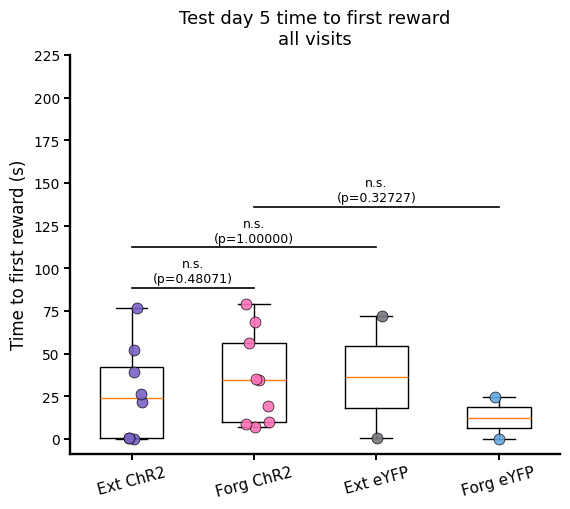


Paired ChR2 Extinction vs Forgetting, test day 1
Using: t_to_trigger (all visits)

Paired animals:
   sub  id  ext_value_s  forg_value_s
0    6  AB     7.985000       6.09800
1    7  AC    15.290000       4.35700
2   10  AF    54.409000      42.87000
3   11  AG    16.059000       6.25900
4   12  AH    18.546000       2.21800
5   16  AM    41.062500      42.62725
6   17  AN    17.574667      12.54650
7   18  AO    14.203000       7.21250
Wilcoxon paired test: n=8, Ext mean=23.141, Forg mean=15.524, Ext median=16.817, Forg median=6.736, stat=1.000, p=0.01562


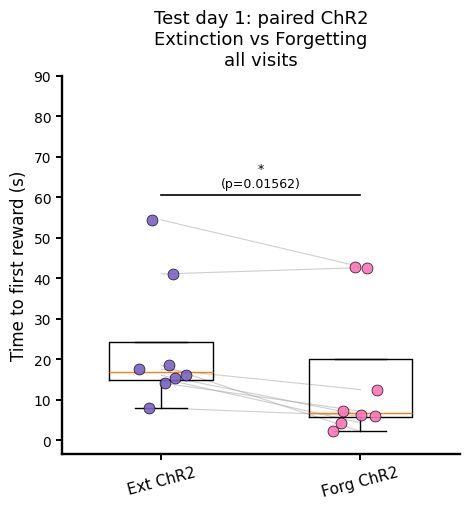


Paired ChR2 Extinction vs Forgetting, test day 5
Using: t_to_trigger (all visits)

Paired animals:
   sub  id  ext_value_s  forg_value_s
0    6  AB    21.921000      7.113000
1    7  AC     0.081000      8.745000
2   10  AF     0.525000     68.430000
3   11  AG     0.482000     19.450000
4   16  AM    51.870667     35.145000
5   17  AN    76.528667     56.019667
6   18  AO    38.990333     79.069400
Wilcoxon paired test: n=7, Ext mean=27.200, Forg mean=39.139, Ext median=21.921, Forg median=35.145, stat=10.000, p=0.57812


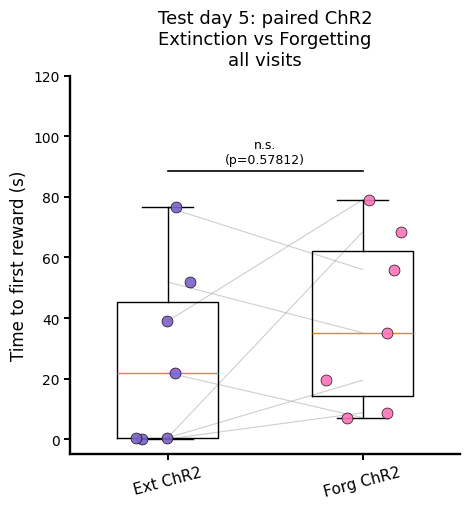

In [329]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon

# ============================================================
# Flexible genotype:
# Plot TEST trials across test days 1-5
# Metric: time to first reward zone
#
# Can use either:
#   USE_LONG_VISITS = False -> t_to_trigger      = all visits
#   USE_LONG_VISITS = True  -> t_to_trigger_long = only visits lasting >2 s
#
# Your computing code already created:
#   metadata['t_to_trigger']
#   metadata['t_to_trigger_long']
#
# Also produces boxplot comparisons:
#
# Day 1 and Day 5:
#   1) Extinction ChR2 vs Forgetting ChR2
#   2) Extinction ChR2 vs Extinction eYFP
#   3) Forgetting ChR2 vs Forgetting eYFP
#
# Day 2, Day 3, Day 4:
#   1) Extinction ChR2 vs Extinction eYFP
#
# Additional paired Wilcoxon boxplots:
#   Day 1: Extinction ChR2 vs Forgetting ChR2
#   Day 5: Extinction ChR2 vs Forgetting ChR2
#
# These paired plots use only animals that have BOTH extinction
# and forgetting values on that test day.
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------

USE_LONG_VISITS = False
# USE_LONG_VISITS = False

GENOTYPES_TO_PLOT = ['ChR2', 'eYFP_ChR2']

EXCLUDE_ID = []
EXCLUDE_SUBS = []

max_day = 5
day_values = np.arange(1, max_day + 1)

# Line plot SEM option:
#   'bar'    -> SEM error bars
#   'shaded' -> shaded SEM band
SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded'

# y-axis padding for line plot
Y_ZERO_PAD_FRAC = 0.04
Y_TOP_PAD_FRAC = 0.15

# Optional manual line-plot y-axis max, in seconds
YMAX = None
# YMAX = 120

# Boxplot options
RUN_DAY_BOXPLOTS = True
BOXPLOT_DAYS = [1, 2, 3, 4, 5]

# New paired Wilcoxon plots:
RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS = True
PAIRED_CHR2_DAYS = [1, 5]
SHOW_PAIRED_LINES = True

SHOW_ANIMAL_IDS = False

JITTER = 0.10
DOT_SIZE = 62
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

BOX_YMIN = None
BOX_YMAX = None
BOX_Y_ZERO_PAD_FRAC = 0.04
BOX_Y_TOP_PAD_FRAC = 0.35
BOX_Y_TICK_STEP = None

P_DECIMALS = 5
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.30
P_TEXT_OFFSET_FRAC = 0.02

# ------------------------------------------------------------
# Choose time column based on visit criterion
# ------------------------------------------------------------
if USE_LONG_VISITS:
    TIME_COL = 't_to_trigger_long'
    STAY_TAG = '≥2 s stay'
else:
    TIME_COL = 't_to_trigger'
    STAY_TAG = 'all visits'

TIME_LABEL = 'Time to first reward (s)'

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
    'ChR2_short': 'VTA short',
    'ArchT': 'ArchT',
    'Arch_T': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'eYFP_Arch_T': 'eYFP ArchT',
    'WT': 'WT',
}

np.random.seed(1)


# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


def mean_and_sem(mat):
    """
    Robust mean/SEM:
      - returns NaN for days where all animals are NaN
      - avoids RuntimeWarnings from nanmean/nanstd
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = np.isfinite(col)
        n = valid.sum()

        if n == 0:
            continue

        mean[j] = col[valid].mean()

        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
        else:
            sem[j] = 0.0

    return mean, sem


def build_subject_matrix(meta_group, value_col):
    """
    For each subject, compute mean time-to-first-reward for each test day.
    Returns matrix: n_subjects x max_day, values in ms.
    """
    performance_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub].copy()

        mean_d = (
            m.groupby('trial_type_day', as_index=True)[value_col]
             .mean()
             .sort_index()
        )

        vec = np.full(max_day, np.nan)

        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

        if 'id' in m.columns and m['id'].notna().any():
            animal_ids.append(str(m['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(performance_mat) == 0:
        return None, [], []

    return np.vstack(performance_mat), subjects, animal_ids


def plot_group(mat, color, label):
    """
    Plot mean ± SEM for one group.
    mat is in ms, converted to seconds for plotting.
    """
    if mat is None or mat.size == 0:
        return []

    mean_ms, sem_ms = mean_and_sem(mat)

    if mean_ms is None:
        return []

    mean_s = mean_ms / 1000.0
    sem_s = sem_ms / 1000.0

    plt.plot(
        day_values,
        mean_s,
        '-',
        color=color,
        linewidth=2.1,
        label=label,
        zorder=3
    )

    if SEM_STYLE == 'bar':
        plt.errorbar(
            day_values,
            mean_s,
            yerr=sem_s,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    elif SEM_STYLE == 'shaded':
        plt.fill_between(
            day_values,
            mean_s - sem_s,
            mean_s + sem_s,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

    else:
        raise ValueError("SEM_STYLE must be 'bar' or 'shaded'")

    valid = np.isfinite(mean_s) & np.isfinite(sem_s)
    return list(mean_s[valid])


def plot_forgetting_trend(mat, color):
    """
    Optional dashed line from Day 1 to Day 5 for forgetting groups.
    """
    if mat is None or mat.size == 0:
        return

    mean_ms, _ = mean_and_sem(mat)

    if mean_ms is None:
        return

    mean_s = mean_ms / 1000.0

    if np.isnan(mean_s[0]) or np.isnan(mean_s[-1]):
        return

    plt.plot(
        [day_values[0], day_values[-1]],
        [mean_s[0], mean_s[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4,
        zorder=4
    )


def day_values_from_metadata(meta_df, genotype, test_type, day, value_col):
    """
    Directly extracts one test-day value per animal from meta_T.

    One value per animal = mean of all available T trials on that test day.
    """
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        value_ms = ms[value_col].mean()

        if not np.isfinite(value_ms):
            continue

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        rows.append({
            'sub': sub,
            'id': animal_id,
            'genotype': genotype,
            'test_type': test_type,
            'day': day,
            'value_s': float(value_ms) / 1000.0
        })

    return pd.DataFrame(rows)


def paired_ext_vs_forg_chr2_df(meta_df, test_day, value_col):
    """
    Build paired dataframe for ChR2 animals that have both:
      - extinction value
      - forgetting value

    on the same test day.

    One value per animal/test_type/day = mean of available T trials.
    """
    df_ext = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='extinction',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value_s': 'ext_value_s',
        'id': 'ext_id',
    })

    df_forg = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='forgetting',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value_s': 'forg_value_s',
        'id': 'forg_id',
    })

    if len(df_ext) == 0 or len(df_forg) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'ext_value_s', 'forg_value_s'])

    paired = df_ext[['sub', 'ext_id', 'ext_value_s']].merge(
        df_forg[['sub', 'forg_id', 'forg_value_s']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['ext_id'].fillna(paired['forg_id'])

    paired = paired[
        paired['ext_value_s'].notna() &
        paired['forg_value_s'].notna() &
        np.isfinite(paired['ext_value_s']) &
        np.isfinite(paired['forg_value_s'])
    ].copy()

    return paired[['sub', 'id', 'ext_value_s', 'forg_value_s']]


def run_wilcoxon(a, b):
    """
    Paired Wilcoxon signed-rank test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    # scipy wilcoxon can fail if all paired differences are exactly zero
    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    stat, p = wilcoxon(a, b, alternative='two-sided')
    return stat, p


def apply_box_y_axis(ax, all_vals, y_top_extra=None):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(all_vals)

        if y_top_extra is not None and np.isfinite(y_top_extra):
            y_top = max(y_top, y_top_extra)

        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if BOX_YMAX is not None:
        y_top = BOX_YMAX
    else:
        y_top = y_top * (1 + BOX_Y_TOP_PAD_FRAC)

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 1. Restrict to TEST trials, desired genotypes, and selected time column
# ============================================================

needed_cols = [
    'trial_type',
    'genotype',
    'trial_type_day',
    'sub',
    TIME_COL,
    'test_type',
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(GENOTYPES_TO_PLOT)) &
    (metadata[TIME_COL].notna()) &
    (np.isfinite(metadata[TIME_COL]))
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_T.columns:
    meta_T = meta_T[
        ~meta_T['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_T = meta_T[
        ~meta_T['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_T = meta_T[meta_T['trial_type_day'].isin(day_values)].copy()

print("\n============================================================")
print("Forgetting vs Extinction plot")
print("Using column:", TIME_COL)
print("Visit criterion:", STAY_TAG)
print("Genotypes:", GENOTYPES_TO_PLOT)
print("SEM style:", SEM_STYLE)

if len(meta_T) == 0:
    print("No rows left after filtering.")

else:
    cols_to_print = ['sub']

    if 'id' in meta_T.columns:
        cols_to_print.append('id')

    cols_to_print += ['genotype', 'test_type']

    if 'short_duration' in meta_T.columns:
        cols_to_print.append('short_duration')

    cols_to_print += ['trial_type_day', TIME_COL]

    print("\nRows after filtering:")
    print(
        meta_T[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )


# ============================================================
# 2. Split by genotype x test_type
# ============================================================

meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2'].copy()
meta_YFP = meta_T[meta_T['genotype'] == 'eYFP_ChR2'].copy()

# Forgetting
perf_f_ChR2, subs_f_ChR2, ids_f_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'forgetting'],
    TIME_COL
)

perf_f_YFP, subs_f_YFP, ids_f_YFP = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'forgetting'],
    TIME_COL
)

# Extinction
perf_e_ChR2, subs_e_ChR2, ids_e_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'extinction'],
    TIME_COL
)

perf_e_YFP, subs_e_YFP, ids_e_YFP = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'extinction'],
    TIME_COL
)

print("\nAnimals included in line plot:")
print(f"  Forgetting ChR2: n = {len(subs_f_ChR2)}, ids = {ids_f_ChR2}, subs = {subs_f_ChR2}")
print(f"  Forgetting eYFP: n = {len(subs_f_YFP)}, ids = {ids_f_YFP}, subs = {subs_f_YFP}")
print(f"  Extinction ChR2: n = {len(subs_e_ChR2)}, ids = {ids_e_ChR2}, subs = {subs_e_ChR2}")
print(f"  Extinction eYFP: n = {len(subs_e_YFP)}, ids = {ids_e_YFP}, subs = {subs_e_YFP}")


# ============================================================
# 3. Line plot
# ============================================================

col_f_ChR2 = "#FF72B8"      # pink, forgetting ChR2
col_e_ChR2 = "#7b62c5ff"    # purple, extinction ChR2
col_f_YFP = "#65a8deff"     # blue, forgetting control
col_e_YFP = "#76787EC1"     # grey, extinction control

plt.figure(figsize=(7.5, 5))

all_y_s = []

# Forgetting ChR2
all_y_s += plot_group(
    perf_f_ChR2,
    col_f_ChR2,
    f'Forgetting – ChR2 (n={len(subs_f_ChR2)})'
)

# Extinction ChR2
all_y_s += plot_group(
    perf_e_ChR2,
    col_e_ChR2,
    f'Extinction – ChR2 (n={len(subs_e_ChR2)})'
)

# Forgetting eYFP
all_y_s += plot_group(
    perf_f_YFP,
    col_f_YFP,
    f'Forgetting – eYFP (n={len(subs_f_YFP)})'
)

# Extinction eYFP
all_y_s += plot_group(
    perf_e_YFP,
    col_e_YFP,
    f'Extinction – eYFP (n={len(subs_e_YFP)})'
)

# Optional dashed trend for forgetting groups
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP, col_f_YFP)

ax = plt.gca()
style_nature(ax, linewidth=1.8)

plt.xlabel('Test day', fontsize=12)
plt.ylabel(TIME_LABEL, fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title(
    f'Forgetting vs Extinction ({STAY_TAG})\nTime to First Reward',
    fontsize=13,
    pad=6
)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    plt.legend(
        frameon=False,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.
    )

# y-axis padding around zero
all_y_s = np.array(all_y_s, dtype=float)
all_y_s = all_y_s[np.isfinite(all_y_s)]

if len(all_y_s) > 0:
    ymax = np.nanmax(all_y_s)

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    if YMAX is not None:
        ymax_plot = YMAX
    else:
        ymax_plot = ymax * (1 + Y_TOP_PAD_FRAC)

    ax.set_ylim(-Y_ZERO_PAD_FRAC * ymax_plot, ymax_plot)

    yticks = ax.get_yticks()
    yticks = yticks[yticks >= 0]

    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# ============================================================
# 4. Boxplot helper for individual test days
# ============================================================

def plot_day_boxplot(test_day):
    """
    Day 1 and Day 5:
      Ext ChR2, Forg ChR2, Ext eYFP, Forg eYFP
      Comparisons:
        Ext ChR2 vs Forg ChR2
        Ext ChR2 vs Ext eYFP
        Forg ChR2 vs Forg eYFP

    Day 2, Day 3, Day 4:
      Ext ChR2, Ext eYFP only
      Comparison:
        Ext ChR2 vs Ext eYFP
    """

    df_f_ChR2 = day_values_from_metadata(meta_T, 'ChR2', 'forgetting', test_day, TIME_COL)
    df_e_ChR2 = day_values_from_metadata(meta_T, 'ChR2', 'extinction', test_day, TIME_COL)
    df_f_YFP = day_values_from_metadata(meta_T, 'eYFP_ChR2', 'forgetting', test_day, TIME_COL)
    df_e_YFP = day_values_from_metadata(meta_T, 'eYFP_ChR2', 'extinction', test_day, TIME_COL)

    if test_day in [1, 5]:
        box_groups = [
            {
                'key': 'e_ChR2',
                'label': 'Ext ChR2',
                'df': df_e_ChR2,
                'color': col_e_ChR2,
            },
            {
                'key': 'f_ChR2',
                'label': 'Forg ChR2',
                'df': df_f_ChR2,
                'color': col_f_ChR2,
            },
            {
                'key': 'e_YFP',
                'label': 'Ext eYFP',
                'df': df_e_YFP,
                'color': col_e_YFP,
            },
            {
                'key': 'f_YFP',
                'label': 'Forg eYFP',
                'df': df_f_YFP,
                'color': col_f_YFP,
            },
        ]

        comparisons = [
            ('e_ChR2', 'f_ChR2'),
            ('e_ChR2', 'e_YFP'),
            ('f_ChR2', 'f_YFP'),
        ]

    else:
        box_groups = [
            {
                'key': 'e_ChR2',
                'label': 'Ext ChR2',
                'df': df_e_ChR2,
                'color': col_e_ChR2,
            },
            {
                'key': 'e_YFP',
                'label': 'Ext eYFP',
                'df': df_e_YFP,
                'color': col_e_YFP,
            },
        ]

        comparisons = [
            ('e_ChR2', 'e_YFP'),
        ]

    group_index = {g['key']: i for i, g in enumerate(box_groups)}
    group_lookup = {g['key']: g for g in box_groups}

    vals_groups = [
        g['df']['value_s'].values.astype(float)
        for g in box_groups
    ]

    print("\n============================================================")
    print(f"Test day {test_day} boxplot values")
    print("Using:", TIME_COL, f"({STAY_TAG})")

    for g in box_groups:
        print(
            f"  {g['label']}: "
            f"n = {len(g['df'])}, ids = {list(g['df']['id'])}, "
            f"values_s = {np.round(g['df']['value_s'].values.astype(float), 4)}"
        )

    print(f"\nRaw day {test_day} rows used for boxplot:")
    raw_cols = ['sub']

    if 'id' in meta_T.columns:
        raw_cols.append('id')

    raw_cols += ['genotype', 'test_type', 'trial_type_day', TIME_COL]

    print(
        meta_T[meta_T['trial_type_day'] == test_day][raw_cols]
        .drop_duplicates()
        .sort_values(raw_cols)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(max(5.2, 1.45 * len(box_groups)), 5.2))

    positions = np.arange(len(box_groups))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.52,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(box_groups):
        vals = g['df']['value_s'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=g['color'],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, g['df']['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=g['color'],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    print(f"\nMann–Whitney U tests, test day {test_day}:")

    stats_to_draw = []

    for g1, g2 in comparisons:
        vals1 = group_lookup[g1]['df']['value_s'].values.astype(float)
        vals2 = group_lookup[g2]['df']['value_s'].values.astype(float)

        vals1 = vals1[np.isfinite(vals1)]
        vals2 = vals2[np.isfinite(vals2)]

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        label1 = group_lookup[g1]['label']
        label2 = group_lookup[g2]['label']

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {label1} vs {label2}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p)}"
            )

            stats_to_draw.append((
                group_index[g1],
                group_index[g2],
                p
            ))

        else:
            print(f"  {label1} vs {label2}: p = NaN")

    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                draw_sig_bar(ax, x1, x2, current_y, p, yrng)
                current_y += y_step

            apply_box_y_axis(ax, all_vals, y_top_extra=current_y)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [g['label'] for g in box_groups],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(TIME_LABEL, fontsize=12)

    ax.set_title(
        f'Test day {test_day} time to first reward\n'
        f'{STAY_TAG}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Paired Wilcoxon plot:
#    Extinction ChR2 vs Forgetting ChR2
# ============================================================

def plot_paired_chr2_ext_vs_forg_boxplot(test_day):
    paired_df = paired_ext_vs_forg_chr2_df(
        meta_df=meta_T,
        test_day=test_day,
        value_col=TIME_COL
    )

    print("\n============================================================")
    print(f"Paired ChR2 Extinction vs Forgetting, test day {test_day}")
    print("Using:", TIME_COL, f"({STAY_TAG})")

    if len(paired_df) == 0:
        print("No paired ChR2 animals with both extinction and forgetting values.")
        return

    ext_vals = paired_df['ext_value_s'].values.astype(float)
    forg_vals = paired_df['forg_value_s'].values.astype(float)

    stat, p = run_wilcoxon(ext_vals, forg_vals)

    print("\nPaired animals:")
    print(
        paired_df[
            ['sub', 'id', 'ext_value_s', 'forg_value_s']
        ].reset_index(drop=True)
    )

    print(
        f"Wilcoxon paired test: "
        f"n={len(paired_df)}, "
        f"Ext mean={np.nanmean(ext_vals):.3f}, "
        f"Forg mean={np.nanmean(forg_vals):.3f}, "
        f"Ext median={np.nanmedian(ext_vals):.3f}, "
        f"Forg median={np.nanmedian(forg_vals):.3f}, "
        f"stat={stat:.3f}, "
        f"p={format_p(p)}"
    )

    fig, ax = plt.subplots(figsize=(4.8, 5.2))

    vals_groups = [ext_vals, forg_vals]
    positions = np.arange(2)

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.52,
        patch_artist=False,
        showfliers=False
    )

    if SHOW_PAIRED_LINES:
        for e, f in zip(ext_vals, forg_vals):
            ax.plot(
                positions,
                [e, f],
                '-',
                color='0.65',
                linewidth=0.8,
                alpha=0.55,
                zorder=1
            )

    for i, (vals, col) in enumerate([
        (ext_vals, col_e_ChR2),
        (forg_vals, col_f_ChR2),
    ]):
        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=col,
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, paired_df['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=col,
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    all_vals = np.r_[ext_vals, forg_vals]
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) > 0:
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        apply_box_y_axis(ax, all_vals, y_top_extra=y)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        ['Ext ChR2', 'Forg ChR2'],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(TIME_LABEL, fontsize=12)

    ax.set_title(
        f'Test day {test_day}: paired ChR2\n'
        f'Extinction vs Forgetting\n'
        f'{STAY_TAG}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Produce day 1-5 boxplots
# ============================================================

if RUN_DAY_BOXPLOTS:
    for d in BOXPLOT_DAYS:
        plot_day_boxplot(d)


# ============================================================
# 7. Produce paired Wilcoxon ChR2 plots
# ============================================================

if RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS:
    for d in PAIRED_CHR2_DAYS:
        plot_paired_chr2_ext_vs_forg_boxplot(d)


Extra learning EL vs L5
Genotype: ChR2 (VTA)
Using: t_to_trigger (all visits)
EL day mode: pooled
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...           ...   
242   18  AO     ChR2          L               5   33             4   
243   18  AO     ChR2          L               5   33             5   
244   18  AO     ChR2          L               5   33             6   
245   18  AO     ChR2          L      

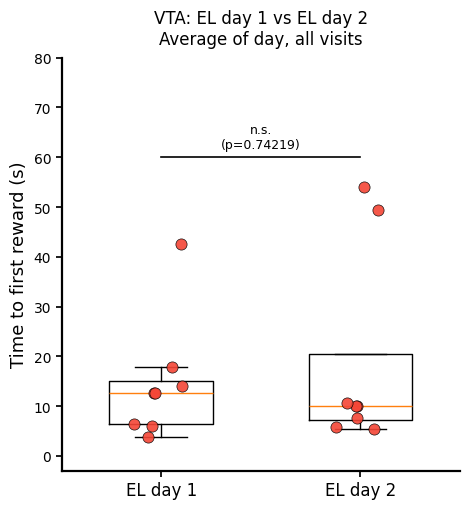


Boxplot: Average of day, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=9.502, EL mean=15.568, L day 5 median=8.475, EL median=9.890, stat=11.000, p=0.10547


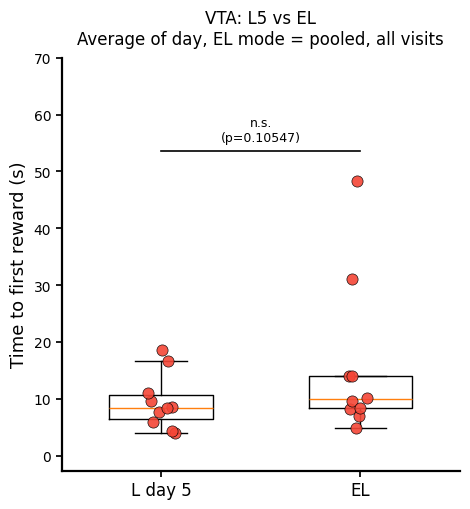


Boxplot: Best trial of day, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=1.140, EL mean=0.582, L day 5 median=0.863, EL median=0.644, stat=18.000, p=0.37500


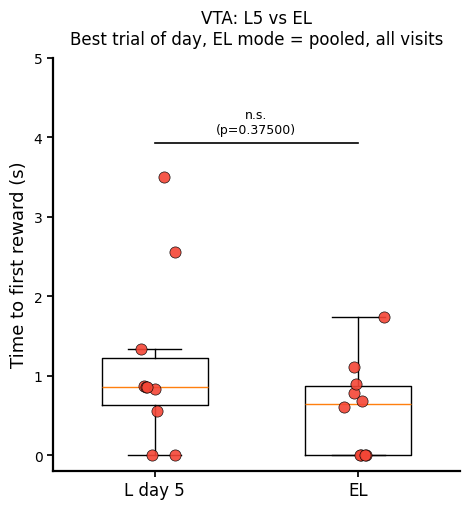


Boxplot: Final trial, trial 8, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=6.153, EL mean=10.359, L day 5 median=3.639, EL median=6.527, stat=14.000, p=0.19336


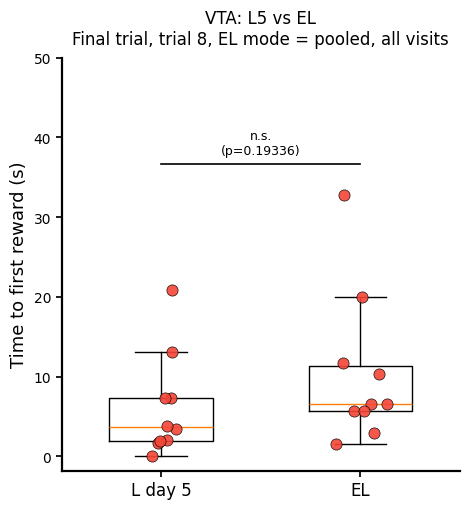


EL trial-by-trial progress plot
EL day mode: pooled
SEM style: shaded
Using: t_to_trigger (all visits)
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


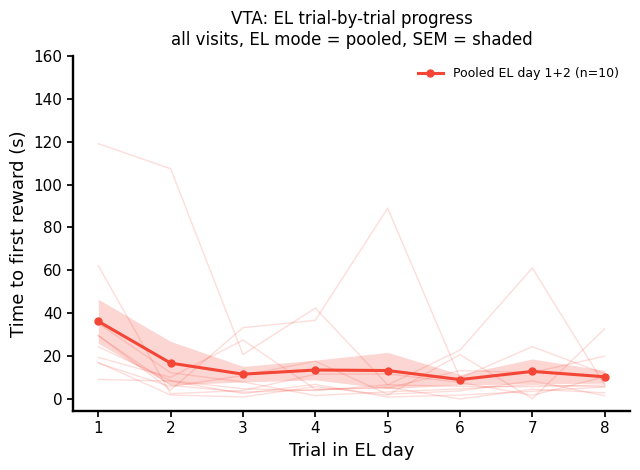

In [321]:
# ============================================================
# Extra learning EL vs last learning day L5
# Genotype: ChR2
#
# Produces:
#   0) Boxplot: EL day 1 vs EL day 2
#      Default metric = average of EL day
#
#   1) Boxplot: average EL day vs average L day 5
#   2) Boxplot: best EL trial vs best L day 5 trial
#   3) Boxplot: final EL trial 8 vs final L day 5 trial 8
#
#   4) EL trial-by-trial progress plot across trials 1-8
#      This follows EL_DAY_MODE:
#         'day1'     -> EL day 1 only
#         'day2'     -> EL day 2 only
#         'separate' -> EL day 1 and EL day 2 separately
#         'pooled'   -> EL day 1 and EL day 2 pooled per animal/trial
#
# EL trial_type_day can be 1 or 2.
#
# EL_DAY_MODE:
#   'separate'
#       EL day 1 and EL day 2 are treated as separate observations.
#
#   'day1'
#       only EL trial_type_day == 1
#
#   'day2'
#       only EL trial_type_day == 2
#
#   'pooled'
#       EL day 1 and EL day 2 are averaged per animal first.
#       One EL value per animal.
#
# Visit criterion:
#   USE_LONG_VISITS = False -> t_to_trigger      = all visits
#   USE_LONG_VISITS = True  -> t_to_trigger_long = ≥2 s stay
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

USE_LONG_VISITS = False
# USE_LONG_VISITS = False

EL_DAY_MODE = 'pooled'
# EL_DAY_MODE = 'day1'
# EL_DAY_MODE = 'day2'
# EL_DAY_MODE = 'separate'
# EL_DAY_MODE = 'pooled'

FILTER_SHORT_DURATION = False

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

SHOW_ANIMAL_IDS = False

# No paired lines by default
SHOW_PAIRED_LINES = False

FINAL_TRIAL_N = 8

# If True, require each paired comparison to have both values.
REQUIRE_PAIRED = True

# Stats:
#   wilcoxon is paired and best for same-animal comparisons.
#   mannwhitney is unpaired.
STAT_TEST = 'wilcoxon'
# STAT_TEST = 'mannwhitney'

# EL1 vs EL2 boxplot metric:
#   'avg'   -> average of all 8 trials
#   'best'  -> best trial = minimum time
#   'final' -> final trial = trial 8
EL1_VS_EL2_METRIC = 'avg'
# EL1_VS_EL2_METRIC = 'best'
# EL1_VS_EL2_METRIC = 'final'

# ------------------------------------------------------------
# EL trial-by-trial progress plot options
# ------------------------------------------------------------
RUN_EL_TRIAL_PROGRESS_PLOT = True
PLOT_EL_INDIVIDUAL_LINES = True

# New option:
#   'bar'    -> SEM error bars
#   'shaded' -> shaded SEM area
#   'none'   -> mean line only
EL_PROGRESS_SEM_STYLE = 'shaded'
# EL_PROGRESS_SEM_STYLE = 'shaded' or 'bar'
# EL_PROGRESS_SEM_STYLE = 'none'

EL_TRIAL_YMIN = None
EL_TRIAL_YMAX = None
EL_TRIAL_Y_ZERO_PAD_FRAC = 0.04
EL_TRIAL_Y_TOP_PAD_FRAC = 0.18

# Plot styling
JITTER = 0.06
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5
P_DECIMALS = 5

BOX_YMIN = None
BOX_YMAX = None
BOX_Y_BOTTOM_PAD_FRAC = 0.04
BOX_Y_TICK_STEP = None

P_LINE_START_FRAC = 0.12
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.22

np.random.seed(1)

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'NAc': 'NAc',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

if EL_DAY_MODE not in ['separate', 'day1', 'day2', 'pooled']:
    raise ValueError("EL_DAY_MODE must be 'separate', 'day1', 'day2', or 'pooled'")

if STAT_TEST not in ['wilcoxon', 'mannwhitney']:
    raise ValueError("STAT_TEST must be 'wilcoxon' or 'mannwhitney'")

if EL1_VS_EL2_METRIC not in ['avg', 'best', 'final']:
    raise ValueError("EL1_VS_EL2_METRIC must be 'avg', 'best', or 'final'")

if EL_PROGRESS_SEM_STYLE not in ['bar', 'shaded', 'none']:
    raise ValueError("EL_PROGRESS_SEM_STYLE must be 'bar', 'shaded', or 'none'")


# ============================================================
# Helper functions
# ============================================================

def get_plot_color(genotype):
    try:
        return get_genotype_color(genotype)
    except Exception:
        return '0.3'


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.25)
    ax.grid(False)


def apply_box_y_axis(ax, all_vals, stat_y=None):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(all_vals)

        if stat_y is not None and np.isfinite(stat_y):
            y_top = max(y_top, stat_y)

        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if BOX_YMAX is not None:
        y_top = BOX_YMAX
    else:
        y_top = y_top * (1 + P_TOP_PAD_FRAC)

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.

    Uses existing trial column if present.
    Otherwise infers from sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
        'trial_id',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def trial_summary(ms, value_col):
    """
    Returns:
      average value across trials
      best value = minimum time
      final trial value = trial_in_day == FINAL_TRIAL_N
    """
    if len(ms) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    by_trial = (
        ms.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    avg_val = float(np.nanmean(by_trial.values))
    best_val = float(np.nanmin(by_trial.values))

    if FINAL_TRIAL_N in by_trial.index:
        final_val = float(by_trial.loc[FINAL_TRIAL_N])
    else:
        final_val = np.nan

    return {
        'avg': avg_val,
        'best': best_val,
        'final': final_val,
    }


def run_stat(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)

    if STAT_TEST == 'wilcoxon':
        a = a[ok]
        b = b[ok]

        if len(a) == 0:
            return np.nan, np.nan

        # Wilcoxon fails if all paired differences are exactly zero.
        if np.allclose(a, b, equal_nan=False):
            return np.nan, 1.0

        stat, p = wilcoxon(a, b, alternative='two-sided')
        return stat, p

    if STAT_TEST == 'mannwhitney':
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if len(a) == 0 or len(b) == 0:
            return np.nan, np.nan

        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        return stat, p

    return np.nan, np.nan


def add_sig_bar(ax, positions, p, all_vals):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        return

    ymax = np.nanmax(all_vals)
    ymin = np.nanmin(all_vals)
    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    y = ymax + P_LINE_START_FRAC * yrng

    ax.plot(
        [positions[0], positions[1]],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        np.mean(positions),
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    apply_box_y_axis(ax, all_vals, stat_y=y)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


# ============================================================
# 1. Filter metadata
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    TIME_COL,
]

if FILTER_SHORT_DURATION:
    needed_cols.append('short_duration')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'EL'])) &
    (metadata[TIME_COL].notna()) &
    (np.isfinite(metadata[TIME_COL]))
].copy()

if FILTER_SHORT_DURATION:
    meta = meta[meta['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
    meta = meta[
        ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta = meta[
        ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# Keep L5 and EL1/EL2 only
meta_L5 = meta[
    (meta['trial_type'] == 'L') &
    (meta['trial_type_day'] == 5)
].copy()

meta_EL = meta[
    (meta['trial_type'] == 'EL') &
    (meta['trial_type_day'].isin([1, 2]))
].copy()

if EL_DAY_MODE == 'day1':
    meta_EL = meta_EL[meta_EL['trial_type_day'] == 1].copy()

elif EL_DAY_MODE == 'day2':
    meta_EL = meta_EL[meta_EL['trial_type_day'] == 2].copy()

meta_L5, trial_col_L5 = add_trial_in_day(meta_L5)
meta_EL, trial_col_EL = add_trial_in_day(meta_EL)

# This keeps all EL days for EL1-vs-EL2 and progress plot,
# regardless of whether meta_EL was restricted by EL_DAY_MODE above.
meta_EL_all = meta[
    (meta['trial_type'] == 'EL') &
    (meta['trial_type_day'].isin([1, 2]))
].copy()
meta_EL_all, trial_col_EL_all = add_trial_in_day(meta_EL_all)

trial_col_used = trial_col_EL if trial_col_EL is not None else trial_col_L5

print("\n============================================================")
print("Extra learning EL vs L5")
print("Genotype:", GENOTYPE_TO_PLOT, f"({GROUP_LABEL})")
print("Using:", TIME_COL, f"({STAY_TAG})")
print("EL day mode:", EL_DAY_MODE)
print("EL1 vs EL2 metric:", EL1_VS_EL2_METRIC)
print("Stat test:", STAT_TEST)
print("EL progress SEM style:", EL_PROGRESS_SEM_STYLE)
print("Trial column used:", trial_col_used if trial_col_used is not None else "inferred from sub/ses order")
print("Filter short duration:", FILTER_SHORT_DURATION)

print("\nRows after filtering:")
cols_to_print = ['sub']
if 'id' in meta.columns:
    cols_to_print.append('id')
cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'trial_in_day', TIME_COL]

rows_to_print = pd.concat([meta_L5, meta_EL], ignore_index=True)

if len(rows_to_print) > 0:
    print(
        rows_to_print[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")


# ============================================================
# 2. Build paired comparison dataframe: L5 vs EL
# ============================================================

rows = []

for sub in sorted(set(meta_L5['sub'].unique()).intersection(set(meta_EL['sub'].unique()))):
    ms_L5 = meta_L5[meta_L5['sub'] == sub].copy()

    if len(ms_L5) == 0:
        continue

    animal_id = get_animal_label(ms_L5, sub)
    l5_summary = trial_summary(ms_L5, TIME_COL)

    ms_EL_sub = meta_EL[meta_EL['sub'] == sub].copy()

    if EL_DAY_MODE in ['separate', 'day1', 'day2']:
        for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
            ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()

            if len(ms_EL_day) == 0:
                continue

            el_summary = trial_summary(ms_EL_day, TIME_COL)

            rows.append({
                'sub': sub,
                'id': animal_id,
                'el_day': int(el_day),
                'obs_label': f'{animal_id} EL{int(el_day)}',
                'L5_avg_ms': l5_summary['avg'],
                'EL_avg_ms': el_summary['avg'],
                'L5_best_ms': l5_summary['best'],
                'EL_best_ms': el_summary['best'],
                'L5_final_ms': l5_summary['final'],
                'EL_final_ms': el_summary['final'],
            })

    elif EL_DAY_MODE == 'pooled':
        el_day_summaries = []

        for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
            ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()
            el_summary = trial_summary(ms_EL_day, TIME_COL)
            el_day_summaries.append(el_summary)

        if len(el_day_summaries) == 0:
            continue

        el_summary_pooled = {
            'avg': np.nanmean([d['avg'] for d in el_day_summaries]),
            'best': np.nanmin([d['best'] for d in el_day_summaries]),
            'final': np.nanmean([d['final'] for d in el_day_summaries]),
        }

        rows.append({
            'sub': sub,
            'id': animal_id,
            'el_day': 'pooled',
            'obs_label': f'{animal_id} pooled EL',
            'L5_avg_ms': l5_summary['avg'],
            'EL_avg_ms': el_summary_pooled['avg'],
            'L5_best_ms': l5_summary['best'],
            'EL_best_ms': el_summary_pooled['best'],
            'L5_final_ms': l5_summary['final'],
            'EL_final_ms': el_summary_pooled['final'],
        })

compare_df = pd.DataFrame(rows)

if REQUIRE_PAIRED and len(compare_df) > 0:
    metric_pairs = [
        ('L5_avg_ms', 'EL_avg_ms'),
        ('L5_best_ms', 'EL_best_ms'),
        ('L5_final_ms', 'EL_final_ms'),
    ]

    keep = np.ones(len(compare_df), dtype=bool)

    for l5_col, el_col in metric_pairs:
        keep = keep & compare_df[l5_col].notna().values & compare_df[el_col].notna().values

    compare_df = compare_df[keep].copy()

print("\nComparison table, values in seconds:")
if len(compare_df) > 0:
    print_df = compare_df.copy()

    for col in [
        'L5_avg_ms', 'EL_avg_ms',
        'L5_best_ms', 'EL_best_ms',
        'L5_final_ms', 'EL_final_ms'
    ]:
        print_df[col.replace('_ms', '_s')] = print_df[col] / 1000.0

    print(
        print_df[
            [
                'sub', 'id', 'el_day', 'obs_label',
                'L5_avg_s', 'EL_avg_s',
                'L5_best_s', 'EL_best_s',
                'L5_final_s', 'EL_final_s',
            ]
        ].reset_index(drop=True)
    )
else:
    print("No paired L5/EL observations available.")


# ============================================================
# 2b. Build paired dataframe: EL day 1 vs EL day 2
# ============================================================

el12_rows = []

for sub in sorted(meta_EL_all['sub'].unique()):
    ms_sub = meta_EL_all[meta_EL_all['sub'] == sub].copy()

    ms_el1 = ms_sub[ms_sub['trial_type_day'] == 1].copy()
    ms_el2 = ms_sub[ms_sub['trial_type_day'] == 2].copy()

    if len(ms_el1) == 0 or len(ms_el2) == 0:
        continue

    animal_id = get_animal_label(ms_sub, sub)

    el1_summary = trial_summary(ms_el1, TIME_COL)
    el2_summary = trial_summary(ms_el2, TIME_COL)

    el12_rows.append({
        'sub': sub,
        'id': animal_id,
        'EL1_avg_ms': el1_summary['avg'],
        'EL2_avg_ms': el2_summary['avg'],
        'EL1_best_ms': el1_summary['best'],
        'EL2_best_ms': el2_summary['best'],
        'EL1_final_ms': el1_summary['final'],
        'EL2_final_ms': el2_summary['final'],
    })

el12_df = pd.DataFrame(el12_rows)

print("\nEL day 1 vs EL day 2 table, values in seconds:")
if len(el12_df) > 0:
    print_el12 = el12_df.copy()

    for col in [
        'EL1_avg_ms', 'EL2_avg_ms',
        'EL1_best_ms', 'EL2_best_ms',
        'EL1_final_ms', 'EL2_final_ms',
    ]:
        print_el12[col.replace('_ms', '_s')] = print_el12[col] / 1000.0

    print(
        print_el12[
            [
                'sub', 'id',
                'EL1_avg_s', 'EL2_avg_s',
                'EL1_best_s', 'EL2_best_s',
                'EL1_final_s', 'EL2_final_s',
            ]
        ].reset_index(drop=True)
    )
else:
    print("No animals with both EL day 1 and EL day 2.")


# ============================================================
# 3. Boxplot helpers
# ============================================================

def plot_two_condition_boxplot(
    plot_df,
    left_col,
    right_col,
    left_label,
    right_label,
    title_main,
    title_suffix,
    obs_label_col='obs_label'
):
    if len(plot_df) == 0:
        print(f"\nSkipping {title_suffix}: no data.")
        return

    plot_df = plot_df[
        plot_df[left_col].notna() &
        plot_df[right_col].notna()
    ].copy()

    if len(plot_df) == 0:
        print(f"\nSkipping {title_suffix}: no finite paired values.")
        return

    left_vals_s = plot_df[left_col].values.astype(float) / 1000.0
    right_vals_s = plot_df[right_col].values.astype(float) / 1000.0

    vals_groups = [left_vals_s, right_vals_s]
    positions = np.arange(2)

    stat, p = run_stat(left_vals_s, right_vals_s)

    if obs_label_col in plot_df.columns:
        obs_labels = list(plot_df[obs_label_col])
    else:
        obs_labels = list(plot_df['id'])

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print("Animals/observations included:")
    print(obs_labels)

    print(
        f"{STAT_TEST}: "
        f"n={len(left_vals_s)}, "
        f"{left_label} mean={np.nanmean(left_vals_s):.3f}, "
        f"{right_label} mean={np.nanmean(right_vals_s):.3f}, "
        f"{left_label} median={np.nanmedian(left_vals_s):.3f}, "
        f"{right_label} median={np.nanmedian(right_vals_s):.3f}, "
        f"stat={stat:.3f}, "
        f"p={format_p(p)}"
    )

    fig, ax = plt.subplots(figsize=(4.8, 5.2))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.52,
        patch_artist=False,
        showfliers=False
    )

    col = get_plot_color(GENOTYPE_TO_PLOT)

    if SHOW_PAIRED_LINES:
        for left_y, right_y in zip(left_vals_s, right_vals_s):
            ax.plot(
                positions,
                [left_y, right_y],
                '-',
                color='0.65',
                linewidth=0.8,
                alpha=0.55,
                zorder=1
            )

    for i, vals in enumerate(vals_groups):
        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=col,
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, obs_labels):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=col,
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    all_vals = np.r_[left_vals_s, right_vals_s]
    add_sig_bar(ax, positions, p, all_vals)

    ax.set_xticks(positions)
    ax.set_xticklabels([left_label, right_label], fontsize=12)

    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_title(
        f'{title_main}\n'
        f'{title_suffix}, {STAY_TAG}',
        fontsize=12,
        pad=10
    )

    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


def plot_l5_vs_el_boxplot(l5_col, el_col, title_suffix):
    plot_two_condition_boxplot(
        plot_df=compare_df,
        left_col=l5_col,
        right_col=el_col,
        left_label='L day 5',
        right_label='EL',
        title_main=f'{GROUP_LABEL}: L5 vs EL',
        title_suffix=f'{title_suffix}, EL mode = {EL_DAY_MODE}',
        obs_label_col='obs_label'
    )


def plot_el1_vs_el2_boxplot():
    metric_to_cols = {
        'avg': ('EL1_avg_ms', 'EL2_avg_ms', 'Average of day'),
        'best': ('EL1_best_ms', 'EL2_best_ms', 'Best trial of day'),
        'final': ('EL1_final_ms', 'EL2_final_ms', f'Final trial, trial {FINAL_TRIAL_N}'),
    }

    left_col, right_col, metric_title = metric_to_cols[EL1_VS_EL2_METRIC]

    plot_two_condition_boxplot(
        plot_df=el12_df,
        left_col=left_col,
        right_col=right_col,
        left_label='EL day 1',
        right_label='EL day 2',
        title_main=f'{GROUP_LABEL}: EL day 1 vs EL day 2',
        title_suffix=metric_title,
        obs_label_col='id'
    )


# ============================================================
# 4. Produce boxplots
# ============================================================

plot_el1_vs_el2_boxplot()

plot_l5_vs_el_boxplot(
    l5_col='L5_avg_ms',
    el_col='EL_avg_ms',
    title_suffix='Average of day'
)

plot_l5_vs_el_boxplot(
    l5_col='L5_best_ms',
    el_col='EL_best_ms',
    title_suffix='Best trial of day'
)

plot_l5_vs_el_boxplot(
    l5_col='L5_final_ms',
    el_col='EL_final_ms',
    title_suffix=f'Final trial, trial {FINAL_TRIAL_N}'
)


# ============================================================
# 5. EL trial-by-trial progress plot
# ============================================================

def build_el_trial_matrix(meta_el, mode):
    """
    Returns a dictionary of matrices for EL trial-by-trial plotting.

    Each matrix is animal x trial_in_day, values in ms.

    mode:
      'day1':
          one matrix for EL day 1 only

      'day2':
          one matrix for EL day 2 only

      'separate':
          one matrix for EL day 1 and one matrix for EL day 2

      'pooled':
          one matrix where EL1/EL2 are averaged per animal per trial
    """
    trials = np.arange(1, 9)
    matrices = {}

    if len(meta_el) == 0:
        return matrices

    if mode == 'day1':
        days_to_plot = [1]
    elif mode == 'day2':
        days_to_plot = [2]
    elif mode == 'separate':
        days_to_plot = [1, 2]
    elif mode == 'pooled':
        days_to_plot = ['pooled']
    else:
        raise ValueError("mode must be 'day1', 'day2', 'separate', or 'pooled'")

    if mode in ['day1', 'day2', 'separate']:

        for el_day in days_to_plot:
            md = meta_el[meta_el['trial_type_day'] == el_day].copy()

            if len(md) == 0:
                continue

            rows = []
            ids = []

            for sub in sorted(md['sub'].unique()):
                ms = md[md['sub'] == sub].copy()

                by_trial = (
                    ms.groupby('trial_in_day', as_index=True)[TIME_COL]
                      .mean()
                      .sort_index()
                )

                vals = np.array(
                    [by_trial.get(t, np.nan) for t in trials],
                    dtype=float
                )

                if np.all(np.isnan(vals)):
                    continue

                rows.append(vals)
                ids.append(get_animal_label(ms, sub))

            if len(rows) > 0:
                label = f'EL day {el_day}'
                matrices[label] = {
                    'mat': np.vstack(rows),
                    'ids': ids,
                }

    elif mode == 'pooled':

        rows = []
        ids = []

        for sub in sorted(meta_el['sub'].unique()):
            ms = meta_el[meta_el['sub'] == sub].copy()

            # Average EL1/EL2 per trial_in_day for each animal.
            by_trial = (
                ms.groupby('trial_in_day', as_index=True)[TIME_COL]
                  .mean()
                  .sort_index()
            )

            vals = np.array(
                [by_trial.get(t, np.nan) for t in trials],
                dtype=float
            )

            if np.all(np.isnan(vals)):
                continue

            rows.append(vals)
            ids.append(get_animal_label(ms, sub))

        if len(rows) > 0:
            matrices['Pooled EL day 1+2'] = {
                'mat': np.vstack(rows),
                'ids': ids,
            }

    return matrices


def plot_el_trial_progress():
    if not RUN_EL_TRIAL_PROGRESS_PLOT:
        return

    trials = np.arange(1, 9)

    # For the progress plot, follow EL_DAY_MODE.
    # This uses the same filtered meta_EL when day1/day2 are selected,
    # and uses all EL1/EL2 for separate/pooled.
    if EL_DAY_MODE in ['day1', 'day2']:
        progress_meta = meta_EL.copy()
    else:
        progress_meta = meta_EL_all.copy()

    matrices = build_el_trial_matrix(progress_meta, EL_DAY_MODE)

    print("\n============================================================")
    print("EL trial-by-trial progress plot")
    print("EL day mode:", EL_DAY_MODE)
    print("SEM style:", EL_PROGRESS_SEM_STYLE)
    print("Using:", TIME_COL, f"({STAY_TAG})")

    if len(matrices) == 0:
        print("No EL trial-by-trial data available.")
        return

    for label, item in matrices.items():
        print(f"  {label}: n = {item['mat'].shape[0]}, ids = {item['ids']}")

    fig, ax = plt.subplots(figsize=(6.5, 4.8))

    base_col = get_plot_color(GENOTYPE_TO_PLOT)

    # Slightly different colours for EL1/EL2 when separate.
    plot_cols = {
        'EL day 1': base_col,
        'EL day 2': '0.45',
        'Pooled EL day 1+2': base_col,
    }

    all_y_s = []

    for label, item in matrices.items():
        mat_ms = item['mat']
        mat_s = mat_ms / 1000.0

        col = plot_cols.get(label, base_col)

        if PLOT_EL_INDIVIDUAL_LINES:
            for row in mat_s:
                ax.plot(
                    trials,
                    row,
                    '-',
                    color=col,
                    alpha=0.18,
                    linewidth=1.0,
                    zorder=1
                )

        mean_s = np.full(len(trials), np.nan)
        sem_s = np.full(len(trials), np.nan)

        for i in range(len(trials)):
            m, s = mean_sem(mat_s[:, i])
            mean_s[i] = m
            sem_s[i] = s

        all_y_s.extend(list(mat_s[np.isfinite(mat_s)].ravel()))

        # ----------------------------------------------------
        # SEM display option
        # ----------------------------------------------------
        if EL_PROGRESS_SEM_STYLE == 'shaded':
            ax.fill_between(
                trials,
                mean_s - sem_s,
                mean_s + sem_s,
                color=col,
                alpha=0.22,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            trials,
            mean_s,
            'o-',
            color=col,
            linewidth=2.2,
            markersize=5,
            label=f'{label} (n={mat_ms.shape[0]})',
            zorder=3
        )

        if EL_PROGRESS_SEM_STYLE == 'bar':
            ax.errorbar(
                trials,
                mean_s,
                yerr=sem_s,
                fmt='none',
                ecolor=col,
                alpha=0.55,
                elinewidth=1.2,
                capsize=3,
                zorder=4
            )

    ax.set_xlabel('Trial in EL day', fontsize=13)
    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(trials)
    ax.set_xticklabels([str(t) for t in trials], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'{GROUP_LABEL}: EL trial-by-trial progress\n'
        f'{STAY_TAG}, EL mode = {EL_DAY_MODE}, SEM = {EL_PROGRESS_SEM_STYLE}',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(frameon=False, fontsize=9)

    all_y_s = np.asarray(all_y_s, dtype=float)
    all_y_s = all_y_s[np.isfinite(all_y_s)]

    if len(all_y_s) > 0:
        if EL_TRIAL_YMAX is not None:
            y_top = EL_TRIAL_YMAX
        else:
            y_top = np.nanmax(all_y_s)
            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0
            y_top = y_top * (1 + EL_TRIAL_Y_TOP_PAD_FRAC)

        if EL_TRIAL_YMIN is not None:
            y_bottom = EL_TRIAL_YMIN
        else:
            y_bottom = -EL_TRIAL_Y_ZERO_PAD_FRAC * y_top

        ax.set_ylim(y_bottom, y_top)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    plt.tight_layout()
    plt.show()


plot_el_trial_progress()

# time to arrive at separate triggers

In [278]:
# COMPUTE time to arrive for each trigger separately
# ----- COMPUTE TIME TO TRIGGER (ANY) + PER-TRIGGER TIMES -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # only recruit usable trials

# ------------------------------------------------------------------
# OPTION: minimum dwell time in trigger zone (in ms)
#   - 2000 → must stay ≥ 2 s
#   - 0    → any entry counts
# ------------------------------------------------------------------
DWELL_MIN_MS = 0   # <--- change here if you want to relax/tighten criterion

# Define columns in metadata
metadata['t_to_trigger'] = 0        # time to first trigger (any trigger) meeting criterion
metadata['learned']      = False      # ever met criterion in any trigger?

R_TRIGGER = (10/1.2)  # radius defining trigger zone

# store per-trigger times here
trigger_rows = []  # each row: {trial_id, trigger_id, t_to_trigger_trig}

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue

    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i+1
        )
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

        # per-trigger: if we know nothing, set all triggers to trial duration
        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,
                't_to_trigger_trig': t_to_trigger
            })
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    
    # ------------------------------------------------------------------
    # Apply dwell-time criterion here ONLY
    # ------------------------------------------------------------------
    if DWELL_MIN_MS > 0:
        df_all_triggers_long = df_all_triggers[df_all_triggers['duration'] >= DWELL_MIN_MS]
    else:
        df_all_triggers_long = df_all_triggers

    # ---- original "first reward anywhere" metric ----
    if len(df_all_triggers_long) == 0:
        # never met criterion in any trigger → use trial duration
        t_to_trigger = position_.iloc[-1]['t']
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

    # ---- per-trigger times (first entry meeting criterion in each trigger) ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers_long[df_all_triggers_long['trigger_id'] == trig_id]
        if len(df_t) == 0:
            # never met criterion in THIS trigger → use trial duration
            t_trig = position_.iloc[-1]['t']
        else:
            t_trig = df_t.iloc[0]['t_enter']

        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            't_to_trigger_trig': t_trig
        })

# Build long-format per-trigger DataFrame and attach metadata columns
df_trig = pd.DataFrame(trigger_rows)

meta_trig = df_trig.merge(
    metadata,
    left_on='trial_id',   # integer from the loop
    right_index=True,     # metadata index 0..len-1
    how='left'
)

 11%|█         | 709/6620 [00:08<01:05, 89.96it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1185/6620 [00:13<00:52, 103.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 40%|███▉      | 2617/6620 [00:28<00:29, 137.52it/s]

...

 81%|████████  | 5360/6620 [00:56<00:12, 98.28it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6493/6620 [01:07<00:01, 126.74it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [01:08<00:00, 96.40it/s] 


ChR2 – Reward zone 1: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
ChR2 – Reward zone 2: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


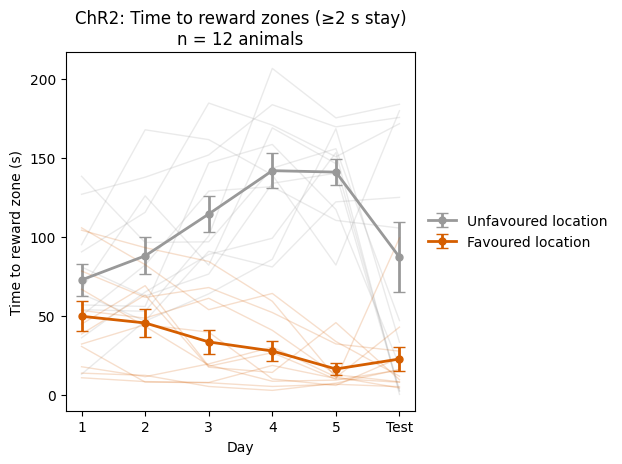

In [38]:

# ============================================================
# Time to reward zone (L1–L5 + first T as Test day 6)
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Zones: trigger_id 1 & 2
#  - Plot individual animals (faded) + group mean ± SEM
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'ChR2'   # 'ChR2', 'ChR2_short', 'Hp'
genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- optional "≥2 s stay" tag in the title ----
SHOW_STAY_TAG = True   # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L/T, usable
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# assign plot_day
mt['plot_day'] = np.nan

# L days: 1–5 from trial_type_day
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

# For each animal, find first T session AFTER last L session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)   # days 1–5 + Test(6)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Build subject × day matrices per reward zone
# ------------------------------------------------------------
def build_zone_matrix(mt_all, trigger_id):
    """
    For a given trigger_id, return:
      - matrix shape (n_animals, n_days)
      - list of subject IDs
    Animals are kept as long as they have SOME non-NaN across days.
    """
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]
    if mt_zone.empty:
        return None, []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days],
                        dtype=float)

        # keep animal if it has at least one valid day
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


zone_ids = [1, 2]  # only 2 reward zones

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"{genotype_label} – Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"  Animal IDs:", subs)
    print("-" * 50)

# ------------------------------------------------------------
# 3) Plot: per reward zone, individual + mean ± SEM
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.size == 0:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,   # ms → s
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM (nan-aware)
    mean_vals = np.nanmean(mat, axis=0)
    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_vals  = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(np.maximum(n_per_day, 1))

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

plt.xlabel('Day')
plt.ylabel('Time to reward zone (s)')
plt.title(
    f'{genotype_label}: Time to reward zones{STAY_TAG}\n'
    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

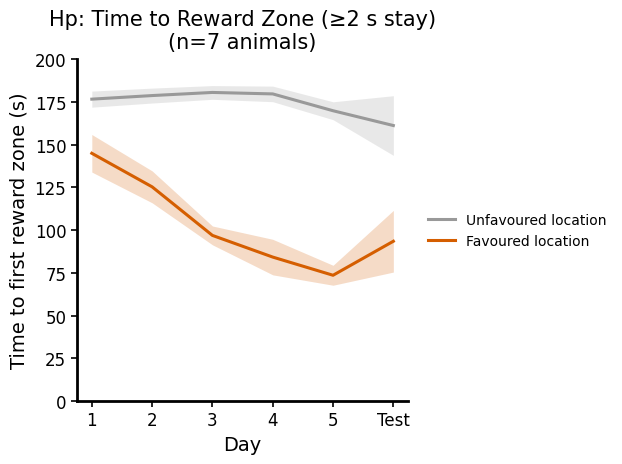

In [16]:
# ----- PLOT: ChR2, PER REWARD ZONE, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM (in seconds)
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )

    # ---- mean line (no individual traces) ----
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'Hp: Time to Reward Zone (≥2 s stay)\n'
    f'(n={n_animals} animals)',
    fontsize=15,
    pad=8
)
# (≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.ylim(0, 200)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA3 (CA3), Favoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C

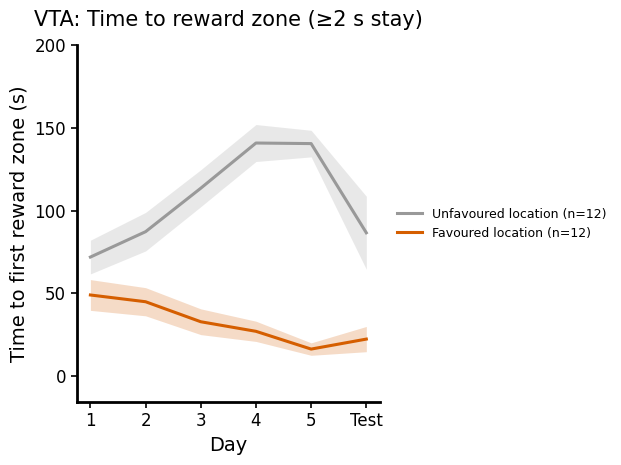

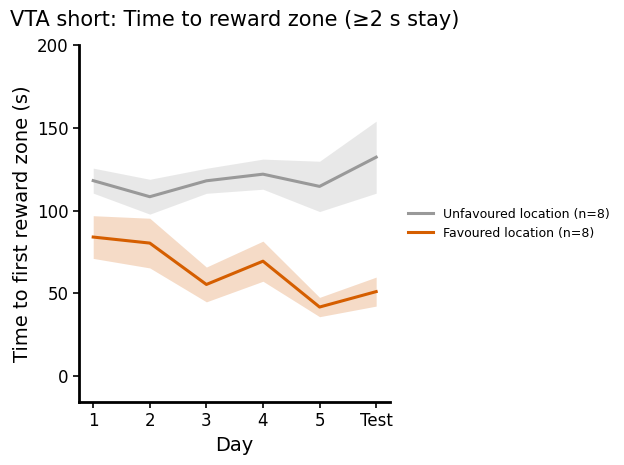

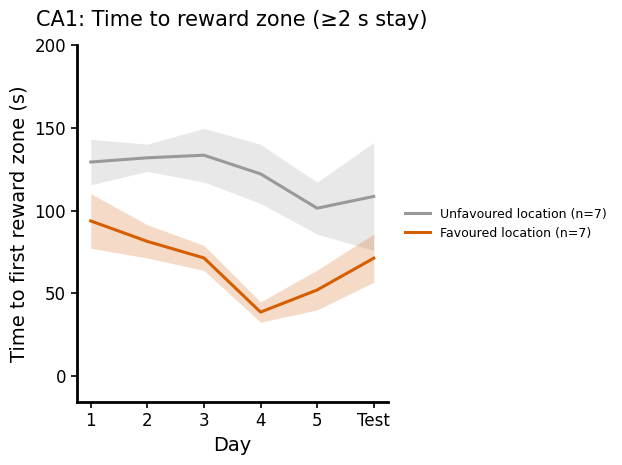

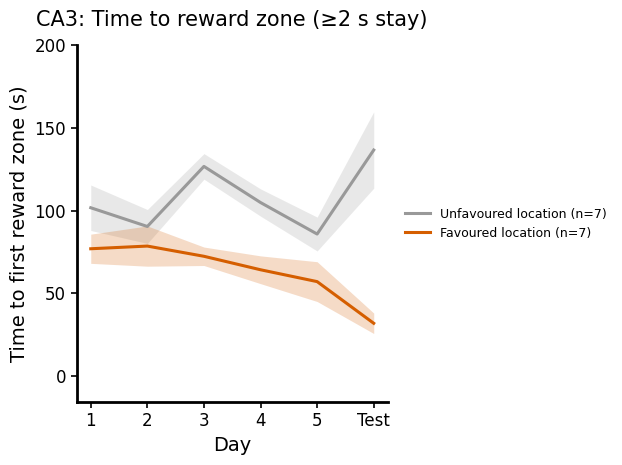

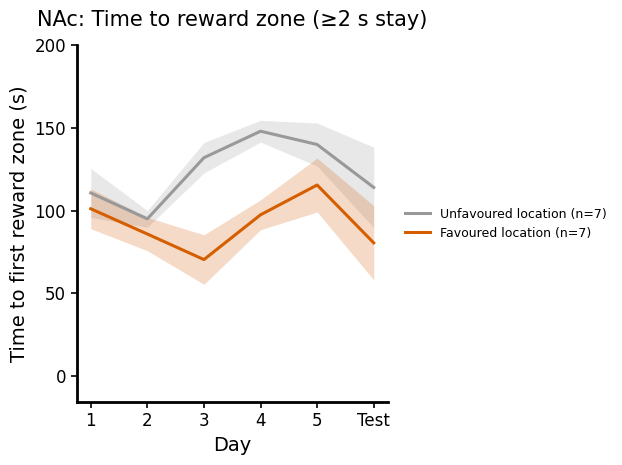

In [128]:
# ============================================================
# Time to reward zone across L1-L5 + Test
# Flexible groups
# Zones: trigger_id 1 & 2
# Plot group mean ± SEM, with optional shading and individual traces
# Requires meta_trig with:
#   - trigger_id
#   - t_to_trigger_trig
# ============================================================

# ============================================================
# OPTIONS
# ============================================================

GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'NAc']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']

EXCLUDE_ID = ['AS', 'AN']      # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []              # e.g. [43]

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

PLOT_MODE = 'separate_figures'   # 'separate_figures' or 'same_figure'

REQUIRE_COMPLETE = False         # True -> only animals with all L1-L5 + Test
PLOT_INDIVIDUAL = False          # True -> faded individual animal traces
SHOW_SEM_SHADING = True          # False -> no shaded SEM band
SHOW_SEM_ERRORBARS = False       # True -> SEM error bars on mean line

SHOW_STAY_TAG = True             # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = ' (≥2 s stay)' if SHOW_STAY_TAG else ''

# Y-axis options
YMIN = None                      # None -> automatically below 0
YMAX = 200                       # e.g. 200, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08         # used if YMIN is None; larger raises 0 more
Y_TICK_STEP = 50                 # e.g. 20, 50, etc.

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Filter metadata
# ============================================================

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'].isin(GROUPS)) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    mt = mt[
        ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    mt = mt[
        ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 2. Assign plot_day: L1-L5 + first post-learning T = Test day 6
# ============================================================

mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
mt = mt[
    (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3. Helpers
# ============================================================

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.2)

def apply_y_axis(ax, ymax_candidates=None):
    if YMAX is not None:
        ymax = YMAX
    else:
        if ymax_candidates is None or len(ymax_candidates) == 0:
            ymax = 200
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 200
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    # integer tick labels
    yticks = np.arange(0, int(np.ceil(ymax)) + 1, Y_TICK_STEP)
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)

def build_zone_matrix(mt_all, genotype, trigger_id):
    """
    Returns:
      - matrix: animal x day, in ms
      - subjects
      - animal_ids
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['genotype'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    if mt_zone.empty:
        return None, [], []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

# ============================================================
# 4. Build matrices
# ============================================================

zone_data = {}

print("Animals included:")
for g in GROUPS:
    zone_data[g] = {}

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_matrix(mt, g, zid)

        zone_data[g][zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

# ============================================================
# 5A. Plot: one figure per genotype, zone 1 vs zone 2
# ============================================================

if PLOT_MODE == 'separate_figures':

    for g in GROUPS:
        fig, ax = plt.subplots(figsize=(7.5, 5))

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            # ms -> s
            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = ZONE_COLORS.get(zid, get_genotype_color(g))
            label = ZONE_LABELS.get(zid, f'Reward zone {zid}')

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        '-',
                        color=col,
                        alpha=0.12,
                        linewidth=1.0,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                '-',
                color=col,
                linewidth=2.2,
                label=f'{label} (n={len(subs)})',
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.2,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: Time to reward zone{STAY_TAG}',
            fontsize=15,
            pad=14
        )

        ax.legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9
        )

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout(rect=[0, 0, 0.85, 0.95])
        plt.show()

# ============================================================
# 5B. Plot: all groups/zones on same figure
# ============================================================

elif PLOT_MODE == 'same_figure':

    fig, ax = plt.subplots(figsize=(8, 5.2))

    line_styles = {
        1: '-',
        2: '--',
    }

    ymax_candidates = []

    for g in GROUPS:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = get_genotype_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        line_styles.get(zid, '-'),
                        color=col,
                        alpha=0.08,
                        linewidth=0.9,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.08,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                line_styles.get(zid, '-'),
                color=col,
                linewidth=2.1,
                label=label,
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.0,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        f'Time to reward zone{STAY_TAG}',
        fontsize=15,
        pad=10
    )

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8
    )

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()

else:
    raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")

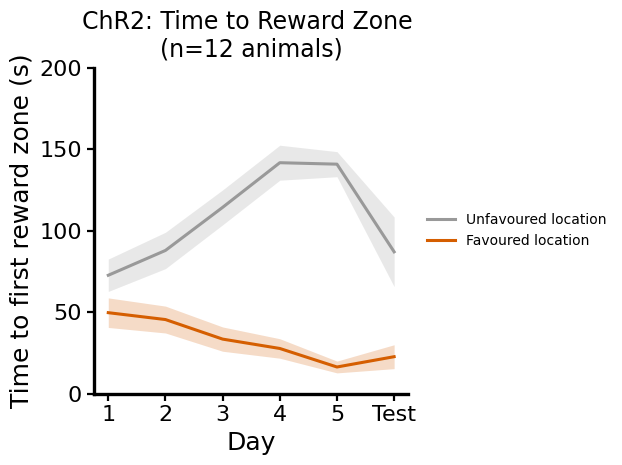

In [39]:
# ChR2 per reward zone - clean figure (larger axes, legend right, vector export)
import os

out_dir = "/Users/stella/Desktop/vector_files"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )
    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# Axes + style (bigger axis text)
ax.set_xlabel('Day', fontsize=18)
ax.set_ylabel('Time to first reward zone (s)', fontsize=18)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.4)
ax.spines['left'].set_linewidth(2.4)
ax.tick_params(direction='out', length=5, width=1.6)

ax.set_title(
    f'ChR2: Time to Reward Zone \n'
    f'(n={n_animals} animals)',
    fontsize=17,
    pad=8
 )
ax.set_ylim(0, 200)

# Legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.tight_layout(rect=[0, 0, 0.85, 0.95])
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.svg'), bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.pdf'), bbox_inches='tight')
plt.show()

Hp – animals included per reward zone (L days 1–5):
  Reward zone 1: 7 animals
  Reward zone 2: 7 animals

Total unique animals included (any zone): 7
Animal IDs: [np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


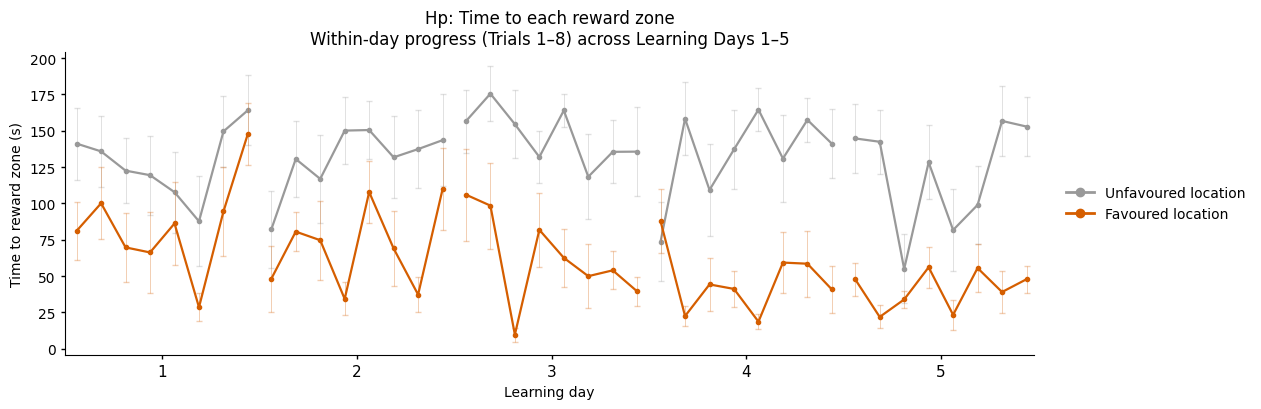

In [ ]:

from matplotlib.lines import Line2D

# ============================================================
# Trial-by-trial time to reward (L-only)
#  - Genotype: choose 'ChR2_short', 'ChR2', or 'Hp'
#  - 5 learning days (1–5)
#  - 8 trials per day
#  - Zones: trigger_id 1 & 2
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'Hp'   # 'ChR2_short', 'ChR2', 'Hp'
genotype_label = {
    'ChR2_short': 'ChR2_short',
    'ChR2':       'ChR2',
    'Hp':         'Hp'
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

days   = np.arange(1, 6)
trials = np.arange(1, 9)
zone_ids = [1,2]


# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L only, days 1–5
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have a per-trial index (trial_in_day = 1..8)
# ------------------------------------------------------------
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    mt[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub', 'ses', 'trial_type_day']
).cumcount() + 1
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

mt = mt.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for one day & one zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id):
    md = mt_all[
        (mt_all['trial_type_day'] == day) &
        (mt_all['trigger_id'] == zone_id)
    ]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials],
                        dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, mt_all, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_ / 1000.0,     # ms → s
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_ / 1000.0, yerr=sem_ / 1000.0,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Plot for chosen genotype
# ------------------------------------------------------------
colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        mt,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

# ---- X/Y labels, ticks, style ----
ax.set_xlabel('Learning day')
ax.set_ylabel('Time to reward zone (s)')

# center ticks under each day block
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days], fontsize=11)

ax.set_xlim(1.0, 5.98)


ax.set_title(
    f'{genotype_label}: Time to each reward zone{STAY_TAG}\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

# journal / NN style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=3, width=1)
ax.grid(False)

legend_handles = [
    Line2D([0], [0], color=colors[1], lw=2, marker='o', label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=2, marker='o', label=labels[2]),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# animal counts (info)
subs_zone = {
    zid: sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}
print(f"{genotype_label} – animals included per reward zone (L days 1–5):")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Hp – First-choice analysis (L trials only)

Total L-trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 58 trials
  Day 5: 56 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1 (unfav)=35, Zone2 (fav)=21
  Day 2:  Zone1 (unfav)=30, Zone2 (fav)=26
  Day 3:  Zone1 (unfav)=17, Zone2 (fav)=39
  Day 4:  Zone1 (unfav)=10, Zone2 (fav)=48
  Day 5:  Zone1 (unfav)=10, Zone2 (fav)=46

Proportions (% of trials):
  Day 1:  Zone1 (unfav)=62.5%, Zone2 (fav)=37.5%
  Day 2:  Zone1 (unfav)=53.6%, Zone2 (fav)=46.4%
  Day 3:  Zone1 (unfav)=30.4%, Zone2 (fav)=69.6%
  Day 4:  Zone1 (unfav)=17.2%, Zone2 (fav)=82.8%
  Day 5:  Zone1 (unfav)=17.9%, Zone2 (fav)=82.1%



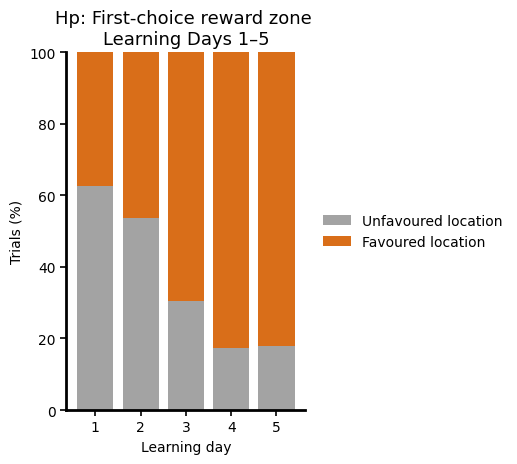

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# First-choice zone (% of trials) for L trials only
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Days: L1–L5 (trial_type_day 1–5)
#  - Zones: 1 = unfavoured, 2 = favoured
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'Hp'      # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L only, not short
# ------------------------------------------------------------
days = np.arange(1, 6)   # L1–L5

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# Use trial_type_day directly as "plot_day"
mt['plot_day'] = mt['trial_type_day'].astype(int)

plot_days = days  # [1..5]

# ------------------------------------------------------------
# 2) First-choice per trial: earliest t_to_trigger_trig
# ------------------------------------------------------------
mt_use = mt.copy()

# one row per trial = the trigger_id with minimal latency
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# ------------------------------------------------------------
# 3) Count choices per day × trigger
#    (only zones 1 & 2 – unfavoured / favoured)
# ------------------------------------------------------------
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2], fill_value=0)
)

# Total L trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)   # 0 if no trials that day

# ------------------------------------------------------------
# 4) Print summary
# ------------------------------------------------------------
print("====================================")
print(f"{genotype_label} – First-choice analysis (L trials only)")
print("====================================")

print("\nTotal L-trials per day:")
for d in plot_days:
    print(f"  Day {d}: {int(total_trials.loc[d])} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={int(row.get(1, 0))}, "
        f"Zone2 (fav)={int(row.get(2, 0))}"
    )

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={row[1]*100:.1f}%, "
        f"Zone2 (fav)={row[2]*100:.1f}%"
    )
print("====================================\n")

# ------------------------------------------------------------
# 5) Plot stacked bars (Zone1 vs Zone2)
# ------------------------------------------------------------
colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(figsize=(6.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2]:
    vals = proportions[trig_id].values * 100  # to %
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.9,
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in plot_days])
ax.set_xlabel('Learning day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title(
    f'{genotype_label}: First-choice reward zone {STAY_TAG}\n'
    'Learning Days 1–5',
    fontsize=13
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

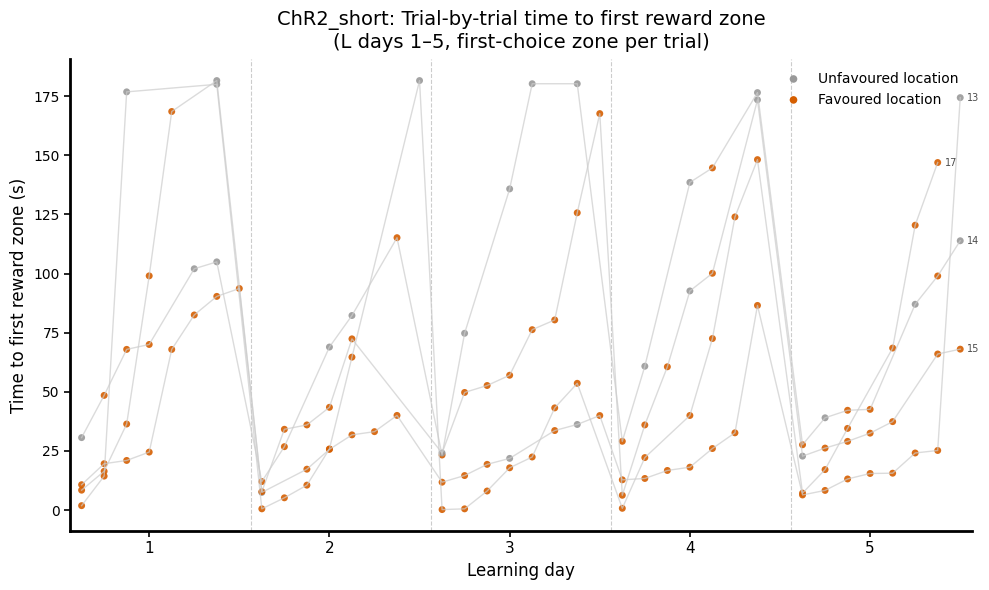

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trial-by-trial time to first reward zone (L only)
# Genotype: 'ChR2', 'ChR2_short', or 'Hp'
# Zone 1 = unfavoured, Zone 2 = favoured
# Days: L1–L5, 8 trials/day → 40 trials total
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L-only, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L')
].copy()

# Use L days 1–5 from trial_type_day
mt = mt[mt['trial_type_day'].isin([1, 2, 3, 4, 5])].copy()
mt['plot_day'] = mt['trial_type_day'].astype(int)

# Keep only zones 1 & 2 (unfavoured / favoured)
mt = mt[mt['trigger_id'].isin([1, 2])].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses) by time
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
group_key = 'trial_id'
if group_key not in mt.columns:
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..40)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (
    (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']
)

# Only L days 1–5 are used
mt_use = first_choice[first_choice['plot_day'].between(1, 5)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

# plot each animal
for sub in sorted(mt_use['sub'].unique()):
    ms = mt_use[mt_use['sub'] == sub].sort_values(['plot_day', 'trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0  # ms → s

    # grey animal-wise trajectory
    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    # coloured points by first-choice zone
    for zid in [1, 2]:
        ms_z = ms[ms['trigger_id'] == zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values) / 1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    # label animal at last trial
    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 L days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators between days
for d in range(1, max_day):
    ax.axvline(d * trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x-tick labels at center of each day block
day_centers = [(d - 0.5) * trials_per_day for d in range(1, max_day + 1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day + 1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Learning day', fontsize=12)
ax.set_ylabel('Time to first reward zone (s)', fontsize=12)

# legend for zones
handles = []
labels = []
for zid in [1, 2]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title(
    f'{genotype_label}: Trial-by-trial time to first reward zone\n'
    '(L days 1–5, first-choice zone per trial)',
    fontsize=14,
    pad=8
)

plt.tight_layout()
plt.show()

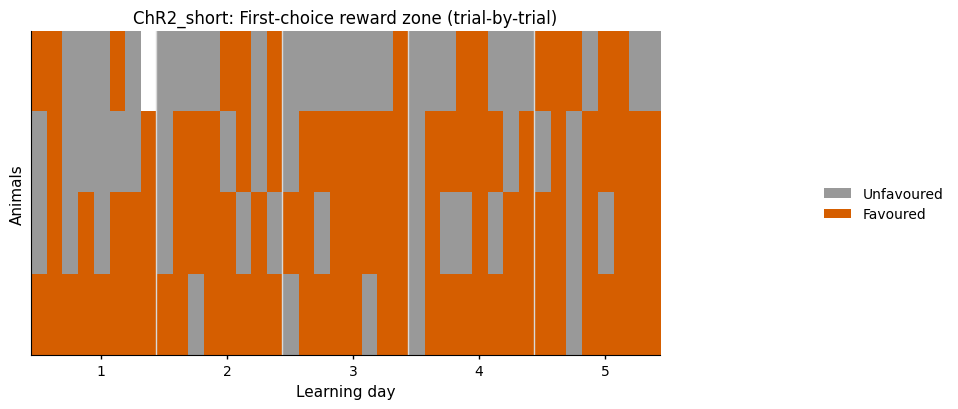

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

# =======================================
# SETTINGS
# =======================================
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', 'Hp'
days = np.arange(1, 6)    # L1–L5
trials_per_day = 8

zone_colors = {
    1: '#999999',  # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured',
    2: 'Favoured',
}

# =======================================
# 1) Filter L-only for genotype
# =======================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# =======================================
# 2) Per-trial index (1..8)
# =======================================
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index':'trial_id'})

trial_table = (
    mt[['trial_id','sub','ses','trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub','ses','trial_type_day','trial_id'])
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub','ses','trial_type_day']
).cumcount() + 1

trial_table = trial_table[trial_table['trial_in_day'].between(1, trials_per_day)]
mt = mt.merge(trial_table[['trial_id','trial_in_day']], on='trial_id', how='inner')

# =======================================
# 3) first-choice zone = min t_to_trigger_trig per trial
# =======================================
idx_first = mt.groupby('trial_id')['t_to_trigger_trig'].idxmin()
fc = mt.loc[idx_first].copy()

fc = fc[fc['trigger_id'].isin([1,2])]   # only two zones

# global trial index = 1..40
fc['trial_idx_global'] = (
    (fc['trial_type_day'] - 1)*trials_per_day + fc['trial_in_day']
)

max_idx = len(days)*trials_per_day   # = 40

# =======================================
# 4) Build animal × trial matrix
# =======================================
animals = sorted(fc['sub'].unique())
n_animals = len(animals)

mat = np.zeros((n_animals, max_idx), dtype=int)

for i, sub in enumerate(animals):
    ms = fc[fc['sub'] == sub]
    for _, r in ms.iterrows():
        ti = int(r['trial_idx_global'])-1
        mat[i, ti] = int(r['trigger_id'])

# =======================================
# 5) sort animals by early preference
# =======================================
early = mat[:, :2*trials_per_day].astype(float)
late  = mat[:, -2*trials_per_day:].astype(float)
early[early==0]=np.nan
late[late==0]=np.nan
mE = np.nanmean(early, axis=1)
mL = np.nanmean(late, axis=1)

order = np.lexsort((mL, mE))
mat = mat[order]
animals_sorted = [animals[i] for i in order]

# =======================================
# 6) PLOT (publication style)
# =======================================
fig, ax = plt.subplots(figsize=(8, 4.2))

cmap = ListedColormap(['white', zone_colors[1], zone_colors[2]])
norm = BoundaryNorm([-0.5,0.5,1.5,2.5], cmap.N)

im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm)

# day separators
for d in range(1, len(days)):
    ax.axvline(d*trials_per_day-0.5, color='0.85', lw=1.0)

# x ticks centered on each day
centers = [(d-0.5)*trials_per_day for d in days]
ax.set_xticks(centers)
ax.set_xticklabels([str(d) for d in days], fontsize=10)

# y axis: small, no clutter
ax.set_yticks([])
ax.set_ylabel('Animals', fontsize=11)
ax.set_xlabel('Learning day', fontsize=11)

# title
ax.set_title(
    f'{GENOTYPE}: First-choice reward zone (trial-by-trial)',
    fontsize=12,
    pad=6
)

# spines minimal
for s in ['top','right']:
    ax.spines[s].set_visible(False)

ax.tick_params(direction='out', length=3, width=1)

# legend outside
handles = [
    Patch(facecolor=zone_colors[1], label=zone_labels[1]),
    Patch(facecolor=zone_colors[2], label=zone_labels[2]),
]
fig.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_80366/2320800996.py:51: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(mat,0)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


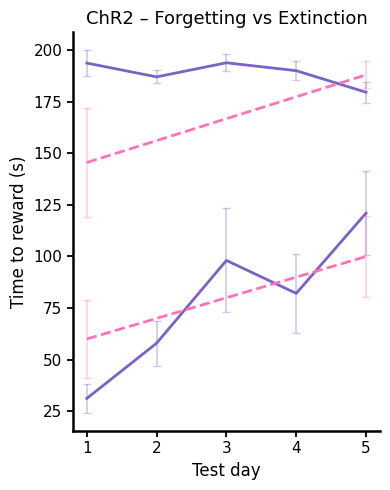

In [16]:
import numpy as np
import matplotlib.pyplot as plt

col_f = "#FF72B8"   # pink (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)

# ------------------------------------------------------------
# Filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction']))
].copy()

max_day = 5
day_values = np.arange(1, max_day+1)

# ------------------------------------------------------------
# helper: subject × day matrix per trigger
# ------------------------------------------------------------
def build_mat(df, trig):
    df = df[df['trigger_id']==trig]
    
    mats = []
    subs = []
    
    for sub in df['sub'].unique():
        ms = df[df['sub']==sub]
        m = ms.groupby('trial_type_day')['t_to_trigger_trig'].mean()
        
        # build 5-day vector (may contain NaNs)
        v = np.array([m.get(d, np.nan) for d in day_values], dtype=float)
        
        # NEW: keep animal if at least 1 valid day
        if np.isnan(v).all():
            continue
        
        mats.append(v)
        subs.append(sub)
    
    if len(mats)==0:
        return None, []
    
    return np.vstack(mats), subs

def mean_sem(mat):
    if mat is None or mat.size==0: return None,None
    mean = np.nanmean(mat,0)
    sem  = np.nanstd(mat,0)/np.sqrt(mat.shape[0])
    return mean, sem

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------
m_f_z1, s_f_z1 = build_mat(meta[meta['test_type']=='forgetting'],1)
m_f_z2, s_f_z2 = build_mat(meta[meta['test_type']=='forgetting'],2)

m_e_z1, s_e_z1 = build_mat(meta[meta['test_type']=='extinction'],1)
m_e_z2, s_e_z2 = build_mat(meta[meta['test_type']=='extinction'],2)

# ------------------------------------------------------------
# Plot single panel
# ------------------------------------------------------------
plt.figure(figsize=(4,5))

# extinction curves full 1-5
for mat,color,label in [(m_e_z1,col_e,'Zone1 extinction'),
                        (m_e_z2,col_e,'Zone2 extinction')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    mean_s = mean_ms/1000; sem_s=sem_ms/1000
    plt.plot(day_values, mean_s, '-', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(day_values, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

# forgetting dashed 1→5
for mat,color,label in [(m_f_z1,col_f,'Zone1 forgetting'),
                        (m_f_z2,col_f,'Zone2 forgetting')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    x = np.array([day_values[0], day_values[-1]])
    mean_s = np.array([mean_ms[0], mean_ms[-1]])/1000
    sem_s  = np.array([sem_ms[0], sem_ms[-1]])/1000
    plt.plot(x, mean_s, '--', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(x, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to reward (s)', fontsize=12)
plt.xticks(day_values, fontsize=11)
plt.yticks(fontsize=11)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.title('ChR2 – Forgetting vs Extinction', fontsize=13, pad=6)
#(>2s stay)

plt.tight_layout()
plt.show()

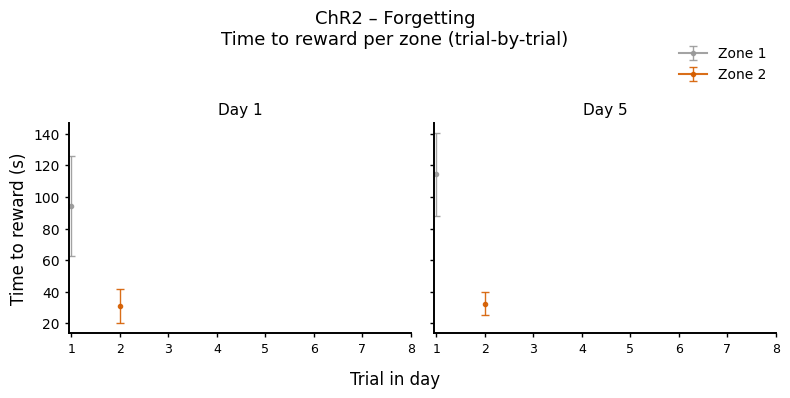

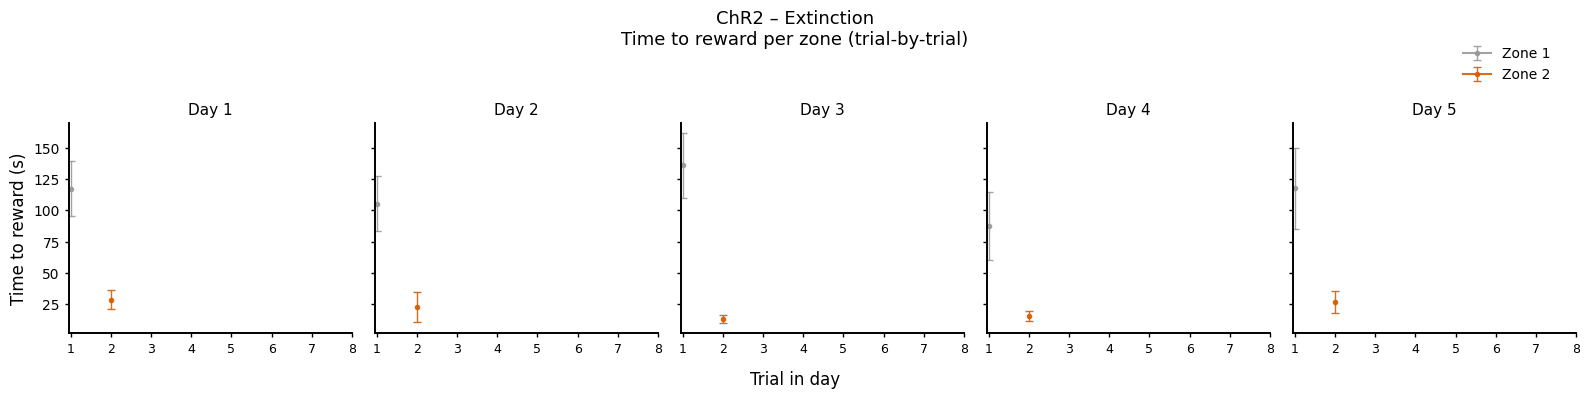

In [ ]:
# revise later - tried to plot for trial to trial progress

# ------------------------------------------------------------
# Base filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

max_day    = 5
day_values = np.arange(1, max_day + 1)
trial_vals = np.arange(1, 9)  # trials 1–8

# ------------------------------------------------------------
# Ensure trial_in_day exists (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta.columns), None)

if trial_col is not None:
    meta['trial_in_day'] = meta[trial_col].astype(int)
else:
    meta = meta.sort_values(['sub', 'ses']).copy()
    meta['trial_in_day'] = meta.groupby(['sub', 'ses']).cumcount() + 1

meta = meta[meta['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# Build mean ± SEM per (day, trial) for each trigger
# ------------------------------------------------------------
def build_day_trial_stats(meta_df, trigger_id):
    """
    For given meta subset (forgetting / extinction) and trigger_id,
    returns:
        stats[day] = (mean_s, sem_s)  # arrays of length = 8 trials
    where units are seconds.
    """
    stats = {}

    df_trig = meta_df[meta_df['trigger_id'] == trigger_id].copy()
    if df_trig.empty:
        return stats

    for day in day_values:
        df_day = df_trig[df_trig['trial_type_day'] == day]
        if df_day.empty:
            continue

        # 1) Average within each animal × trial_in_day
        #    (in case there are multiple T trials per day)
        per_sub_trial = (
            df_day
            .groupby(['sub', 'trial_in_day'])['t_to_trigger_trig']
            .mean()
            .reset_index()
        )

        if per_sub_trial.empty:
            continue

        # 2) Across animals: mean & SEM for each trial_in_day
        g = per_sub_trial.groupby('trial_in_day')['t_to_trigger_trig']
        mean_series = g.mean()
        std_series  = g.std(ddof=1)
        n_series    = g.count()

        mean_ms = np.full(len(trial_vals), np.nan)
        sem_ms  = np.full(len(trial_vals), np.nan)

        for i, t in enumerate(trial_vals):
            if t in mean_series.index:
                mean_ms[i] = mean_series.loc[t]
                n = n_series.loc[t]
                if (n > 1) and not np.isnan(std_series.loc[t]):
                    sem_ms[i] = std_series.loc[t] / np.sqrt(n)

        # store in seconds
        stats[day] = (mean_ms / 1000.0, sem_ms / 1000.0)

    return stats

# ------------------------------------------------------------
# Split forgetting vs extinction and compute stats per zone
# ------------------------------------------------------------
meta_f = meta[meta['test_type'] == 'forgetting'].copy()
meta_e = meta[meta['test_type'] == 'extinction'].copy()

stats_f_z1 = build_day_trial_stats(meta_f, trigger_id=1)
stats_f_z2 = build_day_trial_stats(meta_f, trigger_id=2)

stats_e_z1 = build_day_trial_stats(meta_e, trigger_id=1)
stats_e_z2 = build_day_trial_stats(meta_e, trigger_id=2)

colors = {
    1: '#999999',  # Zone 1 (grey)
    2: '#D55E00',  # Zone 2 (orange)
}

# ============================================================
# FIGURE 1 – FORGETTING: ONLY DAY 1 AND DAY 5
# ============================================================
forget_days = [1, 5]
fig_f, axes_f = plt.subplots(1, len(forget_days), figsize=(8, 3.5), sharey=True)

if len(forget_days) == 1:
    axes_f = [axes_f]

for ax, day in zip(axes_f, forget_days):
    # Zone 1
    if day in stats_f_z1:
        mean_s, sem_s = stats_f_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_f_z2:
        mean_s, sem_s = stats_f_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    # NN-style axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_f[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_f.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_f[0].get_legend_handles_labels()
if handles:
    fig_f.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_f.suptitle('ChR2 – Forgetting\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# ============================================================
# FIGURE 2 – EXTINCTION: DAYS 1–5
# ============================================================
ext_days = day_values
fig_e, axes_e = plt.subplots(1, len(ext_days), figsize=(16, 3.5), sharey=True)

if len(ext_days) == 1:
    axes_e = [axes_e]

for ax, day in zip(axes_e, ext_days):
    # Zone 1
    if day in stats_e_z1:
        mean_s, sem_s = stats_e_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_e_z2:
        mean_s, sem_s = stats_e_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_e[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_e.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_e[0].get_legend_handles_labels()
if handles:
    fig_e.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_e.suptitle('ChR2 – Extinction\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

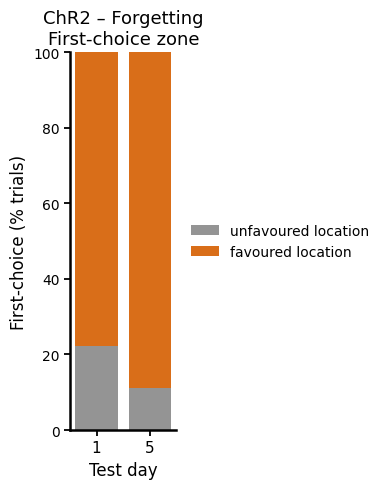

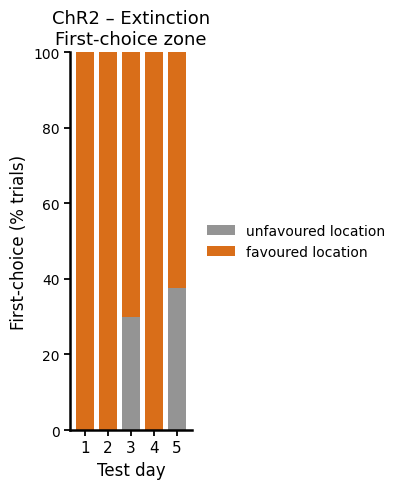

In [ ]:

# ============================================================
# Fade setting (0=transparent, 1=opaque)
# ============================================================
alpha = 0.9   # <-- adjust here

# ============================================================
# Base filter for first-choice analysis
# ============================================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

colors = {
    1: '#888888',   # zone 1 (unfavoured)
    2: '#D55E00',   # zone 2 (favoured)
}
labels = {
    1: 'unfavoured location',
    2: 'favoured location',
}

# ------------------------------------------------------------
# Helper: compute first-choice proportions
# ------------------------------------------------------------
def first_choice_props(mt_sub, day_vals):
    mt_sub = mt_sub[mt_sub['trial_type_day'].isin(day_vals)].copy()

    idx_first = mt_sub.groupby('trial_id')['t_to_trigger_trig'].idxmin()
    tmp = mt_sub.loc[idx_first].copy()

    total_trials = (
        tmp.groupby('trial_type_day').size()
           .reindex(day_vals, fill_value=0)
    )

    counts = (
        tmp.groupby(['trial_type_day','trigger_id']).size()
            .unstack('trigger_id')
            .reindex(index=day_vals, fill_value=0)
    )

    for zid in [1,2]:
        if zid not in counts.columns:
            counts[zid] = 0

    counts = counts[[1,2]]

    props = counts.div(total_trials.replace(0,np.nan),axis=0).fillna(0)*100

    return props, total_trials, counts


# ------------------------------------------------------------
# FIGURE 1 — FORGETTING: Days 1 & 5
# ------------------------------------------------------------
days_forget = [1,5]
mt_forget = mt[mt['test_type']=='forgetting']

props_f, total_f, counts_f = first_choice_props(mt_forget, days_forget)

plt.figure(figsize=(5,5))
x = np.arange(len(days_forget))
bottom = np.zeros(len(days_forget))

for zid in [1,2]:
    vals = props_f[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_forget],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Forgetting\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()


# ------------------------------------------------------------
# FIGURE 2 — EXTINCTION: Days 1–5
# ------------------------------------------------------------
days_ext = [1,2,3,4,5]
mt_ext = mt[mt['test_type']=='extinction']

props_e, total_e, counts_e = first_choice_props(mt_ext, days_ext)

plt.figure(figsize=(5.2,5))
x = np.arange(len(days_ext))
bottom = np.zeros(len(days_ext))

for zid in [1,2]:
    vals = props_e[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_ext],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Extinction\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()

First-choice analysis summary (RL/T)

Total trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 56 trials
  Day 5: 56 trials
  Day 6: 7 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1=2, Zone2=5, Zone3=49
  Day 2:  Zone1=5, Zone2=14, Zone3=37
  Day 3:  Zone1=11, Zone2=19, Zone3=26
  Day 4:  Zone1=12, Zone2=21, Zone3=23
  Day 5:  Zone1=11, Zone2=34, Zone3=11
  Day 6:  Zone1=1, Zone2=4, Zone3=2

Proportions (% of trials):
  Day 1:  Zone1=3.6%, Zone2=8.9%, Zone3=87.5%
  Day 2:  Zone1=8.9%, Zone2=25.0%, Zone3=66.1%
  Day 3:  Zone1=19.6%, Zone2=33.9%, Zone3=46.4%
  Day 4:  Zone1=21.4%, Zone2=37.5%, Zone3=41.1%
  Day 5:  Zone1=19.6%, Zone2=60.7%, Zone3=19.6%
  Day 6:  Zone1=14.3%, Zone2=57.1%, Zone3=28.6%



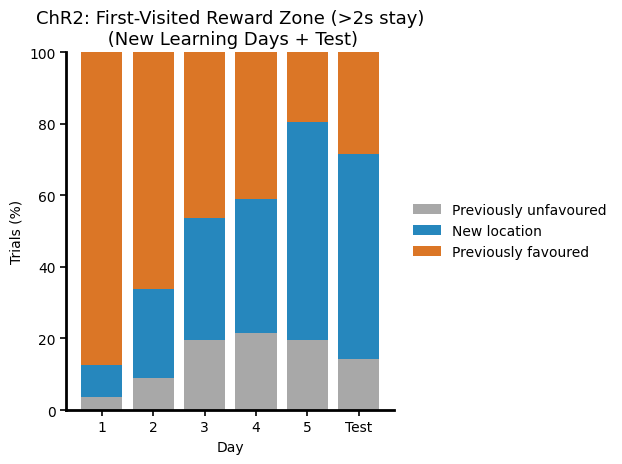

In [386]:

# ------------------------------------------------------------
# Filter: ChR2, RL/T, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5, T = 6
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign T=6 after last RL per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ------------------------------------------------------------
# First-choice counting
# ------------------------------------------------------------
mt_use = mt.copy()

# Determine first trigger per trial
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# Count per day × trigger
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2, 3], fill_value=0)
)

# Total trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)

print("====================================")
print("First-choice analysis summary (RL/T)")
print("====================================")

print("\nTotal trials per day:")
for d in plot_days:
    print(f"  Day {d}: {total_trials.loc[d]} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(f"  Day {d}:  Zone1={row.get(1,0)}, Zone2={row.get(2,0)}, Zone3={row.get(3,0)}")

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(f"  Day {d}:  Zone1={row[1]*100:.1f}%, Zone2={row[2]*100:.1f}%, Zone3={row[3]*100:.1f}%")
print("====================================\n")

# ------------------------------------------------------------
# Plot stacked bars
# ------------------------------------------------------------
colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}
labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2, 3]:
    vals = proportions[trig_id].values * 100
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.85, 
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','Test'])
ax.set_xlabel('Day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title('ChR2: First-Visited Reward Zone (>2s stay)\n (New Learning Days + Test)', fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,0.95])
plt.show()

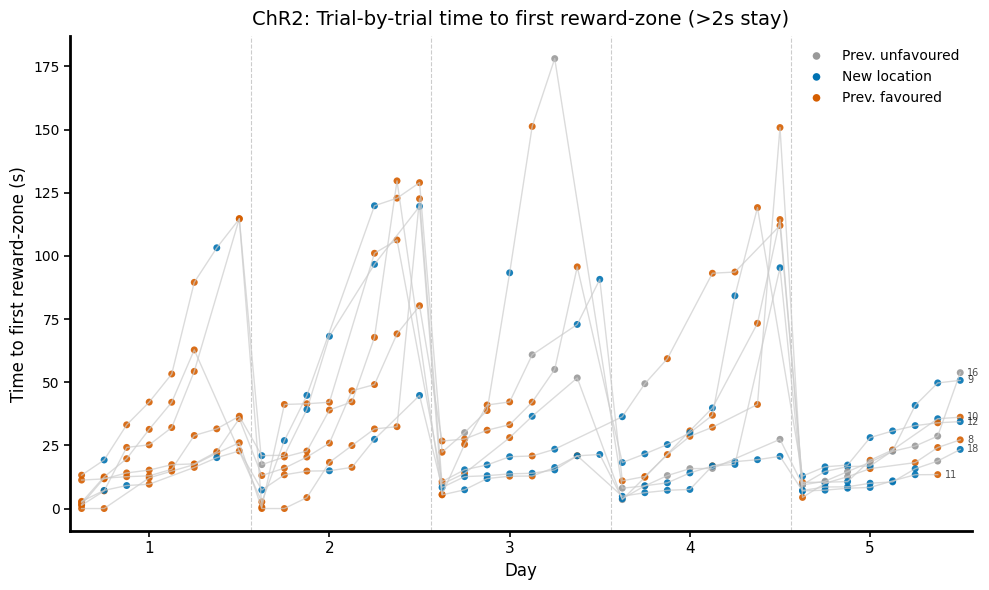

In [ ]:


# ------------------------------------------------------------
# 1) Filter: ChR2, RL/T, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5 from trial_type_day; T = 6 (first T after RL)
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign test day (6) as first T session after last RL session, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses)
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
# We assume 'trial_id' uniquely identifies a trial; if not, you can use
# ['sub','ses','trial_in_day'] as an alternative key.
group_key = 'trial_id'
if group_key not in mt.columns:
    # Fallback key if trial_id is not present
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..48)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']

# ---- Remove test day (plot_day = 6) ----
mt_noT = first_choice[first_choice['plot_day'] <= 5].copy()

# ---- Recompute global trial index for only RL days ----
mt_noT['trial_idx_global'] = (mt_noT['plot_day'] - 1) * 8 + mt_noT['trial_in_day']

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

zone_labels = {
    1: 'Prev. unfavoured',
    2: 'New location',
    3: 'Prev. favoured',
}

# plot each animal as before
for sub in sorted(mt_noT['sub'].unique()):
    ms = mt_noT[mt_noT['sub'] == sub].sort_values(['plot_day','trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values)/1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 RL days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators
for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x tick labels at center of each day block
day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Time to first reward-zone (s)', fontsize=12)

# legend
handles = []
labels = []
for zid in [1,2,3]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title('ChR2: Trial-by-trial time to first reward-zone (>2s stay)', fontsize=14, pad=8)

plt.tight_layout()
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


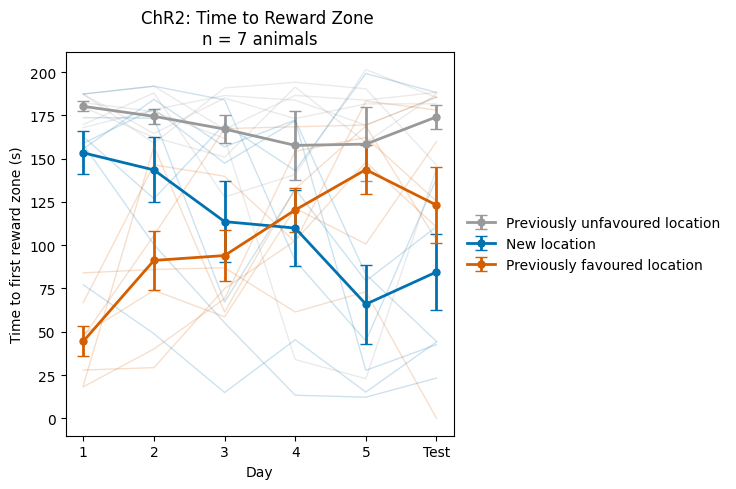

In [34]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly, “paper” style colors (similar to ggplot2 palette)
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location (highlighted)
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,                # ms → s
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=12
)

#(≥2 s stay)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout()
plt.show()




Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


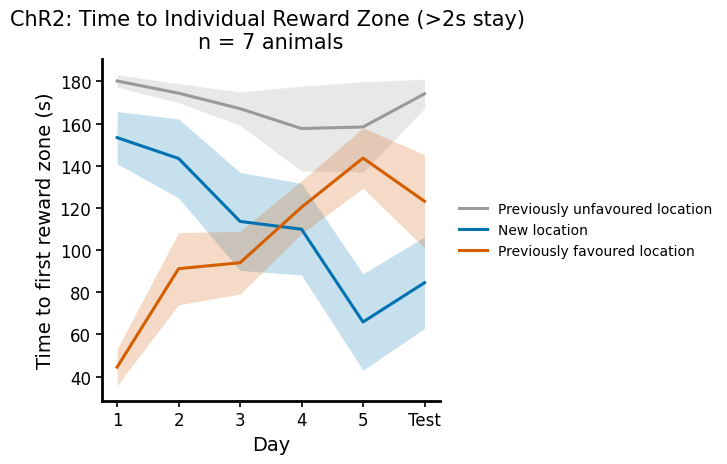

In [35]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(9, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New location
    3: '#D55E00',  # Previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM in seconds
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'ChR2: Time to Individual Reward Zone (>2s stay) \n'
    f'n = {n_animals} animals',
    fontsize=15,
    pad=8
)
#(≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.8, 0.95])
plt.show()

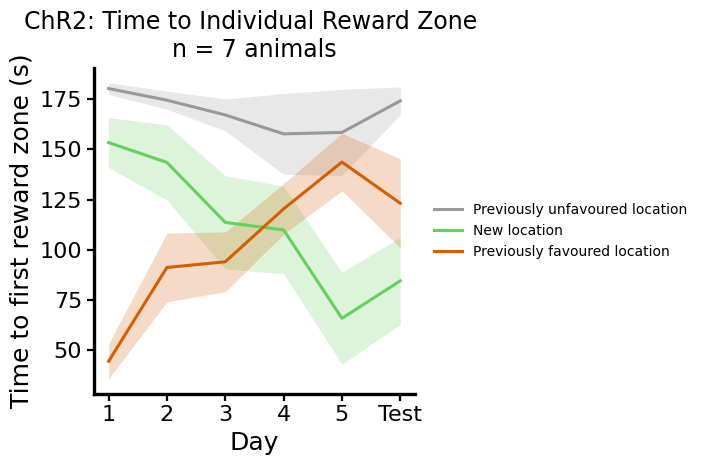

In [40]:
# ChR2 per trigger - clean figure (larger axes, legend right, vector export)
import os

out_dir = "/Users/stella/Desktop/vector_files"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#63D15Aff',  # New location
    3: '#D55E00',  # Previously favoured
}
labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )
    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# Axes + style (bigger axis text)
ax.set_xlabel('Day', fontsize=18)
ax.set_ylabel('Time to first reward zone (s)', fontsize=18)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.4)
ax.spines['left'].set_linewidth(2.4)
ax.tick_params(direction='out', length=5, width=1.6)

ax.set_title(
    f'ChR2: Time to Individual Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=17,
    pad=8
 )

# Legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.tight_layout(rect=[0, 0, 0.8, 0.95])
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_triggers_clean.svg'), bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_triggers_clean.pdf'), bbox_inches='tight')
plt.show()

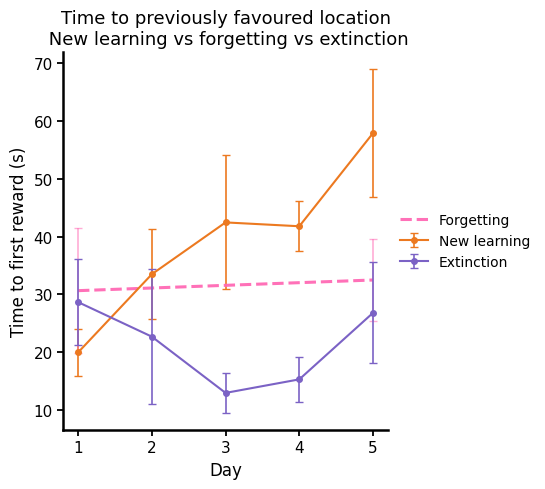

In [25]:

# ============================================================
# 1) RL stage – time to first entry into previously favoured location (trigger 3)
# ============================================================

# Start from your RL/T filter
mt_rl = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't really need the T=6 assignment for this analysis, but it won't hurt)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats(mt_rl, trigger_id=3):
    """
    Time to first entry into 'previously favoured' trigger for RL days 1–5.
    Returns mean_s, sem_s (seconds), each length 5.
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days))
    ].copy()

    mean_ms = np.full(len(rl_days), np.nan)
    sem_ms  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0  # seconds

mean_rl_s, sem_rl_s = rl_fav_stats(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – time to first entry into favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_time_to_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute time to trigger_id=2 per test day (1–5):

    1) mean per subject per day
    2) mean & SEM across subjects

    Returns mean_s, sem_s (seconds), length 5.
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_ms = np.full(len(test_days), np.nan)
    sem_ms  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df_day['trial_type_day'] == d] if False else df[df['trial_type_day'] == d]  # keep logic clear
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0   # seconds


meta_forg = meta_T[meta_T['test_type'] == 'forgetting'].copy()
meta_ext  = meta_T[meta_T['test_type'] == 'extinction'].copy()

mean_forg_s, sem_forg_s = build_time_to_zone2(meta_forg)
mean_ext_s,  sem_ext_s  = build_time_to_zone2(meta_ext)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction favoured zone
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_s, yerr=sem_rl_s,
    fmt='-o',
    color="#EC7920",         # unchanged
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials ----
col_f = '#FF69B4'   # pastel green (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)


# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_s[0], mean_forg_s[4]])
e_f = np.array([sem_forg_s[0],  sem_forg_s[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_s, yerr=sem_ext_s,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Time to previously favoured location\n New learning vs forgetting vs extinction', fontsize=13, pad=6)
#(>2s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (day 5):
  RL (RL day 5, trig3):          7
  Forgetting (Test day 5, trig2): 8
  Extinction (Test day 5, trig2): 7
RL vs Forg: raw p = 0.152
RL vs Ext: raw p = 0.62
Forg vs Ext: raw p = 0.397

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.456
  RL vs Ext: p_FDR = 0.62
  Forg vs Ext: p_FDR = 0.595


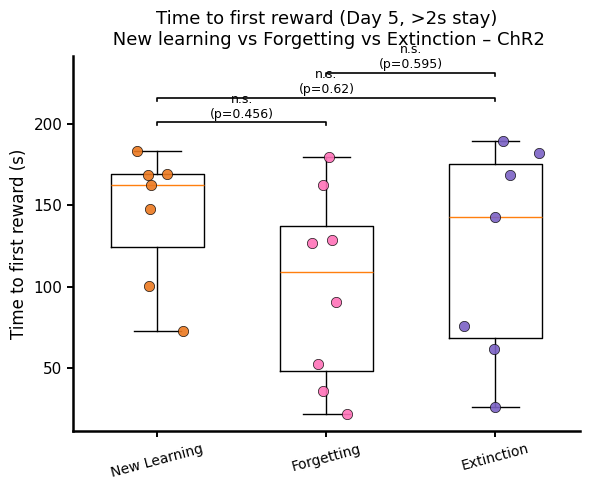

In [ ]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for the three groups (all ChR2)
#    - RL day 5, trigger_id = 3  (previously favoured)
#    - Forgetting test day 5, trigger_id = 2
#    - Extinction test day 5, trigger_id = 2
#    Using time to trigger per animal (mean across trials)
# ------------------------------------------------------------

# ---- RL day 5 (RL, trig=3, day=5) ----
rl_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'RL') &
    (meta_trig['trigger_id'] == 3) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

rl_per_sub = (
    rl_df.groupby('sub')['t_to_trigger_trig']
         .mean()
         .astype(float)
)
vals_rl = (rl_per_sub.values / 1000.0)  # ms → s

# ---- Forgetting day 5 (T, trig=2, day=5) ----
forg_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'forgetting') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

forg_per_sub = (
    forg_df.groupby('sub')['t_to_trigger_trig']
           .mean()
           .astype(float)
)
vals_forg = (forg_per_sub.values / 1000.0)  # ms → s

# ---- Extinction day 5 (T, trig=2, day=5) ----
ext_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'extinction') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

ext_per_sub = (
    ext_df.groupby('sub')['t_to_trigger_trig']
          .mean()
          .astype(float)
)
vals_ext = (ext_per_sub.values / 1000.0)  # ms → s

print("N per group (day 5):")
print("  RL (RL day 5, trig3):         ", len(vals_rl))
print("  Forgetting (Test day 5, trig2):", len(vals_forg))
print("  Extinction (Test day 5, trig2):", len(vals_ext))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl, vals_forg, vals_ext]
positions = np.arange(len(groups))

# simple colour scheme (consistent with earlier line plots)
colors = {
    "New Learning":         "#EC7920",  # orange
    "Forgetting": '#FF72B8', # pink
    "Extinction": '#7b62c5ff'   #  purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",      0, 1, vals_rl,  vals_forg),
    ("RL vs Ext",       0, 2, vals_rl,  vals_ext),
    ("Forg vs Ext",     1, 2, vals_forg, vals_ext)
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing

# start a bit above max
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    stars = p_to_stars(p)
    # draw only if we have at least a valid p
    if np.isnan(p):
        continue

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max, current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # move up for next comparison

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Time to first reward (s)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Time to first reward (Day 5, >2s stay)\n New learning vs Forgetting vs Extinction – ChR2', fontsize=13, pad=8)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

Pct time in trigger zone

In [361]:
# Compute pct time in trigger zone


metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
  
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger


 11%|█▏        | 522/4609 [00:05<00:42, 96.80it/s] 


KeyboardInterrupt: 

In [20]:
# test day plot + rank sum test

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
 #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

#groups = ['ChR2', 'eYFP_ChR2']
groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}


# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group','animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data
data = [meta_animal.loc[meta_animal['group']==g, 'pct_time_in_trigger'].values
        for g in groups]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # keep plain black box
    showfliers=False      # <-- turn off those empty circles
)


# individual animal points
for i, g in enumerate(groups):
    vals = meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    n = len(vals)

    # wider jitter for dense groups
    jitter = 0.12 if n < 6 else 0.12  # adjust if needed

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum test (Mann–Whitney U) + stars
# ------------------------------------------------------------
vals_ch = data[0]  # ChR2
vals_yf = data[1]  # eYFP_ChR2

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax = max(np.nanmax(vals_ch), np.nanmax(vals_yf))
# put the line a bit above the max data point
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between the two boxes (x=0 and x=1)
plt.plot([0, 0, 1, 1], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

# text with stars + p-value
plt.text(0.5, y_star, f"{stars} (p={p:.3g})",
         ha='center', va='bottom', fontsize=11)

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, 45)

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'pct_time_in_trigger'

ChR2 long animals plotted : 12
ChR2 short animals plotted: 3
eYFP_ChR2 animals plotted : 5
Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = 0.0357


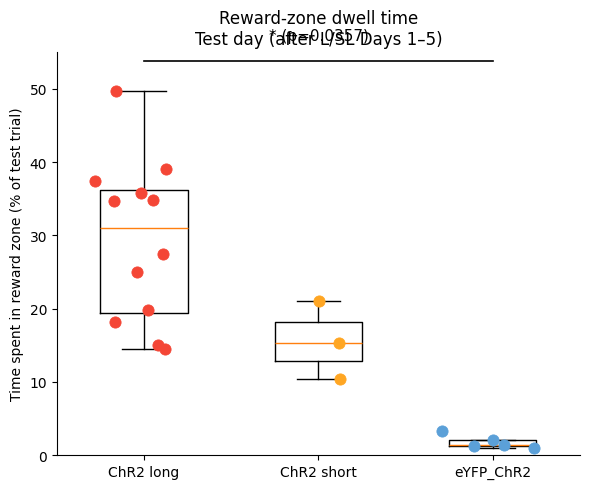

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 0) Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['sub'] != 17)
].copy()

plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1) Helper: build subject × day matrix (enforces L/SL days 1–5
#    + FIRST T session AFTER last learning session as day 6)
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) pct_time_in_trigger per day
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # subset by genotype and L/SL + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # assign learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # ----- KEY LINE: first T session AFTER last learning session -----
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2) Build matrices for the three groups
#    Group 1: ChR2 long (L, short_duration=0)
#    Group 2: eYFP_ChR2 (L, any short_duration)
#    Group 3: ChR2 short (SL, short_duration=1)
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted :", len(subs_ChR2_long))
print("ChR2 short animals plotted:", len(subs_ChR2_short))
print("eYFP_ChR2 animals plotted :", len(subs_eYFP))


# ------------------------------------------------------------
# 3) Extract TEST DAY (day 6) values for each animal
#     → matrices are (n_animals x 6), index 5 = test day
# ------------------------------------------------------------
vals_ChR2_long  = mat_ChR2_long[:, 5]   # Day 6
vals_ChR2_short = mat_ChR2_short[:, 5]
vals_eYFP       = mat_eYFP[:, 5]

groups = ['ChR2 long', 'ChR2 short', 'eYFP_ChR2']
data   = [vals_ChR2_long, vals_ChR2_short, vals_eYFP]

colors = {
    'ChR2 long'  : get_genotype_color('ChR2'),
    'ChR2 short' : get_genotype_color('ChR2_short'),
    'eYFP_ChR2'  : get_genotype_color('eYFP_ChR2')
}

# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points + animal labels
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,
    showfliers=False
)

for i, g in enumerate(groups):
    vals = data[i]
    subs = [subs_ChR2_long, subs_ChR2_short, subs_eYFP][i]   # matching subject lists
    n = len(vals)

    jitter = 0.12
    x = np.random.normal(i, jitter, size=n)

    # plot points
    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )


# ------------------------------------------------------------
# 5) Rank-sum (Mann–Whitney) for ChR2_long vs eYFP_ChR2
#    (line between box 0 and box 2; ChR2_short is box 1)
# ------------------------------------------------------------
vals_ch = vals_ChR2_short
vals_yf = vals_eYFP

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax  = np.nanmax(np.concatenate([vals_ChR2_long, vals_ChR2_short, vals_eYFP]))
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between x=0 (ChR2 long) and x=2 (eYFP_ChR2)
plt.plot([0, 0, 2, 2], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

plt.text(
    1.0, y_star,
    f"{stars} (p={p:.3g})",
    ha='center', va='bottom', fontsize=11
)


# ------------------------------------------------------------
# 6) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups, rotation=0)
plt.ylim(0, 55)

plt.ylabel('Time spent in reward zone (% of test trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day (after L/SL Days 1–5)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

        group  animal  pct_time_in_trigger
0        ChR2       1            29.578657
1        ChR2       3            35.765130
2        ChR2       4            34.803665
3        ChR2       6            19.793126
4        ChR2       7            11.939570
5        ChR2       8            30.509764
6        ChR2       9            25.763918
7        ChR2      10            16.308726
8        ChR2      11            12.028290
9        ChR2      12            23.016142
10       ChR2      16             9.566117
11       ChR2      18            19.745282
12         Hp      40             5.255492
13         Hp      41             4.780728
14         Hp      42             1.849510
15         Hp      43             2.079009
16         Hp      44             2.451215
17         Hp      45             6.376267
18         Hp      46             6.236343
19  eYFP_ChR2      19             2.327057
20  eYFP_ChR2      20             2.105439
21  eYFP_ChR2      21             0.701039
22  eYFP_Ch

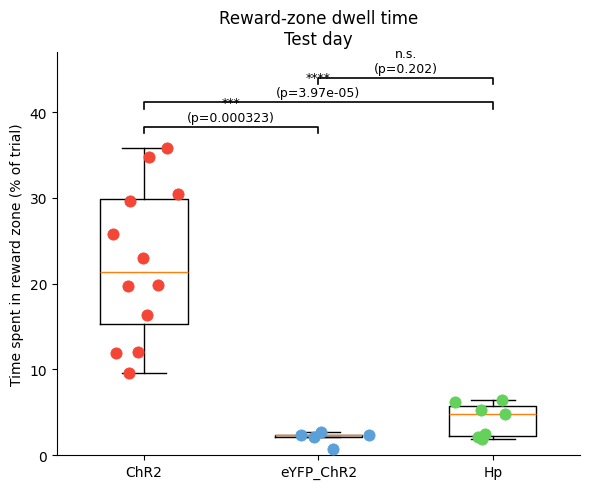

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only (now incl. Hp)
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}

# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data in group order
data = [
    meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    for g in groups
]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # plain black box
    showfliers=False      # no empty circles
)

# individual animal points
for i, g in enumerate(groups):
    vals = data[i]
    n = len(vals)

    if n == 0:
        continue

    jitter = 0.12 if n < 6 else 0.12

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum tests (Mann–Whitney U) + stars for all pairs
# ------------------------------------------------------------
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

# all pairs: (ChR2 vs eYFP), (ChR2 vs Hp), (eYFP vs Hp)
pairs = [(0, 1), (0, 2), (1, 2)]

# base height for annotations
all_vals = np.concatenate([d for d in data if len(d) > 0])
ymax = np.nanmax(all_vals)
y_step = ymax * 0.08
current_y = ymax * 1.05

for (i, j) in pairs:
    vals_i = data[i]
    vals_j = data[j]

    # skip if any group empty
    if len(vals_i) == 0 or len(vals_j) == 0:
        continue

    stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')
    print(f"{groups[i]} vs {groups[j]}: Mann–Whitney U p = {p:.3g}")

    stars = p_to_stars(p)

    x1, x2 = i, j
    x_mid = (x1 + x2) / 2.0

    # bracket line
    plt.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.02*ymax, current_y + 0.02*ymax, current_y],
        color='black',
        linewidth=1.2
    )

    # text (stars + p)
    plt.text(
        x_mid,
        current_y + 0.03*ymax,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # stack brackets upward

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, max(45, current_y + y_step * 0.3))

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

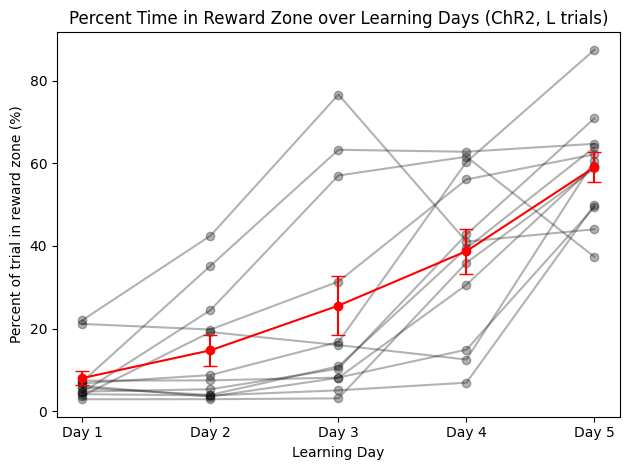

In [73]:
# Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean % time in trigger zone per training day
    mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
    mean_pct_by_day = mean_pct_by_day.sort_index()

    # Expect 5 days; skip incomplete animals
    if len(mean_pct_by_day) != 5:
        continue

    performance_mat.append(mean_pct_by_day.values)

    # Individual subject traces (thin black)
    plt.plot(range(5), mean_pct_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM
performance_mat = np.vstack(performance_mat)
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

plt.errorbar(
    range(5),
    mean_performance,
    yerr=sem_performance,
    fmt='-o',
    color='r',
    capsize=5
)

plt.xlabel('Learning Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


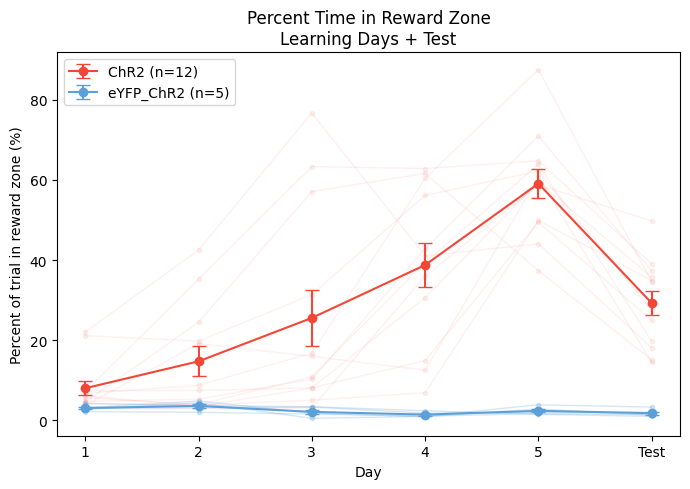

In [128]:
# plot ChR2 & eYFP_ChR2 learning trials + first test day (by session) after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2
if mat_ChR2 is not None:
    col_c = get_genotype_color('ChR2')

    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_c,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c, yerr=sem_c,
        fmt='-o',
        color=col_c,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# eYFP_ChR2
if mat_eYFP is not None:
    col_y = get_genotype_color('eYFP_ChR2')

    # individual traces
    for row in mat_eYFP:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_y,
            alpha=0.25,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y, yerr=sem_y,
        fmt='-o',
        color=col_y,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

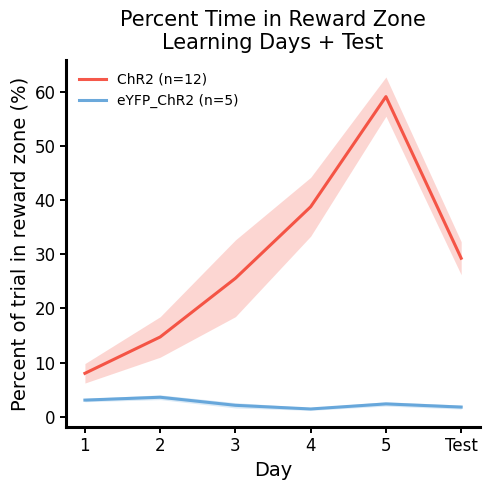

In [127]:
# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) values of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot both groups using your color function ---
plot_group_shaded(
    mat_ChR2,
    subs_ChR2,
    genotype_key='ChR2',
    label='ChR2'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


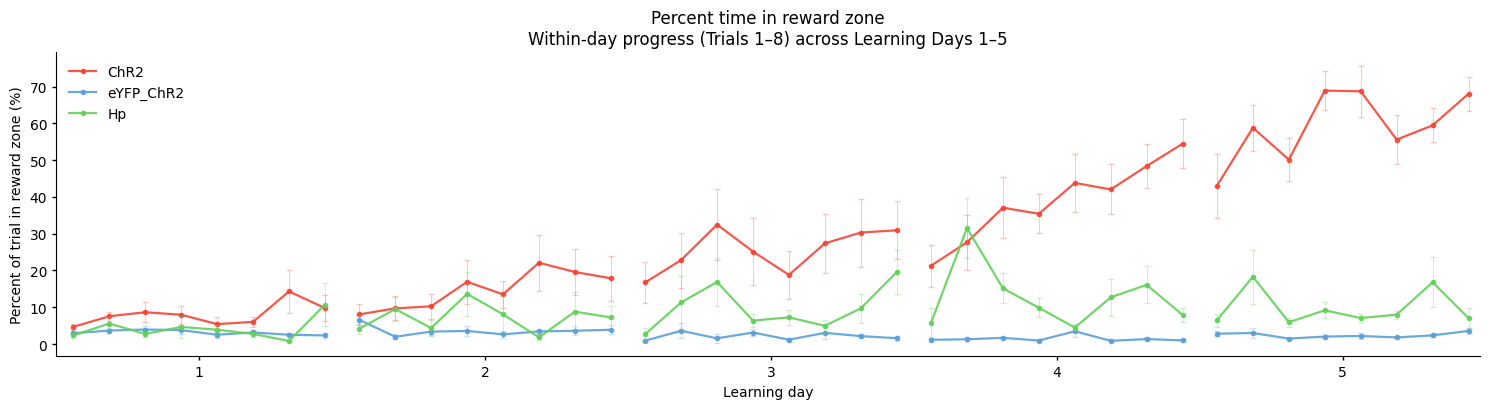

In [ ]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_time_in_trigger (% of trial in reward zone)
# Groups: ChR2 vs eYFP_ChR2  (others available via comments)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &  ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    # (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_time_in_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials])
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves using color function
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key, label=None, alpha=1.0):
    """
    genotype_key: key for get_genotype_color, e.g.
                  'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp', ...
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # for showing legend label once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # ---- mean line ----
        ax.plot(
            x, mean_,
            'o-',
            color=col,
            alpha=alpha,
            linewidth=1.6,
            markersize=3,
            label=label if first_day and (label is not None) else None
        )

        # ---- SEM bars (faded) ----
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=col,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

        first_day = False

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (all options kept)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
# meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
# meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
# meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# if plotting for short duration:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()
#
# meta_eYFP_L = meta_L[
#     (meta_L['genotype'] == 'eYFP_ChR2') &
#     (meta_L['trial_type'] == 'L')
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())
# print("  ChR2 long:", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day labels under each day's curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha=0.9
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha=0.9
)

# other groups, ready to use when you want:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha=0.7
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


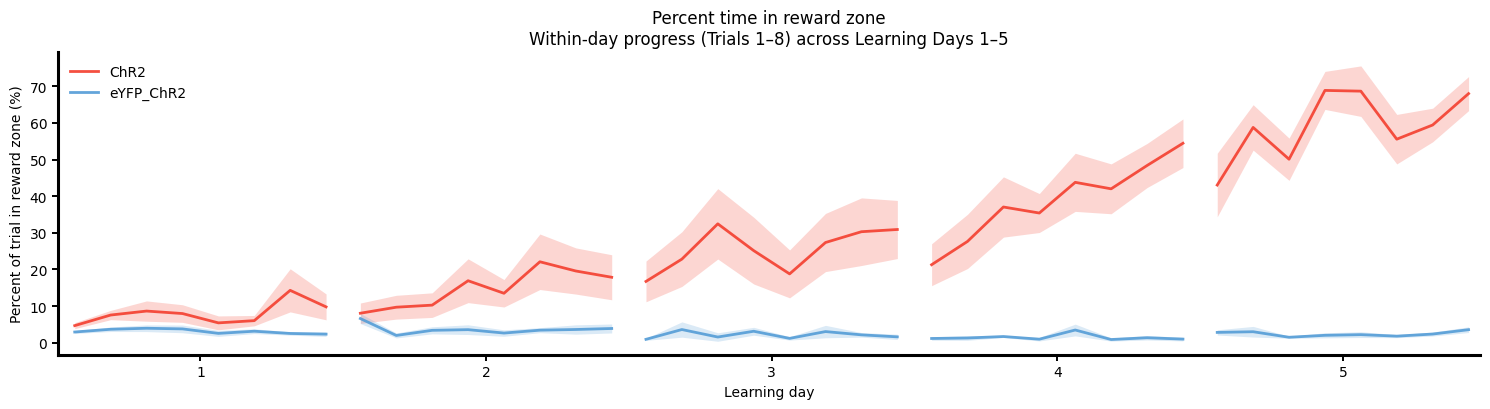

In [134]:
# ------------------------------------------------------------
# 4) Plot helper: within-day curves with shaded SEM
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key,
                           label=None,
                           alpha_fill=0.22,
                           alpha_line=0.9):
    """
    meta_g:   subset of metadata for a given group
    genotype_key: key for get_genotype_color, e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    label:    legend label (shown once per group)
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # to only add legend entry once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # shaded SEM band
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        # mean line (no markers)
        ax.plot(
            x, mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 5) Nature-style axes (thicker frame)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)

    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# If plotting long vs short separately later:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())


# ------------------------------------------------------------
# 7) Plot (mean curves + shaded SEM)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main two groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

# If you later want Hp:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

# If you later want ChR2 long vs ChR2_short:
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha_fill=0.18,
#     alpha_line=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each day's cluster
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curves are visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 10
ChR2 animals plotted: 10
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


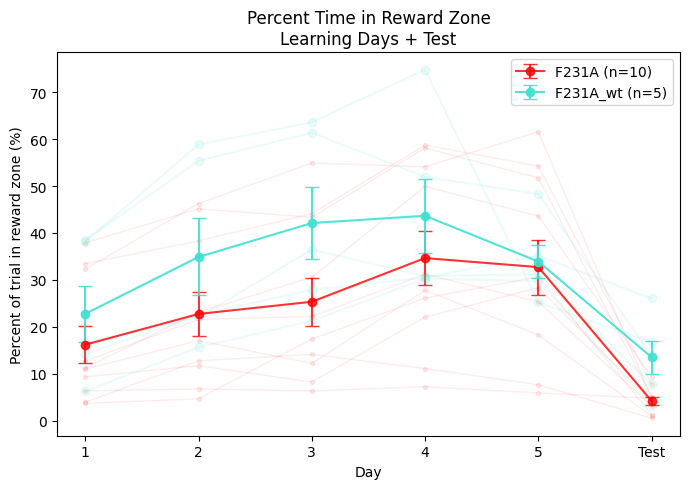

In [48]:
# plot f231a vs wt learning trials + first test day (by session) after learning


# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red', alpha=0.8,
                 capsize=5, label=f'F231A (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.1, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise', alpha=0.90,
                 capsize=5, label=f'F231A_wt (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


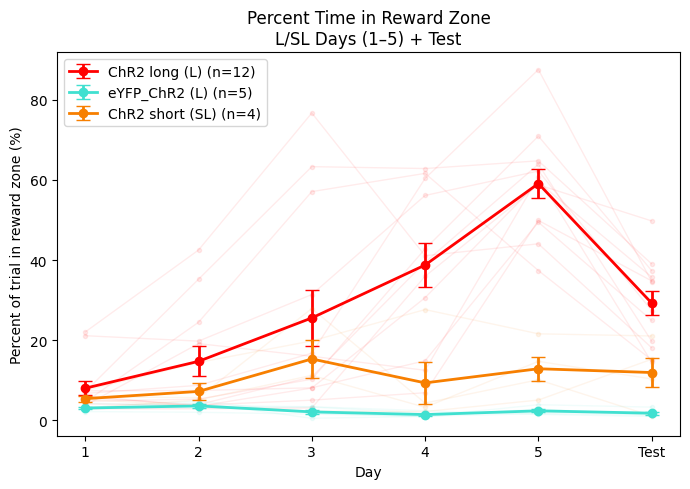

In [160]:
# =============================================================
# Build subject × day performance matrices for 3 groups:
# percent time in trigger zone over learning days + test

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a group
#    learning_type: 'L' or 'SL'
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning trials)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # genotype + (learning_type or T)
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # use 'ses' to find first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration == 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration == 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )
    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o', color=color,
        capsize=5,
        linewidth=2,
        markersize=6,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nL/SL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

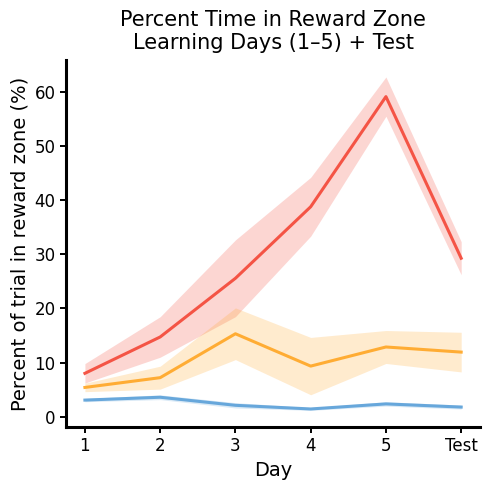

In [164]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, using colour function
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) matrix of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces, no dots)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Group 1: ChR2 long – use 'ChR2' colour
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2 long (L)'
)

# Group 2: eYFP_ChR2 – use 'eYFP_ChR2' colour
plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2 (L)'
)

# Group 3: ChR2 short – use 'ChR2_short' colour
plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2 short (SL)'
)


# ------------------------------------------------------------
# Axes + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days (1–5) + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

# plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in data: 12
ChR2 animals plotted: 12
eYFP animals in data: 5
eYFP animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


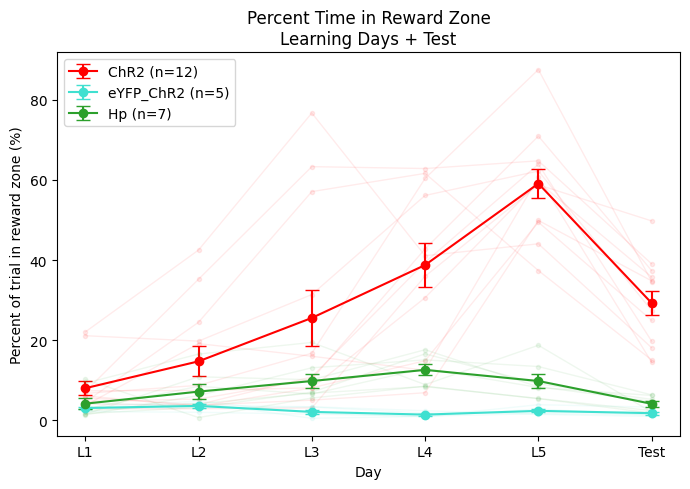

In [165]:
# plot ChR2 & eYFP_ChR2 & Hp learning trials + test after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable animals, 3 genotypes, L or T trials
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create plot_day:
# - L trials → trial_type_day 1–5
# - T trials → set later to day 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']


# ---------------------------------------------------------------------
# 1b. Assign the first T *session* after the last L session to plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6


plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test session


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs
    Only keeps animals with complete 1–6 days.
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue   # require complete 6 days

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ---------------------------------------------------------------------
# 3. Build matrices for the three groups
# ---------------------------------------------------------------------
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals in data:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP animals in data:", meta_eYFP['sub'].nunique())
print("eYFP animals plotted:", len(subs_eYFP))
print("Hp animals in data:", meta_Hp['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # individual traces
    for row in mat:
        plt.plot(x_vals, row, '-o', color=color, alpha=0.08, linewidth=1, markersize=3,label='_nolegend_')

    # group mean ± sem
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_, fmt='-o', color=color,
        capsize=5, label=f'{label} (n={len(subs)})'
    )


# Plot groups
plot_group(mat_ChR2, subs_ChR2, color='red',     label='ChR2')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c', label='Hp')


plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['L1','L2','L3','L4','L5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

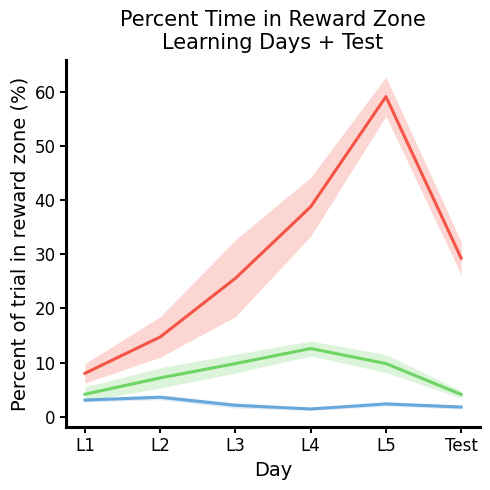

In [167]:
# ---------------------------------------------------------------------
# 4. Plot: mean ± shaded SEM, colour function, no individual traces
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'Hp')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individuals)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  genotype_key='Hp',
                  label='Hp')

# Axis labels, ticks, style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['L1', 'L2', 'L3', 'L4', 'L5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Compute percentage of time spent in reward zone for REMAPPING group


In [137]:
# ----- COMPUTE PERCENT TIME IN TRIGGER ZONE (PER TRIGGER) -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone (like your example)
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

pct_rows = []  # will hold per-trigger rows: trial_id, trigger_id, pct_in_trigger_trig

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Trial duration (same units as df_trigger_interaction['duration'])
    trial_duration = position_['t'].max()
    if trial_duration <= 0:
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # ---- ANY trigger, like your original code ----
    total_time_in_trigger = df_all_triggers['duration'].sum()
    pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

    # ---- PER TRIGGER: same logic, but restricted to each trigger_id ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
        if len(df_t) == 0:
            pct_trig = 0.0   # spent 0% of time in this trigger
        else:
            total_t_trig = df_t['duration'].sum()
            pct_trig = 100.0 * total_t_trig / trial_duration

        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'pct_in_trigger_trig': pct_trig
        })

# Long-format per-trigger table + metadata
df_pct = pd.DataFrame(pct_rows)
meta_pct = df_pct.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 705/4611 [00:07<00:42, 91.59it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1180/4611 [00:12<00:35, 95.80it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2608/4611 [00:25<00:14, 141.90it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:44<00:00, 104.73it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


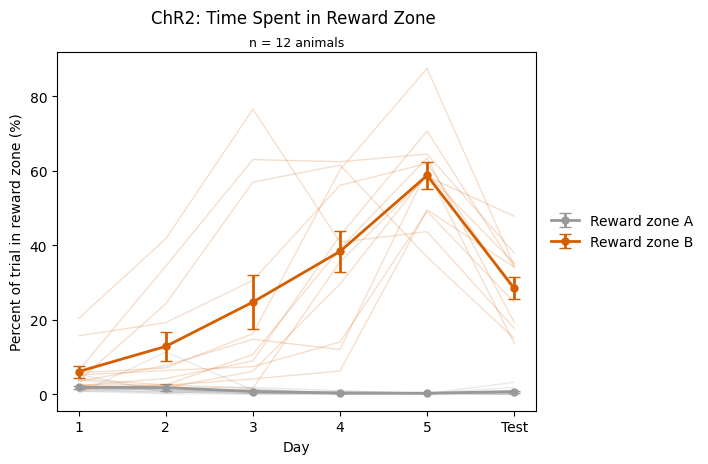

In [138]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['L', 'T']))
].copy()

# L days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L trials
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (PERCENT TIME) -----

def build_zone_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix_pct(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style colors for A/B
colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded) + ID labels at end
    for row, sub in zip(mat, subs):
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )


    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

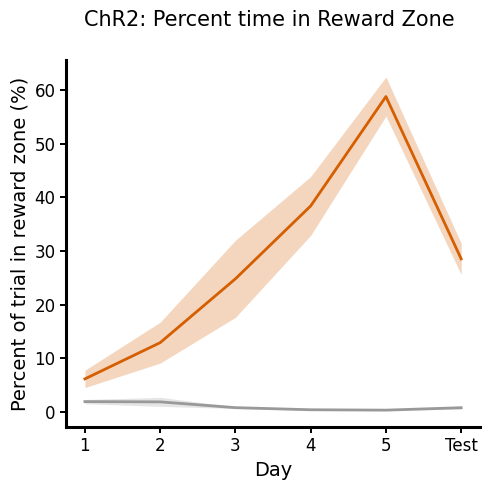

In [146]:
# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1   # 0..5 index for days 1–6

colors = {
    1: '#999999',  # zone A
    2: '#D55E00',  # zone B
}
#labels = {
#    1: 'Reward zone A',
#    2: 'Reward zone B',
#}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[zid]

    # ---- shaded SEM ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[zid]} (n={len(subs)})"
    )

# ----- axis + styling -----
ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test'],
    fontsize=12
)

plt.yticks(fontsize=12)

# thick bottom/left, hide top/right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent time in Reward Zone \n', fontsize=15, pad=8)

# small n info
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included per reward zone:
  Reward zone 1: 12 animals
  Reward zone 2: 12 animals

Total unique animals included (any zone): 12
Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


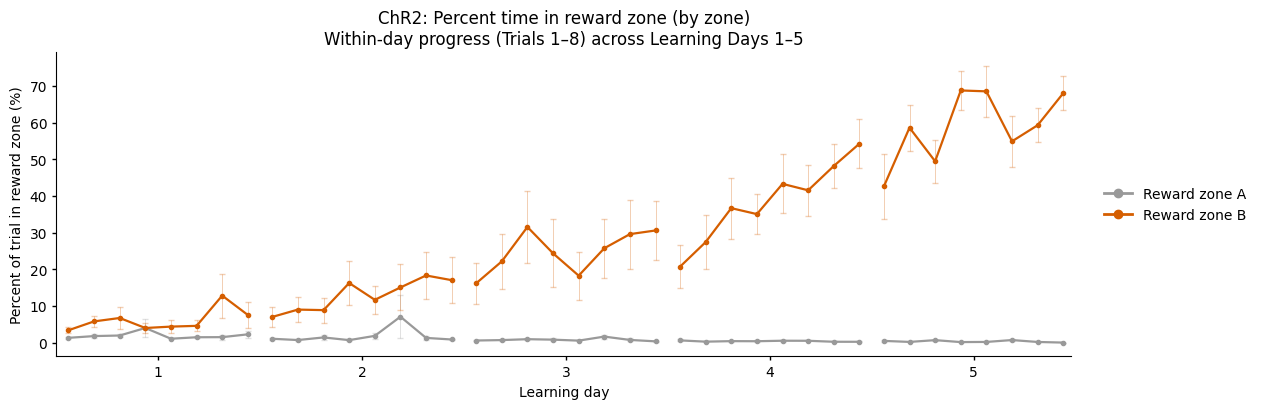

In [139]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'L') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Animal counts (based on *this* filtered dataset)
# ------------------------------------------------------------
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


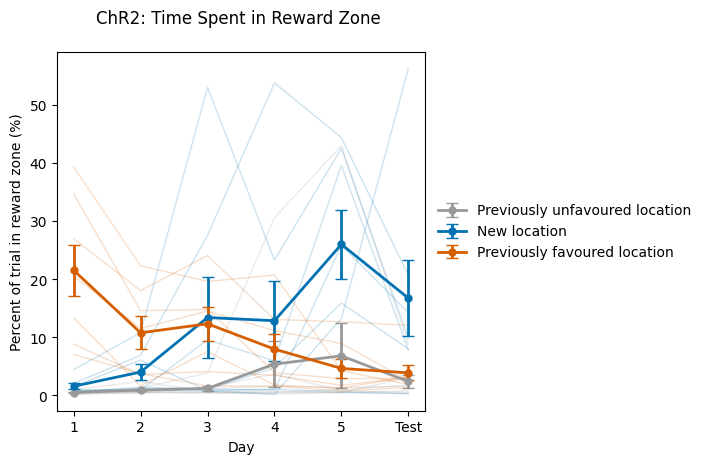

In [155]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# RL days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL trials
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last RL session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (PERCENT TIME) -----

def build_trigger_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean % time per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_pct(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row,                      # already in %
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

# Main title + smaller n-line
plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


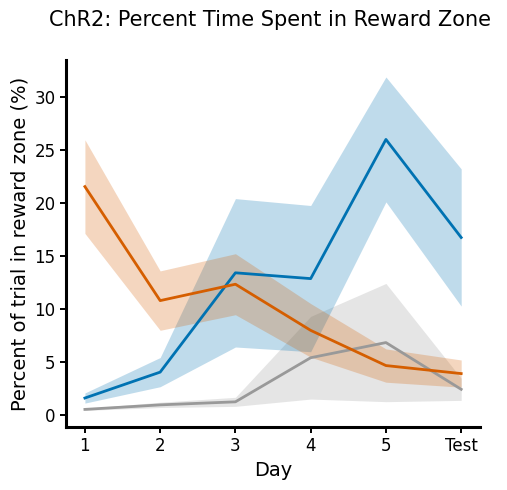

In [158]:
# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat  = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[trig_id]

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers, no individuals) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[trig_id]} (n={len(subs)})"
    )

ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent Time Spent in Reward Zone \n', fontsize=15, pad=8)

# small n text if you still want it
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()